In [1]:
import plot_cv as P
from pathlib import Path
from matplotlib import pyplot as plt
import ela_cv_features as ela_features
import json
import plot_cv1 as P1

In [2]:
src = {
    2: Path("/Users/leekaijen/t7ssd/featELA/dim2featELA/ela_cv_results.pkl"),
    5: Path("/Users/leekaijen/t7ssd/featELA/dim5featELA/ela_cv_results.pkl"),
    10: Path("/Users/leekaijen/t7ssd/featELA/dim10featELA/ela_cv_results.pkl"),
}

## ELA Features

In [3]:
overall = ela_features.ELA_FEATURE_GROUPS
overall_flatten = [x for xs in overall.values() for x in xs]
print(f"Total number of features: {len(overall_flatten)}")
print(json.dumps(overall, indent=2))

Total number of features: 46
{
  "ela_dist": [
    "ela_distr.skewness",
    "ela_distr.kurtosis",
    "ela_distr.number_of_peaks"
  ],
  "meta": [
    "ela_meta.lin_simple.adj_r2",
    "ela_meta.lin_simple.intercept",
    "ela_meta.lin_simple.coef.min",
    "ela_meta.lin_simple.coef.max",
    "ela_meta.lin_simple.coef.max_by_min",
    "ela_meta.lin_w_interact.adj_r2",
    "ela_meta.quad_simple.adj_r2",
    "ela_meta.quad_simple.cond",
    "ela_meta.quad_w_interact.adj_r2"
  ],
  "disp": [
    "disp.ratio_mean_02",
    "disp.ratio_mean_05",
    "disp.ratio_mean_10",
    "disp.ratio_mean_25",
    "disp.ratio_median_02",
    "disp.ratio_median_05",
    "disp.ratio_median_10",
    "disp.ratio_median_25",
    "disp.diff_mean_02",
    "disp.diff_mean_05",
    "disp.diff_mean_10",
    "disp.diff_mean_25",
    "disp.diff_median_02",
    "disp.diff_median_05",
    "disp.diff_median_10",
    "disp.diff_median_25"
  ],
  "nbc": [
    "nbc.nn_nb.sd_ratio",
    "nbc.nn_nb.mean_ratio",
    "nbc.nn_

In [4]:
safe = ela_features.CV_SAFE
print(f"Total features suitable for CV: {len(safe)}/{len(overall_flatten)} -- {len(safe)/len(overall_flatten):.2%}")
print(json.dumps(safe, indent=2))

Total features suitable for CV: 15/46 -- 32.61%
[
  "ela_distr.number_of_peaks",
  "disp.ratio_mean_02",
  "disp.ratio_mean_05",
  "disp.ratio_mean_10",
  "disp.ratio_mean_25",
  "disp.ratio_median_02",
  "disp.ratio_median_05",
  "disp.ratio_median_10",
  "disp.ratio_median_25",
  "nbc.nn_nb.sd_ratio",
  "nbc.nn_nb.mean_ratio",
  "ic.h_max",
  "ic.eps_ratio",
  "ela_meta.quad_simple.cond",
  "ela_meta.lin_simple.coef.max_by_min"
]


In [5]:
caveated = ela_features.CV_CAVEATED
print(f"Total features with caveats: {len(caveated)}/{len(overall_flatten)} -- {len(caveated)/len(overall_flatten):.2%}")
print(json.dumps(caveated, indent=2))

Total features with caveats: 14/46 -- 30.43%
{
  "pca.expl_var.cov_x": "bounded proportion in (0,1]; clustering near bound deflates CV",
  "pca.expl_var.cor_x": "bounded proportion in (0,1]; clustering near bound deflates CV",
  "pca.expl_var.cov_init": "bounded proportion in (0,1]; clustering near bound deflates CV",
  "pca.expl_var.cor_init": "bounded proportion in (0,1]; clustering near bound deflates CV",
  "pca.expl_var_PC1.cov_x": "bounded proportion in (0,1]; clustering near bound deflates CV",
  "pca.expl_var_PC1.cor_x": "bounded proportion in (0,1]; clustering near bound deflates CV",
  "pca.expl_var_PC1.cov_init": "bounded proportion in (0,1]; clustering near bound deflates CV",
  "pca.expl_var_PC1.cor_init": "bounded proportion in (0,1]; clustering near bound deflates CV",
  "ic.m0": "bounded in [0,1]; same deflation caveat as proportions",
  "ic.eps_s": "log-scaled, spans orders of magnitude and can hit 0; prefer CV(log) or robust spread",
  "ic.eps_max": "log-scaled, spans

In [6]:
unsuitable_features = ela_features.CV_EXCLUDED
print(f"Total features not suitable for CV: {len(unsuitable_features)}/{len(overall_flatten)} -- {len(unsuitable_features)/len(overall_flatten):.2%}")
print(json.dumps(unsuitable_features, indent=2))

Total features not suitable for CV: 17/46 -- 36.96%
{
  "ela_distr.skewness": "sign-changing, interval-scale (0 = symmetric)",
  "ela_distr.kurtosis": "sign-changing, interval-scale (0 = mesokurtic)",
  "ela_meta.lin_simple.intercept": "arbitrary sign and scale, no true zero",
  "ela_meta.lin_simple.adj_r2": "can be negative; bounded above by 1; not ratio-scaled",
  "ela_meta.lin_w_interact.adj_r2": "can be negative; not ratio-scaled",
  "ela_meta.quad_simple.adj_r2": "can be negative; not ratio-scaled",
  "ela_meta.quad_w_interact.adj_r2": "can be negative; not ratio-scaled",
  "disp.diff_mean_02": "difference, can be negative; 0 = no difference",
  "disp.diff_mean_05": "difference, can be negative; 0 = no difference",
  "disp.diff_mean_10": "difference, can be negative; 0 = no difference",
  "disp.diff_mean_25": "difference, can be negative; 0 = no difference",
  "disp.diff_median_02": "difference, can be negative; 0 = no difference",
  "disp.diff_median_05": "difference, can be nega

## Overall CV Stability

General Convention:

CV

| CV range | Variability | Interpretation |
|---|---|---|
| 0–20% | Low | Data points cluster relatively close to the mean; the dataset is stable and consistent. |
| 20–50% | Moderate | Noticeable spread around the mean; a moderate level of fluctuation. |
| >50% | High | Data points are widely scattered; the mean may not represent the dataset well. |


CV is calculated in a within-instance manner. i.e. for each dimension: each (function, instance) produces a CV value.

Aggregation is done by (1) obtaining the median CV for each feature across all (function, instance), then (2) obtain the mean between all median feature CVs.

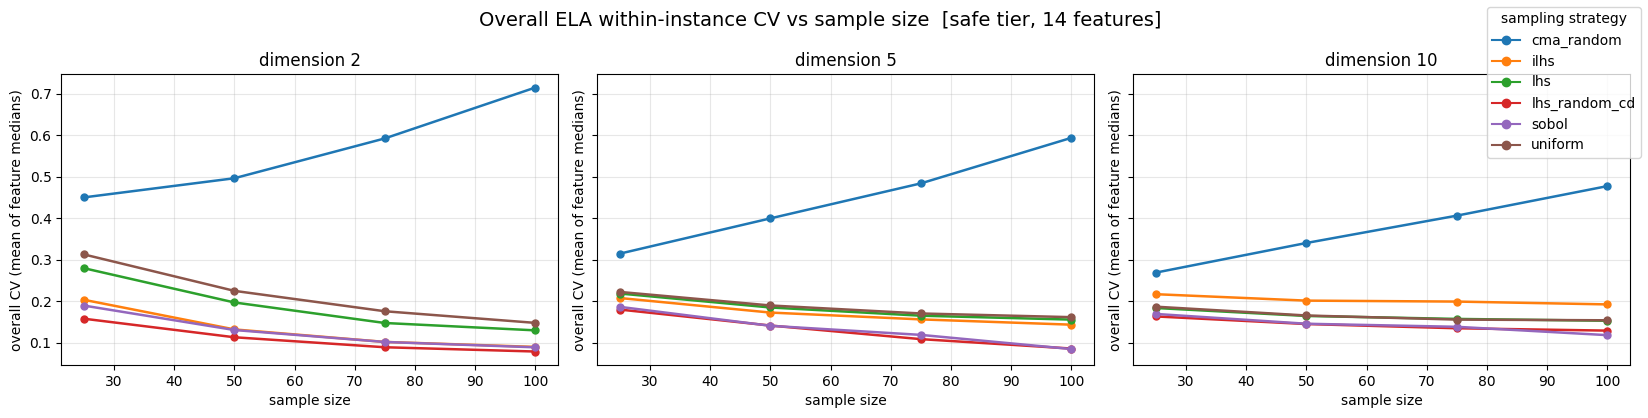

In [7]:
P1.plot_cv_vs_size_tier(src, tier="safe")
plt.show()

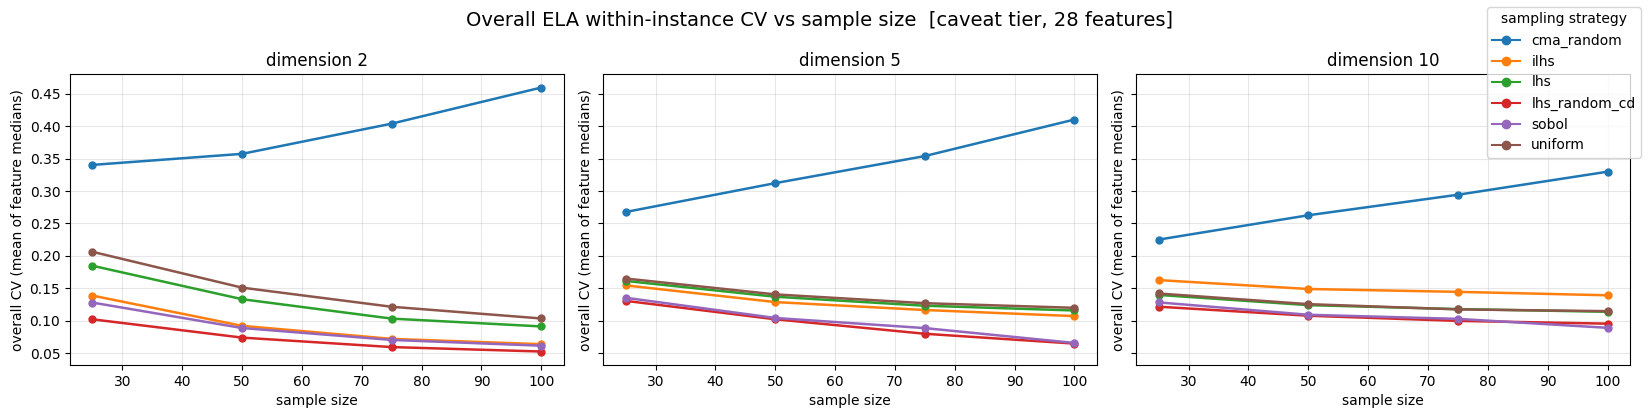

In [8]:
P1.plot_cv_vs_size_tier(src, tier="caveat")
plt.show()


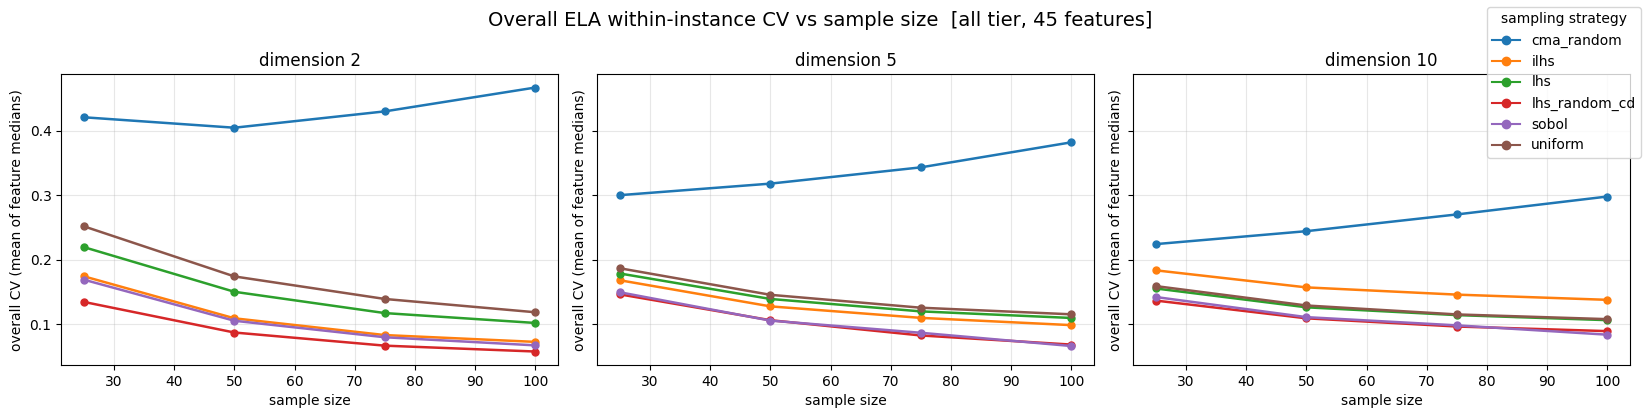

In [9]:
P1.plot_cv_vs_size_tier(src, tier="all")
plt.show()


## By function group

### Considering only safe ELA features

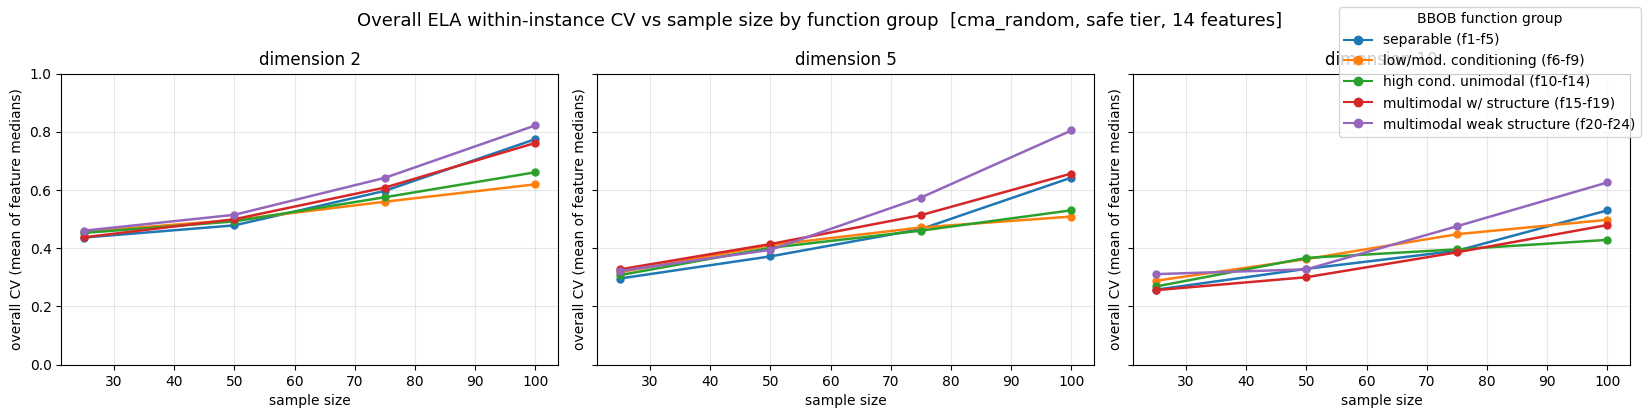

In [10]:
P1.plot_cv_vs_size_by_function_group(src, strategy='cma_random', tier='safe', ylim=(0,1.00))
plt.show()

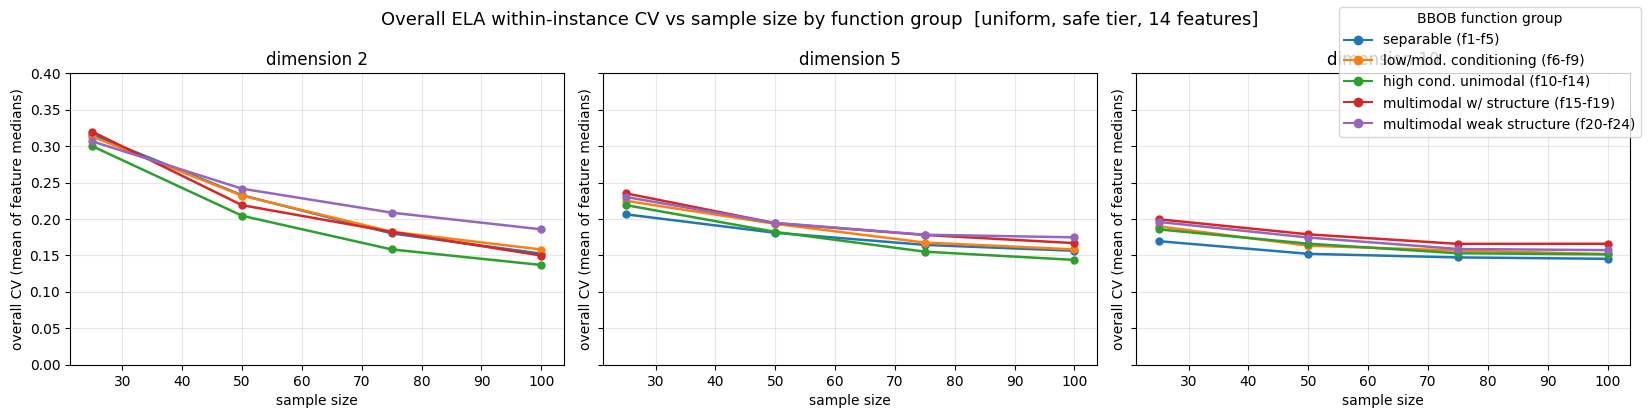

In [11]:
P1.plot_cv_vs_size_by_function_group(src, strategy='uniform', tier='safe', ylim=(0,0.4))
plt.show()

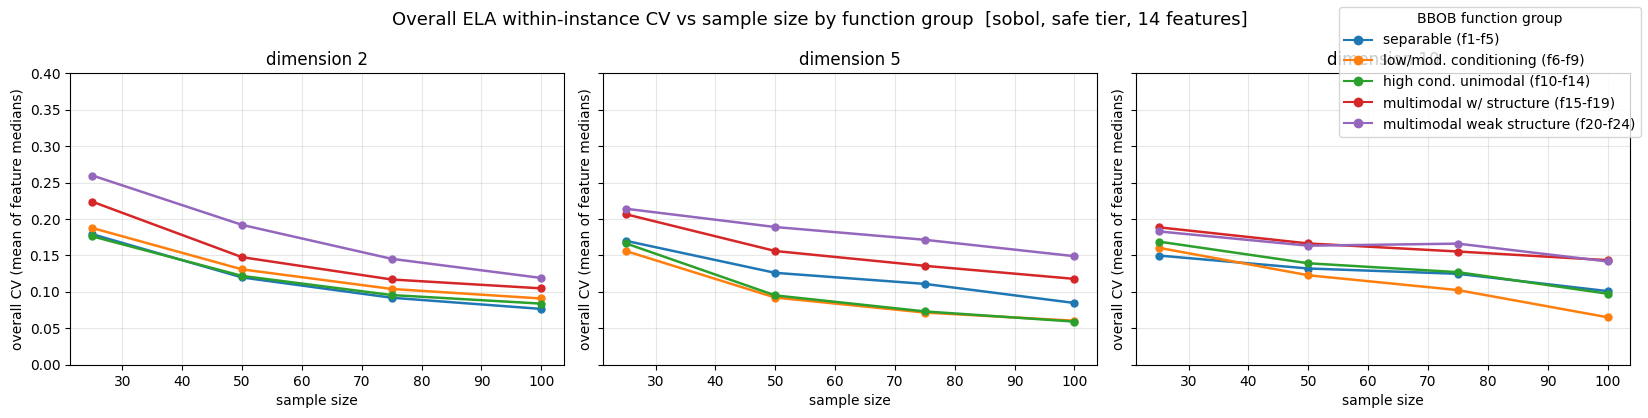

In [12]:
P1.plot_cv_vs_size_by_function_group(src, strategy='sobol', tier='safe', ylim=(0,0.4))
plt.show()

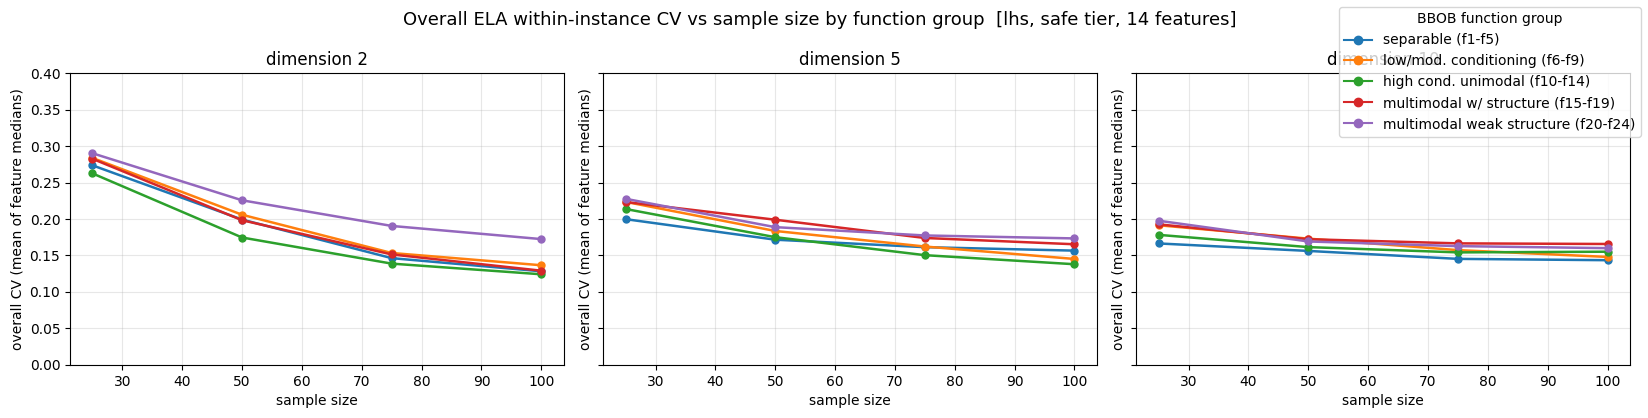

In [13]:
P1.plot_cv_vs_size_by_function_group(src, strategy='lhs', tier='safe', ylim=(0,0.4))
plt.show()

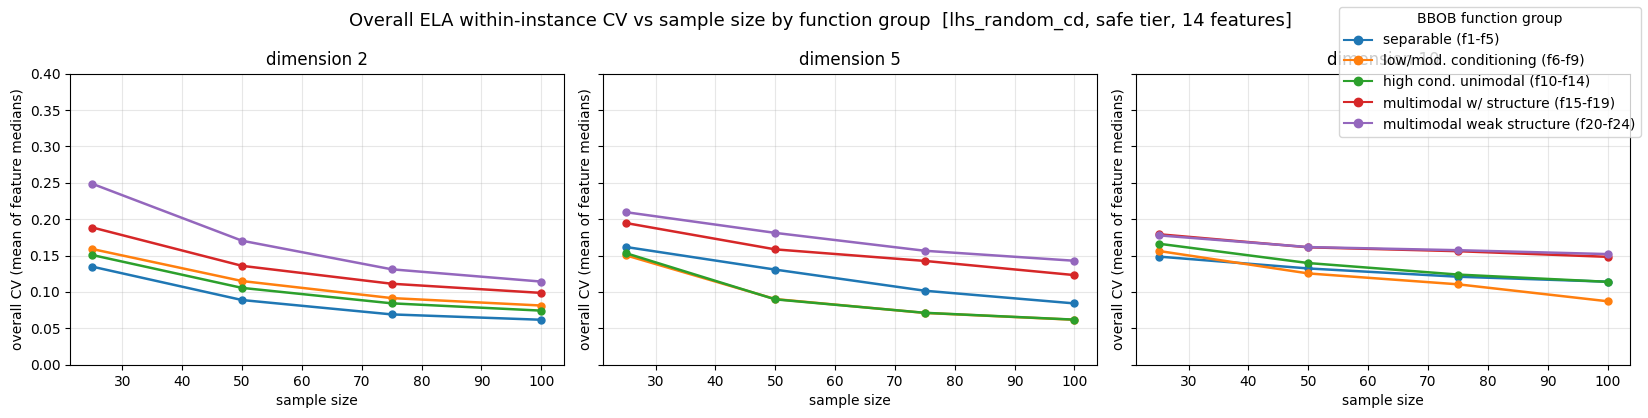

In [14]:
P1.plot_cv_vs_size_by_function_group(src, strategy='lhs_random_cd', tier='safe', ylim=(0,0.4))
plt.show()

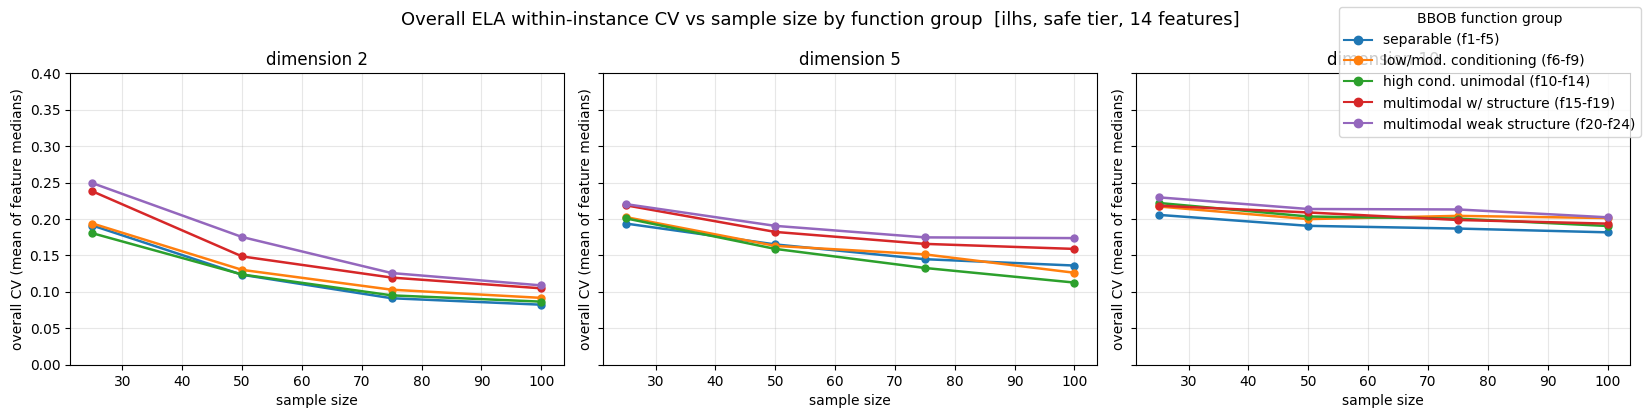

In [15]:
P1.plot_cv_vs_size_by_function_group(src, strategy='ilhs', tier='safe', ylim=(0,0.4))
plt.show()

### Considering all ELA features

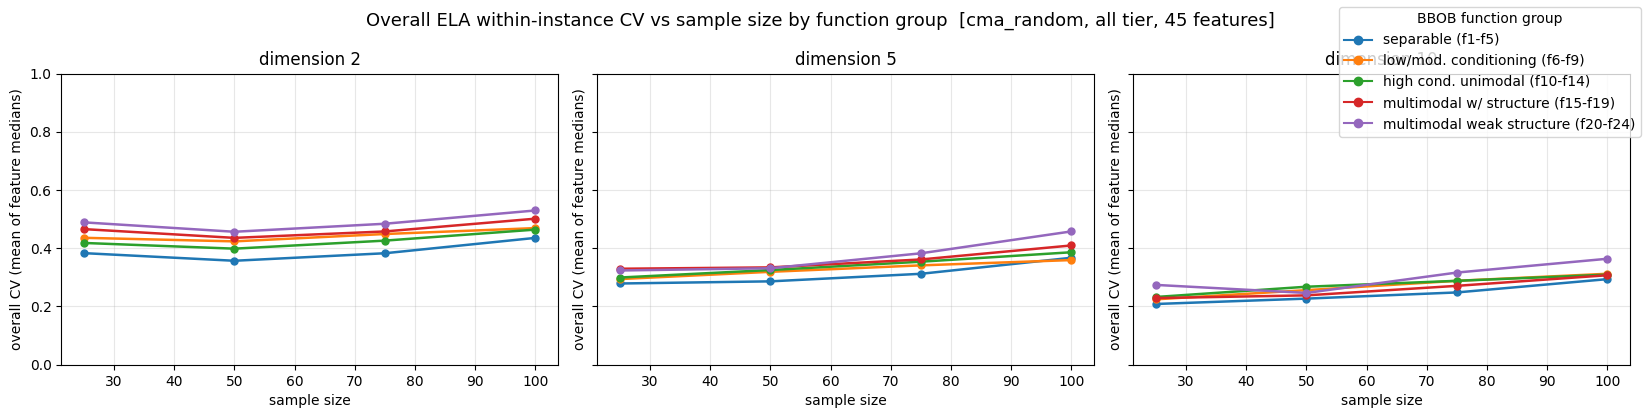

In [16]:
P1.plot_cv_vs_size_by_function_group(src, strategy='cma_random', tier='all', ylim=(0,1.00))
plt.show()

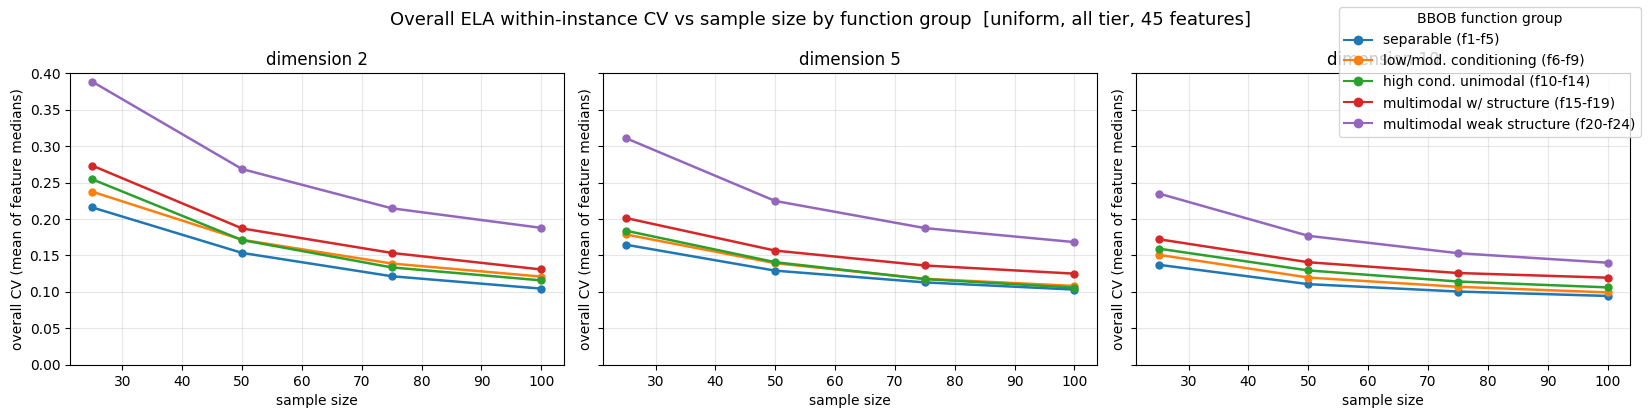

In [17]:
P1.plot_cv_vs_size_by_function_group(src, strategy='uniform', tier='all', ylim=(0,0.4))
plt.show()

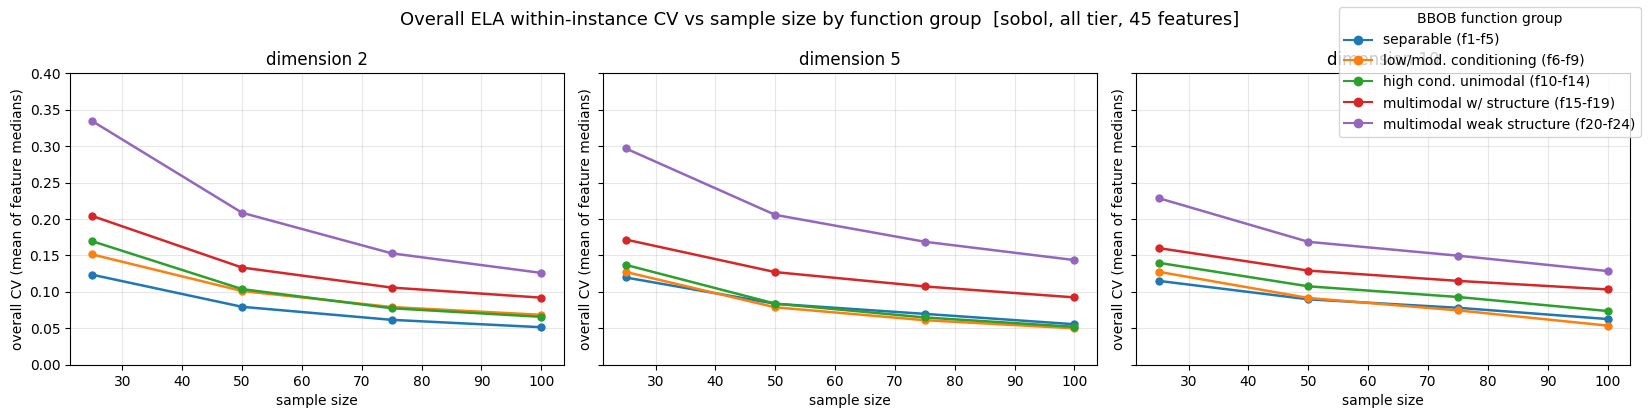

In [18]:
P1.plot_cv_vs_size_by_function_group(src, strategy='sobol', tier='all', ylim=(0,0.4))
plt.show()

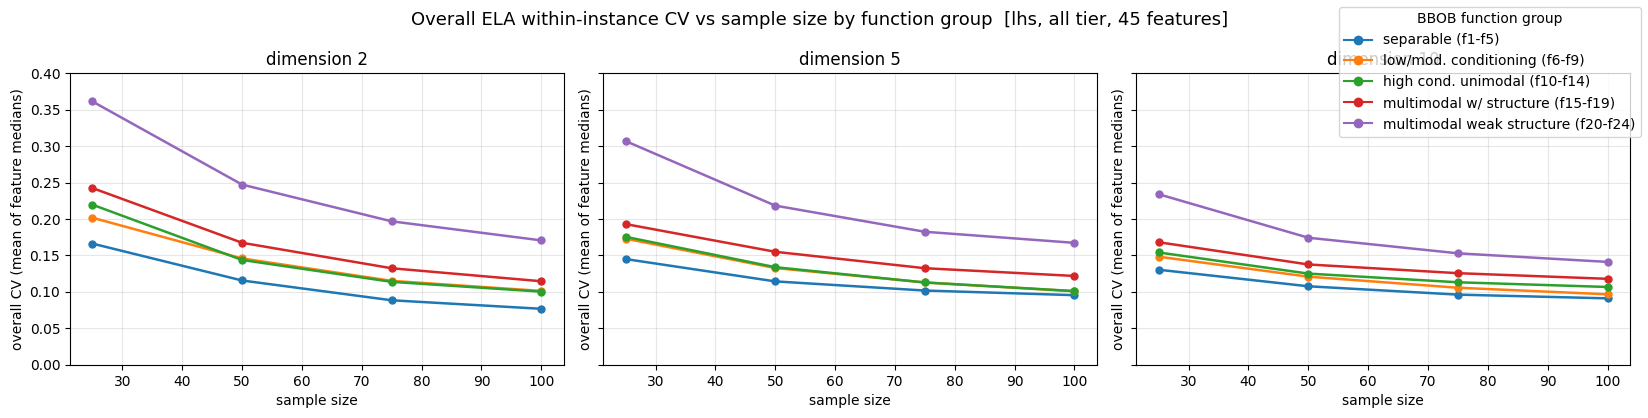

In [19]:
P1.plot_cv_vs_size_by_function_group(src, strategy='lhs', tier='all', ylim=(0,0.4))
plt.show()

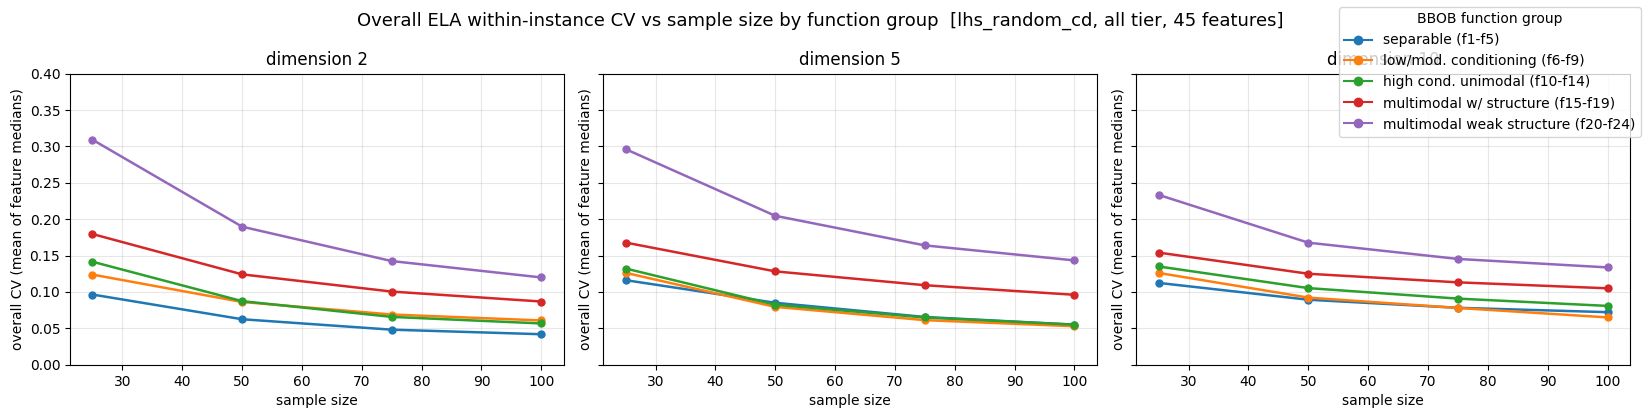

In [20]:
P1.plot_cv_vs_size_by_function_group(src, strategy='lhs_random_cd', tier='all', ylim=(0,0.4))
plt.show()

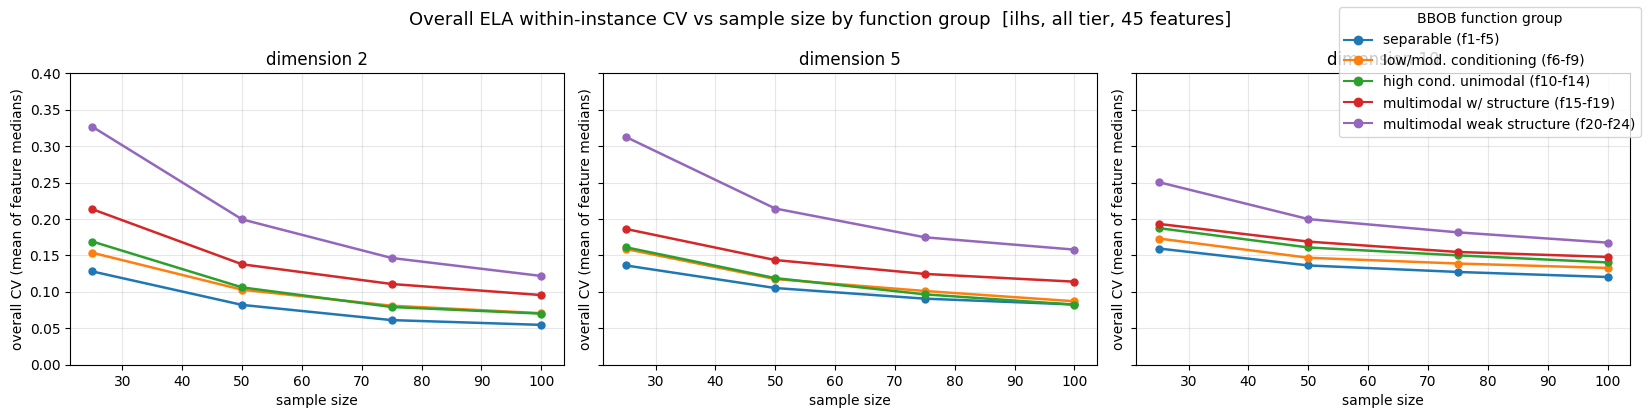

In [21]:
P1.plot_cv_vs_size_by_function_group(src, strategy='ilhs', tier='all', ylim=(0,0.4))
plt.show()

## Heatmap

### Considering only safe ELA features

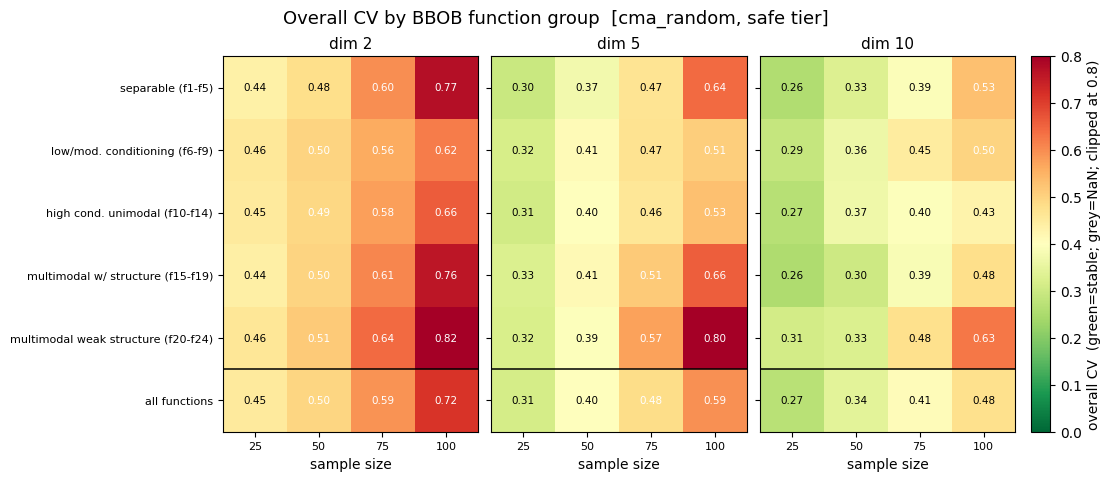

In [22]:
P1.heatmap_cv_by_function_group(src, strategy='cma_random', tier='safe', vmax=0.8)
plt.show()

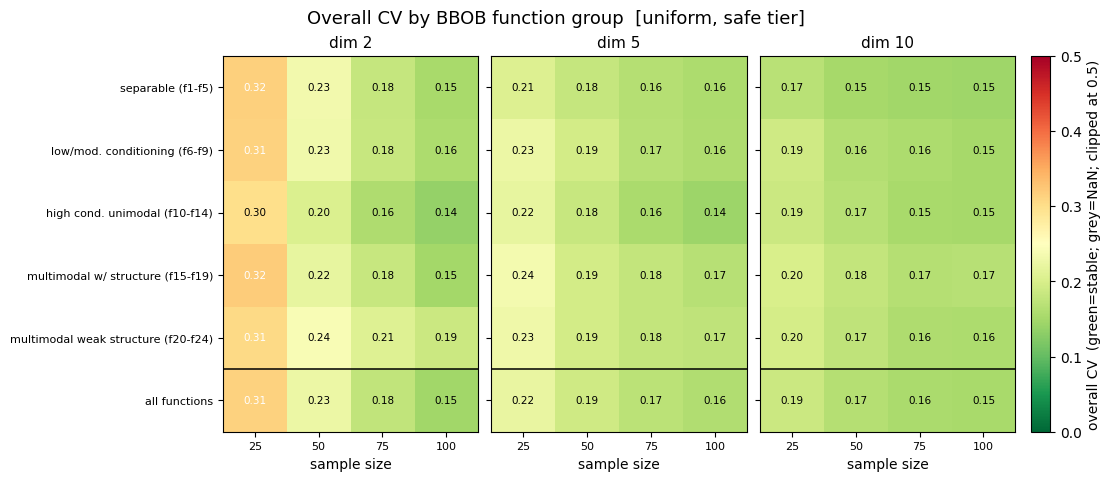

In [23]:
P1.heatmap_cv_by_function_group(src, strategy='uniform', tier='safe', vmax= 0.5)
plt.show()


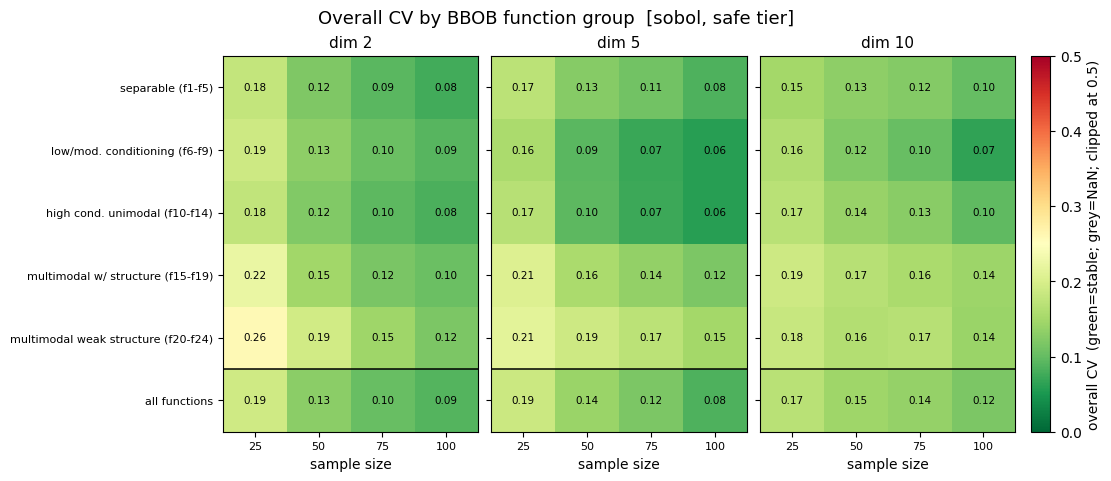

In [24]:
P1.heatmap_cv_by_function_group(src, strategy='sobol', tier='safe', vmax=0.5)
plt.show()


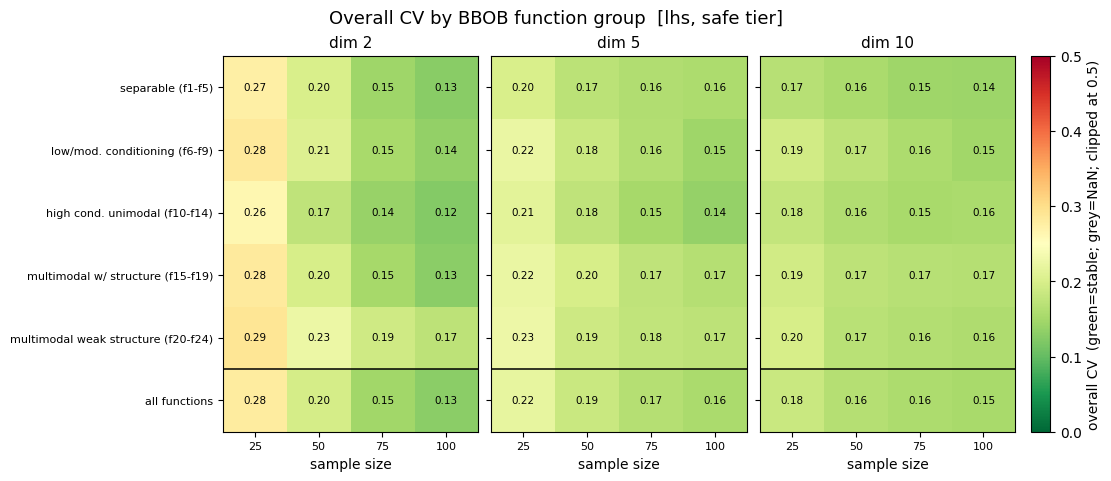

In [25]:
P1.heatmap_cv_by_function_group(src, strategy='lhs', tier='safe', vmax=0.5)
plt.show()

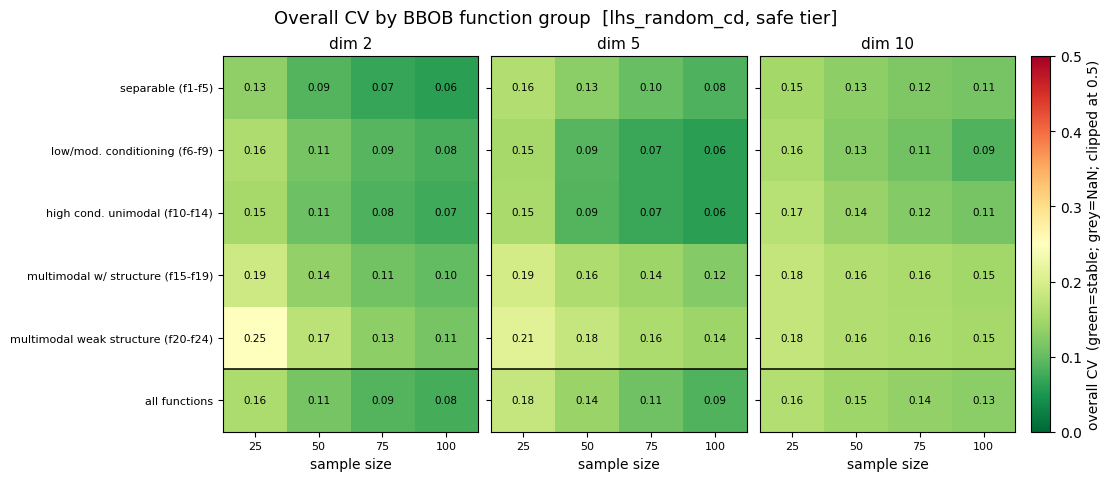

In [26]:
P1.heatmap_cv_by_function_group(src, strategy='lhs_random_cd', tier='safe', vmax=0.5)
plt.show()

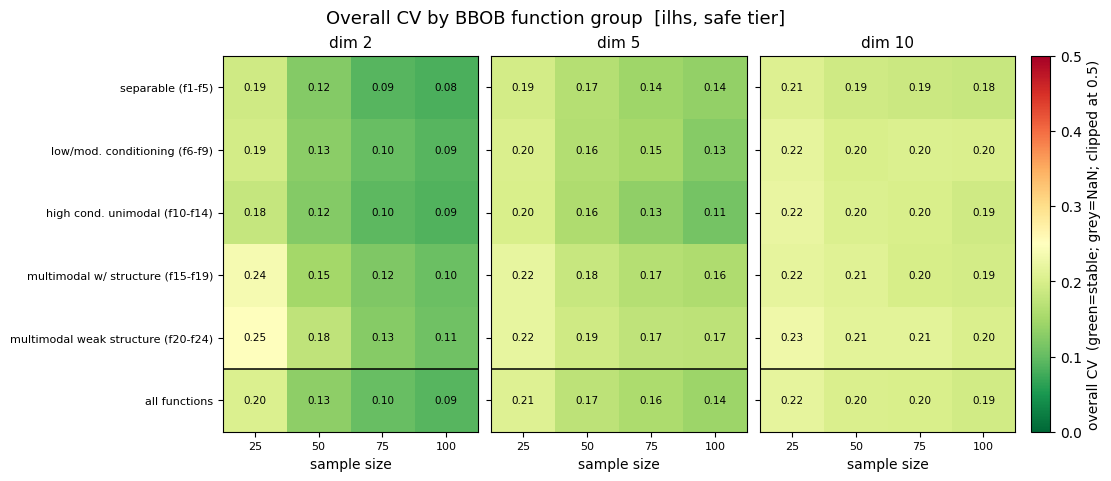

In [27]:
P1.heatmap_cv_by_function_group(src, strategy='ilhs', tier='safe', vmax=0.5)
plt.show()

## Considering ALL ELA features

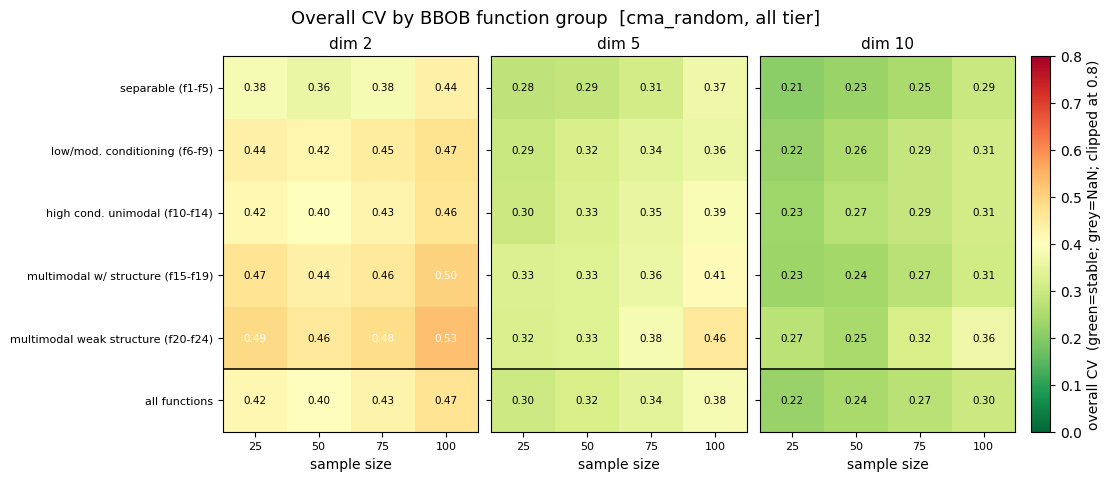

In [28]:
P1.heatmap_cv_by_function_group(src, strategy='cma_random', tier='all', vmax=0.8)
plt.show()

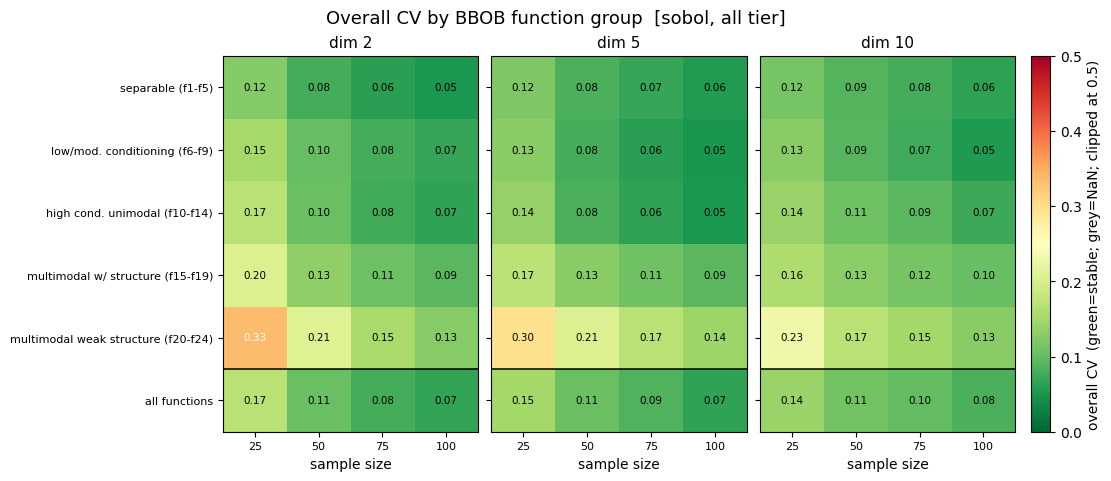

In [29]:
P1.heatmap_cv_by_function_group(src, strategy='sobol', tier='all', vmax=0.5)
plt.show()

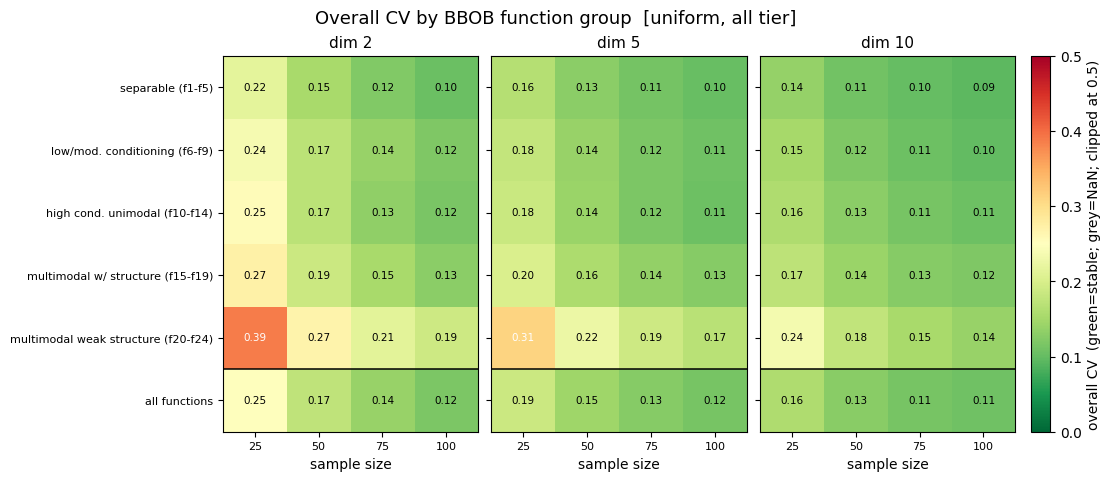

In [30]:
P1.heatmap_cv_by_function_group(src, strategy='uniform', tier='all', vmax=0.5)
plt.show()

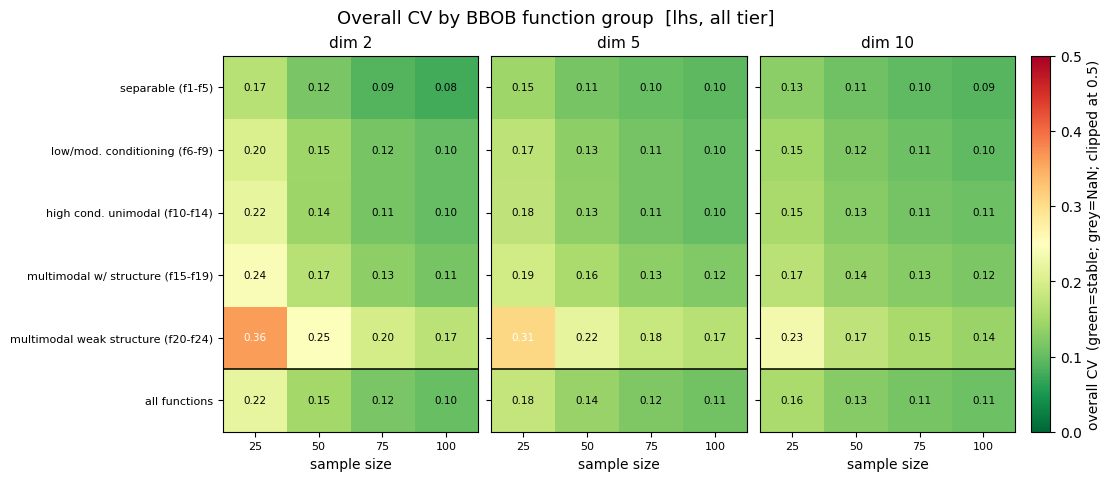

In [31]:
P1.heatmap_cv_by_function_group(src, strategy='lhs', tier='all', vmax=0.5)
plt.show()

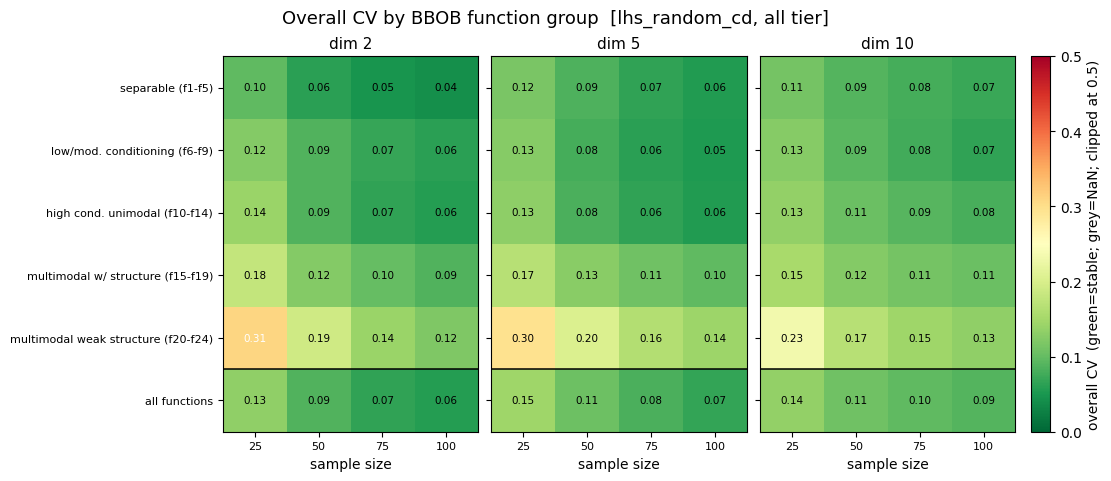

In [32]:
P1.heatmap_cv_by_function_group(src, strategy='lhs_random_cd', tier='all', vmax=0.5)
plt.show()

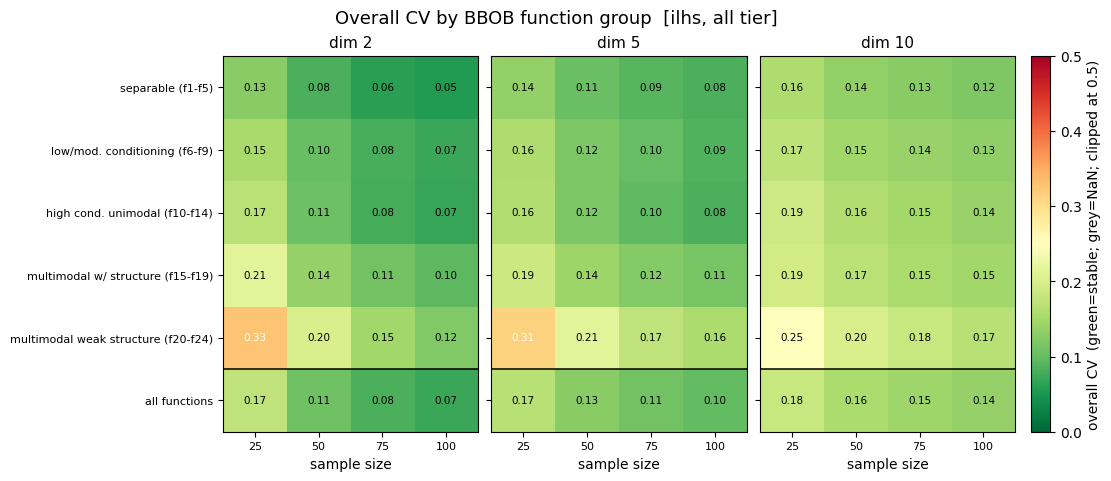

In [33]:
P1.heatmap_cv_by_function_group(src, strategy='ilhs', tier='all', vmax=0.5)
plt.show()

## Scatter with ICC

In [3]:
import scatter_cv_vs_icc as S

icc_src = {
    2: Path("/Users/leekaijen/t7ssd/featELA/dim2featELA/ela_icc_results.pkl"),
    5: Path("/Users/leekaijen/t7ssd/featELA/dim5featELA/ela_icc_results.pkl"),
    10: Path("/Users/leekaijen/t7ssd/featELA/dim10featELA/ela_icc_results.pkl"),
}

### Dimension 2


[cma_random, n=25, dim 2]  (CV<0.2, ICC>=0.75)
  [reliable & reproducible]  0 feature(s)
  [discriminative but noisy]  0 feature(s)
  [stable but non-discriminative]  16 feature(s)
      pca.expl_var.cov_init              CV=0.000  ICC=0.485  (caveat)
      ic.eps_s                           CV=0.097  ICC=0.082  (caveat)
      pca.expl_var.cor_init              CV=0.177  ICC=0.066  (caveat)
      pca.expl_var_PC1.cor_init          CV=0.158  ICC=0.055  (caveat)
      ela_meta.quad_w_interact.adj_r2    CV=0.034  ICC=0.028  (excluded)
      ic.h_max                           CV=0.069  ICC=0.016  (safe)
      nbc.nn_nb.mean_ratio               CV=0.074  ICC=0.015  (safe)
      pca.expl_var_PC1.cov_init          CV=0.001  ICC=0.013  (caveat)
      nbc.nn_nb.sd_ratio                 CV=0.181  ICC=0.013  (safe)
      nbc.dist_ratio.coeff_var           CV=0.101  ICC=0.010  (caveat)
      nbc.nn_nb.cor                      CV=0.197  ICC=0.009  (excluded)
      ic.m0                            

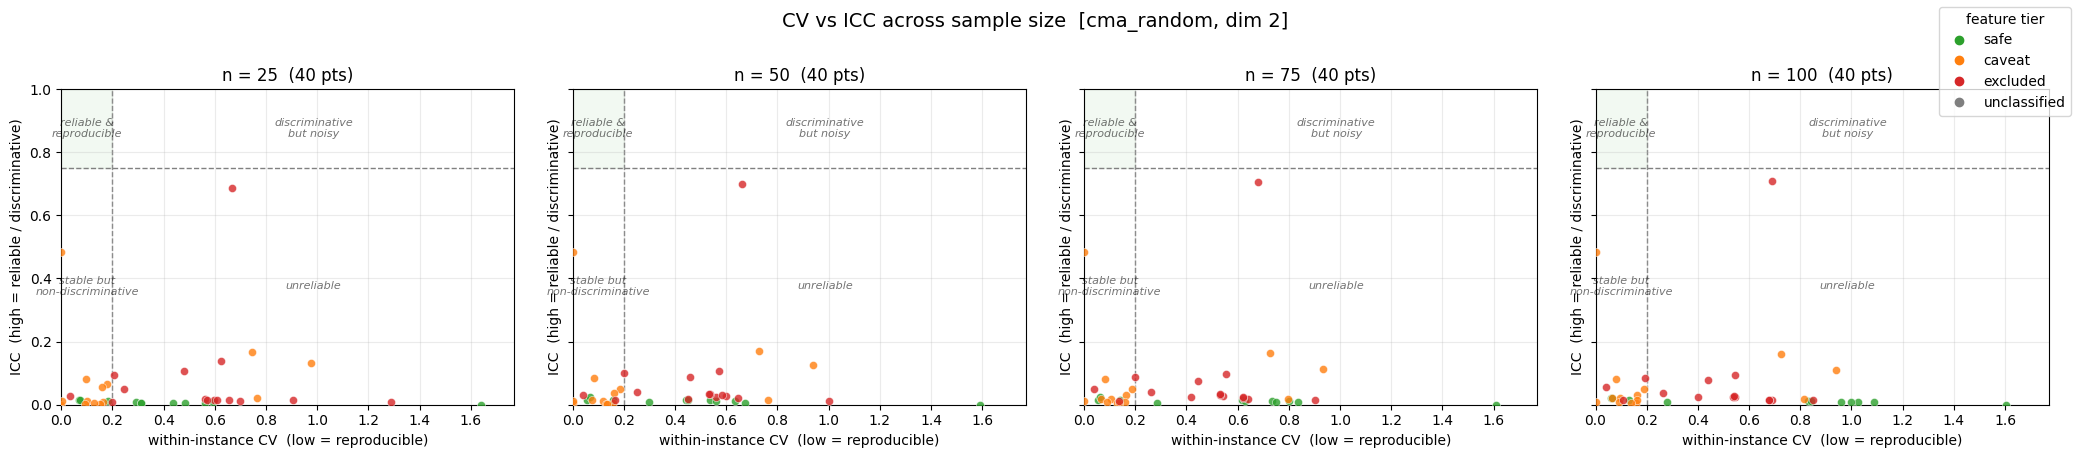

In [35]:
S.scatter_cv_vs_icc_over_size(src, icc_src, dimension=2, strategy="cma_random")
plt.show()


[uniform, n=25, dim 2]  (CV<0.2, ICC>=0.75)
  [reliable & reproducible]  3 feature(s)
      ela_meta.lin_simple.intercept      CV=0.083  ICC=0.987  (excluded)
      ela_meta.lin_w_interact.adj_r2     CV=0.156  ICC=0.841  (excluded)
      pca.expl_var_PC1.cov_init          CV=0.000  ICC=0.775  (caveat)
  [discriminative but noisy]  2 feature(s)
      ela_meta.lin_simple.coef.max       CV=0.219  ICC=0.918  (caveat)
      ela_meta.lin_simple.adj_r2         CV=0.235  ICC=0.878  (excluded)
  [stable but non-discriminative]  16 feature(s)
      ela_meta.quad_simple.adj_r2        CV=0.075  ICC=0.743  (excluded)
      pca.expl_var.cor_init              CV=0.000  ICC=0.712  (caveat)
      ic.eps_s                           CV=0.037  ICC=0.702  (caveat)
      pca.expl_var_PC1.cor_init          CV=0.070  ICC=0.626  (caveat)
      ela_meta.quad_w_interact.adj_r2    CV=0.007  ICC=0.611  (excluded)
      pca.expl_var.cov_init              CV=0.000  ICC=0.485  (caveat)
      nbc.nb_fitness.cor      

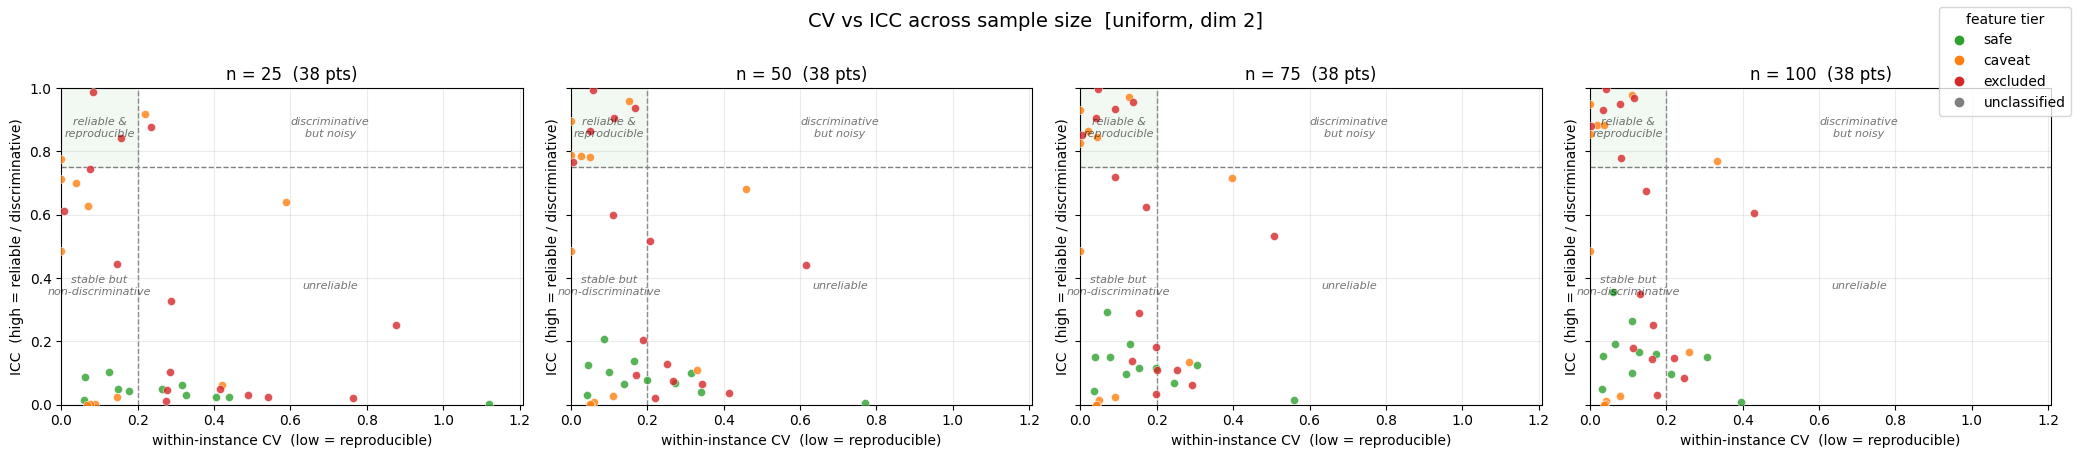

In [36]:
S.scatter_cv_vs_icc_over_size(src, icc_src, dimension=2, strategy="uniform")
plt.show()


[sobol, n=25, dim 2]  (CV<0.2, ICC>=0.75)
  [reliable & reproducible]  10 feature(s)
      ela_meta.lin_simple.intercept      CV=0.024  ICC=0.999  (excluded)
      ela_meta.lin_simple.coef.max       CV=0.083  ICC=0.987  (caveat)
      ela_meta.lin_simple.adj_r2         CV=0.120  ICC=0.970  (excluded)
      ela_meta.lin_w_interact.adj_r2     CV=0.067  ICC=0.968  (excluded)
      ela_meta.quad_simple.adj_r2        CV=0.030  ICC=0.950  (excluded)
      pca.expl_var_PC1.cor_init          CV=0.025  ICC=0.933  (caveat)
      pca.expl_var_PC1.cov_init          CV=0.000  ICC=0.906  (caveat)
      pca.expl_var.cor_init              CV=0.000  ICC=0.883  (caveat)
      ic.eps_s                           CV=0.027  ICC=0.803  (caveat)
      ela_meta.quad_w_interact.adj_r2    CV=0.004  ICC=0.763  (excluded)
  [discriminative but noisy]  1 feature(s)
      ela_meta.lin_simple.coef.min       CV=0.286  ICC=0.778  (caveat)
  [stable but non-discriminative]  15 feature(s)
      ela_distr.skewness       

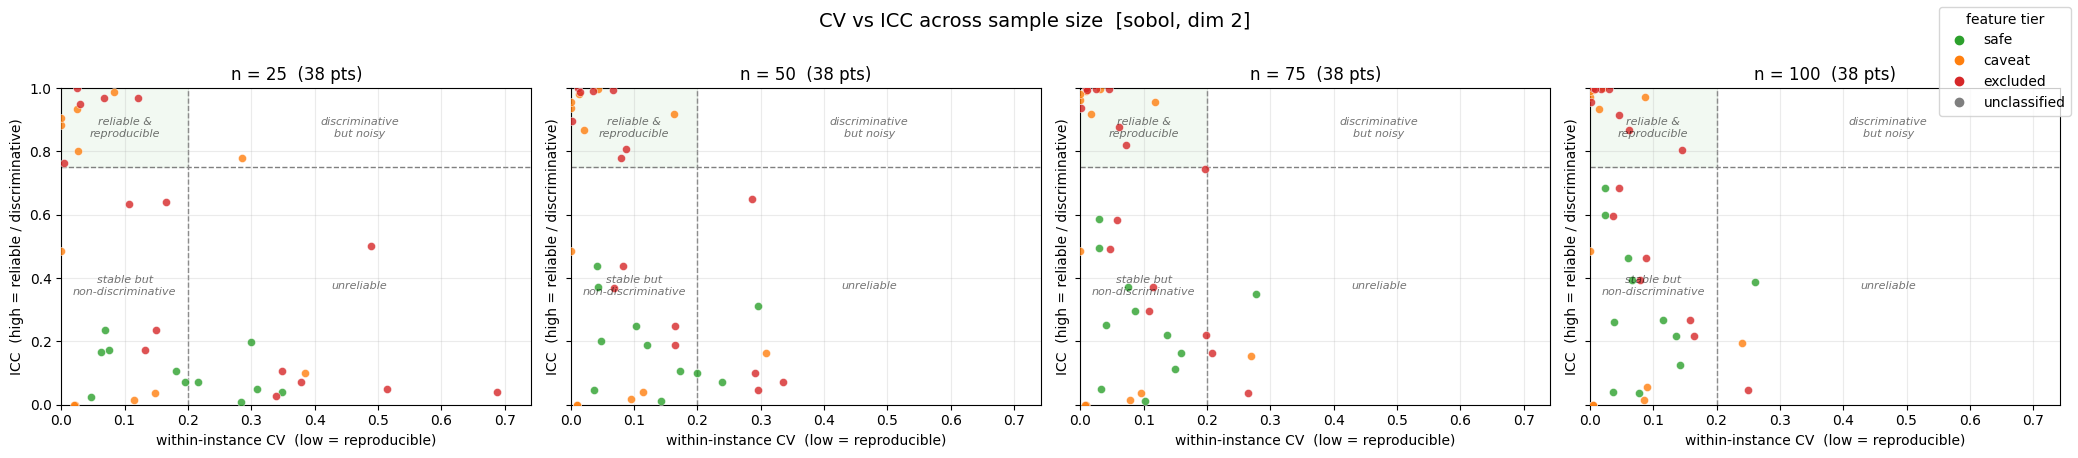

In [37]:
S.scatter_cv_vs_icc_over_size(src, icc_src, dimension=2, strategy="sobol")
plt.show()



[lhs, n=25, dim 2]  (CV<0.2, ICC>=0.75)
  [reliable & reproducible]  8 feature(s)
      ela_meta.lin_simple.intercept      CV=0.033  ICC=0.999  (excluded)
      ela_meta.lin_simple.coef.max       CV=0.129  ICC=0.958  (caveat)
      ela_meta.lin_simple.adj_r2         CV=0.170  ICC=0.938  (excluded)
      ela_meta.lin_w_interact.adj_r2     CV=0.123  ICC=0.893  (excluded)
      ela_meta.quad_simple.adj_r2        CV=0.054  ICC=0.887  (excluded)
      pca.expl_var_PC1.cov_init          CV=0.000  ICC=0.838  (caveat)
      pca.expl_var.cor_init              CV=0.000  ICC=0.786  (caveat)
      ic.eps_s                           CV=0.032  ICC=0.755  (caveat)
  [discriminative but noisy]  0 feature(s)
  [stable but non-discriminative]  13 feature(s)
      ela_meta.quad_w_interact.adj_r2    CV=0.005  ICC=0.674  (excluded)
      pca.expl_var_PC1.cor_init          CV=0.062  ICC=0.661  (caveat)
      nbc.nb_fitness.cor                 CV=0.126  ICC=0.514  (excluded)
      pca.expl_var.cov_init     

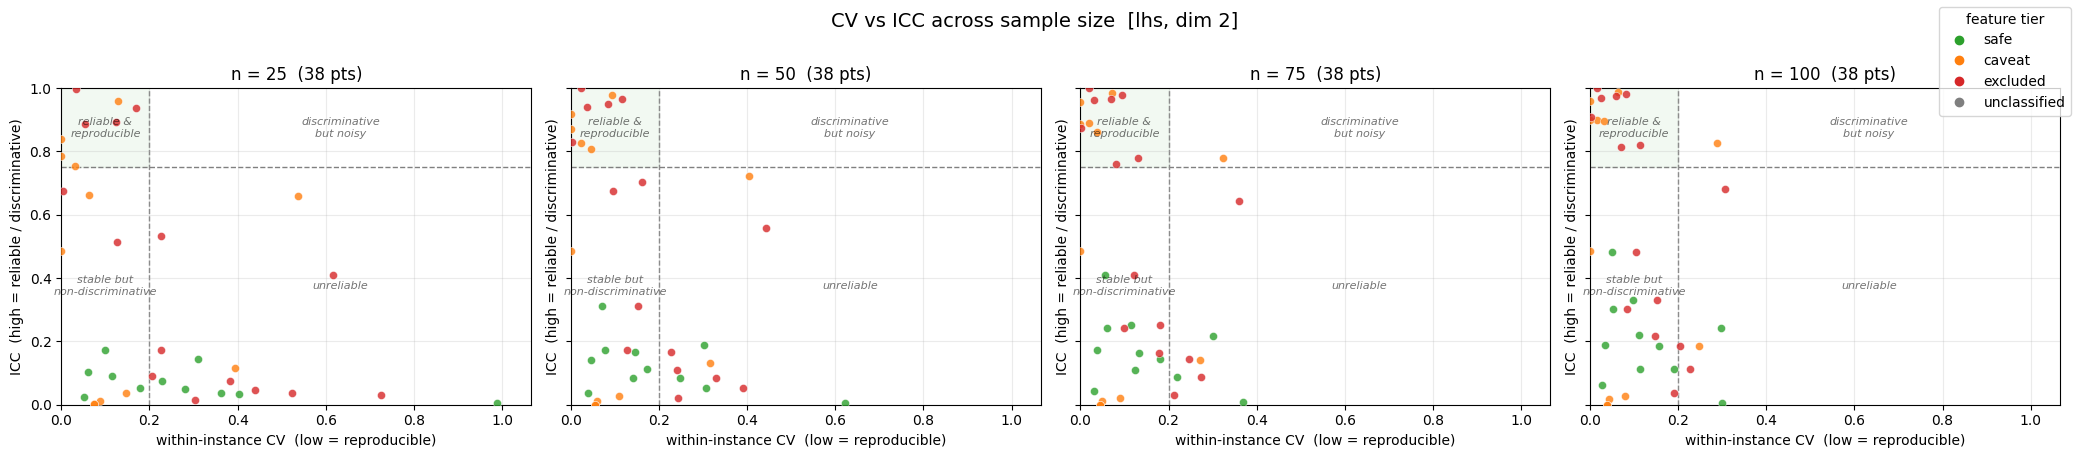

In [38]:
S.scatter_cv_vs_icc_over_size(src, icc_src, dimension=2, strategy="lhs")
plt.show()



[lhs_random_cd, n=25, dim 2]  (CV<0.2, ICC>=0.75)
  [reliable & reproducible]  12 feature(s)
      ela_meta.lin_simple.intercept      CV=0.008  ICC=1.000  (excluded)
      ela_meta.lin_simple.coef.max       CV=0.026  ICC=0.999  (caveat)
      ela_meta.lin_simple.adj_r2         CV=0.042  ICC=0.995  (excluded)
      ela_meta.lin_w_interact.adj_r2     CV=0.024  ICC=0.995  (excluded)
      pca.expl_var_PC1.cor_init          CV=0.007  ICC=0.992  (caveat)
      ela_meta.quad_simple.adj_r2        CV=0.012  ICC=0.987  (excluded)
      pca.expl_var_PC1.cov_init          CV=0.000  ICC=0.979  (caveat)
      pca.expl_var.cor_init              CV=0.000  ICC=0.959  (caveat)
      ela_meta.lin_simple.coef.min       CV=0.115  ICC=0.951  (caveat)
      ela_meta.quad_w_interact.adj_r2    CV=0.003  ICC=0.862  (excluded)
      ela_distr.skewness                 CV=0.077  ICC=0.848  (excluded)
      ic.eps_s                           CV=0.024  ICC=0.843  (caveat)
  [discriminative but noisy]  0 feature(s)

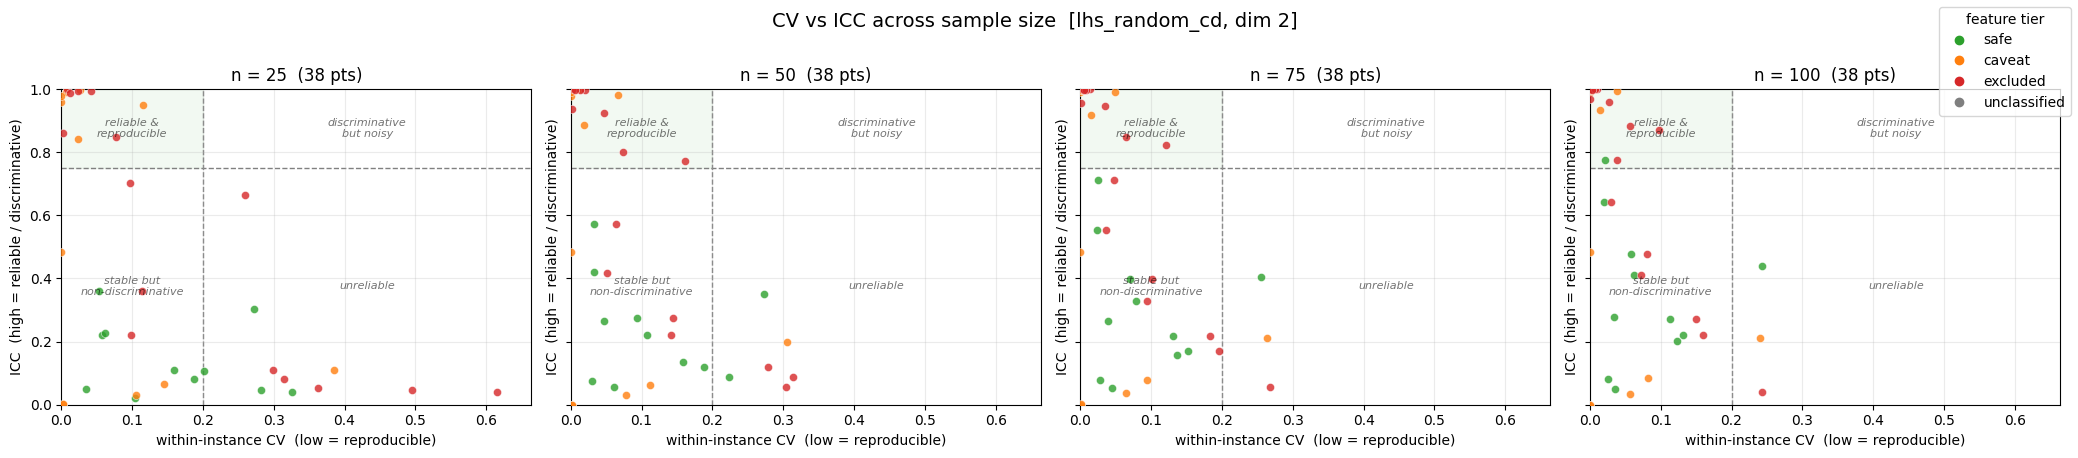

In [39]:
S.scatter_cv_vs_icc_over_size(src, icc_src, dimension=2, strategy="lhs_random_cd")
plt.show()



[ilhs, n=25, dim 2]  (CV<0.2, ICC>=0.75)
  [reliable & reproducible]  10 feature(s)
      ela_meta.lin_simple.intercept      CV=0.022  ICC=0.999  (excluded)
      ela_meta.lin_simple.coef.max       CV=0.083  ICC=0.982  (caveat)
      ela_meta.lin_simple.adj_r2         CV=0.121  ICC=0.971  (excluded)
      ela_meta.lin_w_interact.adj_r2     CV=0.080  ICC=0.959  (excluded)
      ela_meta.quad_simple.adj_r2        CV=0.035  ICC=0.953  (excluded)
      pca.expl_var_PC1.cov_init          CV=0.000  ICC=0.896  (caveat)
      pca.expl_var.cor_init              CV=0.000  ICC=0.883  (caveat)
      pca.expl_var_PC1.cor_init          CV=0.036  ICC=0.859  (caveat)
      ic.eps_s                           CV=0.026  ICC=0.808  (caveat)
      ela_meta.quad_w_interact.adj_r2    CV=0.004  ICC=0.783  (excluded)
  [discriminative but noisy]  0 feature(s)
  [stable but non-discriminative]  14 feature(s)
      ela_distr.skewness                 CV=0.160  ICC=0.651  (excluded)
      nbc.nb_fitness.cor      

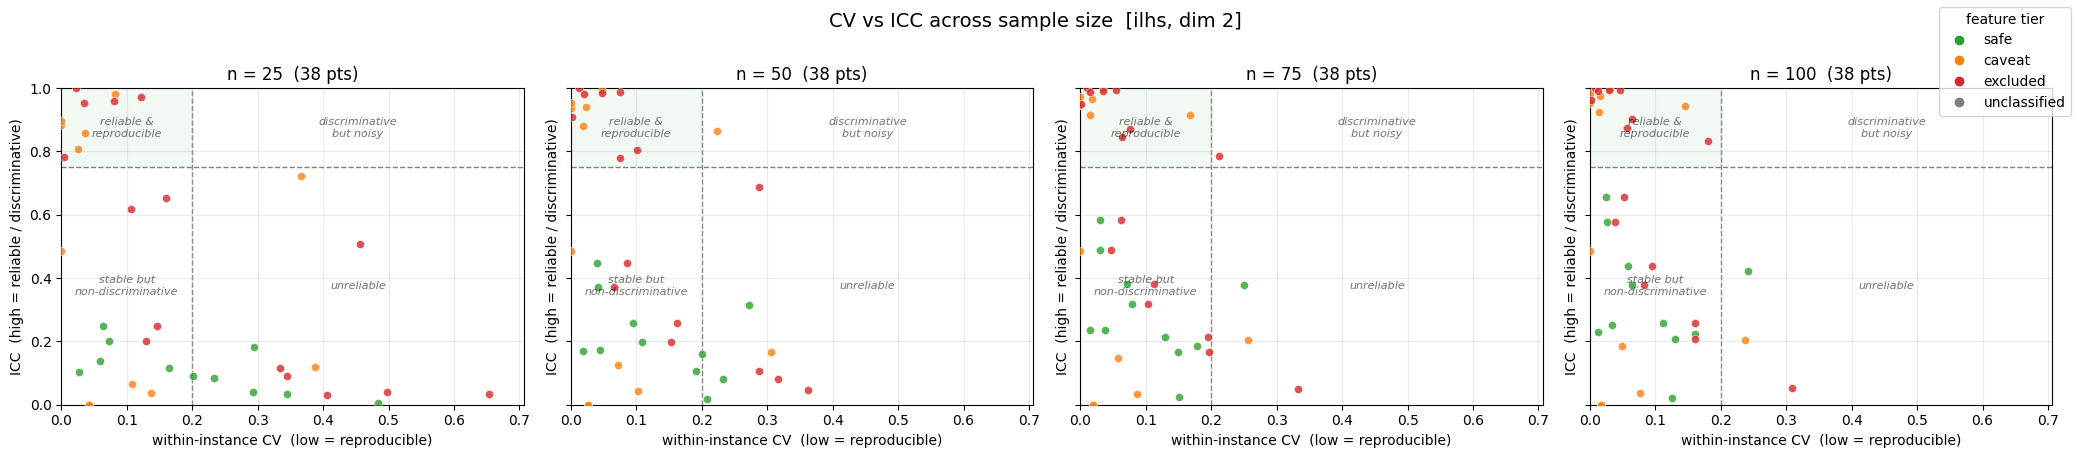

In [40]:
S.scatter_cv_vs_icc_over_size(src, icc_src, dimension=2, strategy="ilhs")
plt.show()

### Dimension 5


[cma_random, n=25, dim 5]  (CV<0.2, ICC>=0.75)
  [reliable & reproducible]  0 feature(s)
  [discriminative but noisy]  0 feature(s)
  [stable but non-discriminative]  20 feature(s)
      pca.expl_var.cov_init              CV=0.000  ICC=0.485  (caveat)
      ic.eps_s                           CV=0.080  ICC=0.086  (caveat)
      ela_meta.quad_simple.adj_r2        CV=0.157  ICC=0.074  (excluded)
      ic.eps_ratio                       CV=0.121  ICC=0.045  (safe)
      ela_meta.quad_w_interact.adj_r2    CV=0.017  ICC=0.035  (excluded)
      pca.expl_var_PC1.cov_init          CV=0.001  ICC=0.030  (caveat)
      pca.expl_var.cor_init              CV=0.093  ICC=0.022  (caveat)
      ic.h_max                           CV=0.039  ICC=0.018  (safe)
      nbc.nn_nb.mean_ratio               CV=0.021  ICC=0.011  (safe)
      pca.expl_var_PC1.cov_x             CV=0.176  ICC=0.010  (caveat)
      pca.expl_var_PC1.cor_init          CV=0.174  ICC=0.010  (caveat)
      nbc.nn_nb.sd_ratio               

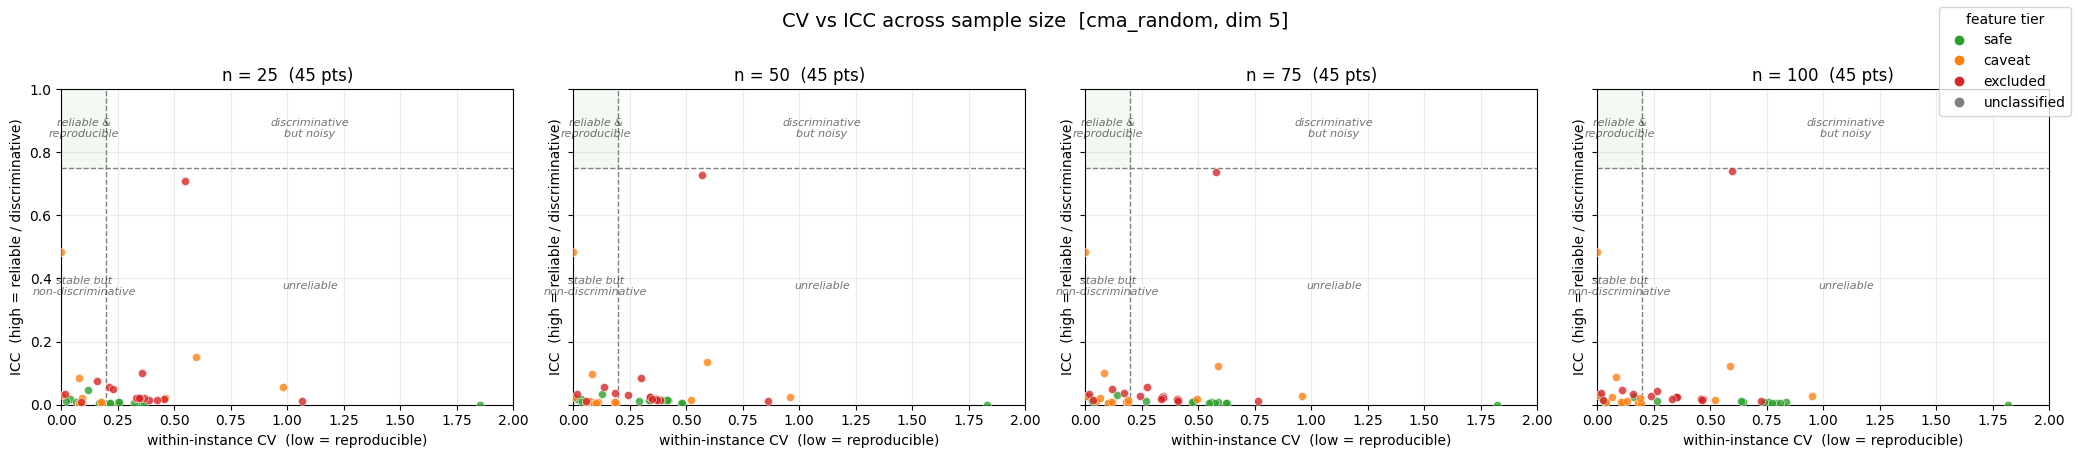

In [41]:
S.scatter_cv_vs_icc_over_size(src, icc_src, dimension=5, strategy="cma_random")
plt.show()


[uniform, n=25, dim 5]  (CV<0.2, ICC>=0.75)
  [reliable & reproducible]  4 feature(s)
      ela_meta.lin_simple.intercept      CV=0.045  ICC=0.994  (excluded)
      ela_meta.lin_simple.coef.max       CV=0.158  ICC=0.933  (caveat)
      pca.expl_var_PC1.cov_init          CV=0.000  ICC=0.843  (caveat)
      ela_meta.lin_w_interact.adj_r2     CV=0.086  ICC=0.753  (excluded)
  [discriminative but noisy]  0 feature(s)
  [stable but non-discriminative]  27 feature(s)
      ela_meta.lin_simple.adj_r2         CV=0.163  ICC=0.737  (excluded)
      ic.eps_s                           CV=0.026  ICC=0.716  (caveat)
      ela_meta.quad_simple.adj_r2        CV=0.078  ICC=0.677  (excluded)
      ela_meta.quad_w_interact.adj_r2    CV=0.008  ICC=0.616  (excluded)
      pca.expl_var.cov_init              CV=0.000  ICC=0.485  (caveat)
      ic.eps_ratio                       CV=0.055  ICC=0.398  (safe)
      pca.expl_var_PC1.cor_init          CV=0.054  ICC=0.324  (caveat)
      nbc.nb_fitness.cor        

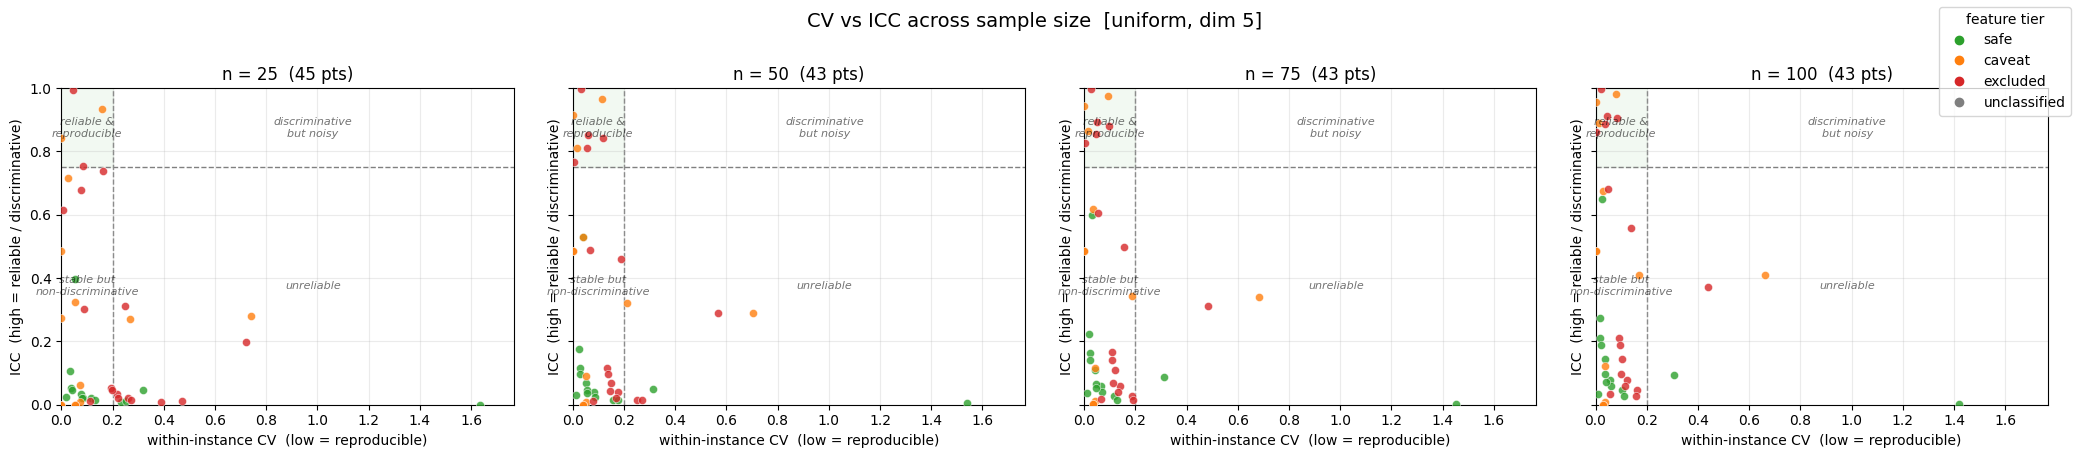

In [42]:
S.scatter_cv_vs_icc_over_size(src, icc_src, dimension=5, strategy="uniform")
plt.show()


[sobol, n=25, dim 5]  (CV<0.2, ICC>=0.75)
  [reliable & reproducible]  8 feature(s)
      ela_meta.lin_simple.intercept      CV=0.009  ICC=1.000  (excluded)
      ela_meta.lin_simple.coef.max       CV=0.056  ICC=0.988  (caveat)
      pca.expl_var_PC1.cov_init          CV=0.000  ICC=0.944  (caveat)
      ela_meta.lin_w_interact.adj_r2     CV=0.041  ICC=0.888  (excluded)
      ela_meta.lin_simple.adj_r2         CV=0.085  ICC=0.883  (excluded)
      pca.expl_var_PC1.cor_init          CV=0.017  ICC=0.831  (caveat)
      ela_meta.quad_simple.adj_r2        CV=0.044  ICC=0.794  (excluded)
      ic.eps_s                           CV=0.022  ICC=0.790  (caveat)
  [discriminative but noisy]  0 feature(s)
  [stable but non-discriminative]  25 feature(s)
      ela_meta.quad_w_interact.adj_r2    CV=0.006  ICC=0.700  (excluded)
      ic.eps_ratio                       CV=0.051  ICC=0.527  (safe)
      pca.expl_var.cor_init              CV=0.000  ICC=0.485  (caveat)
      pca.expl_var.cov_init       

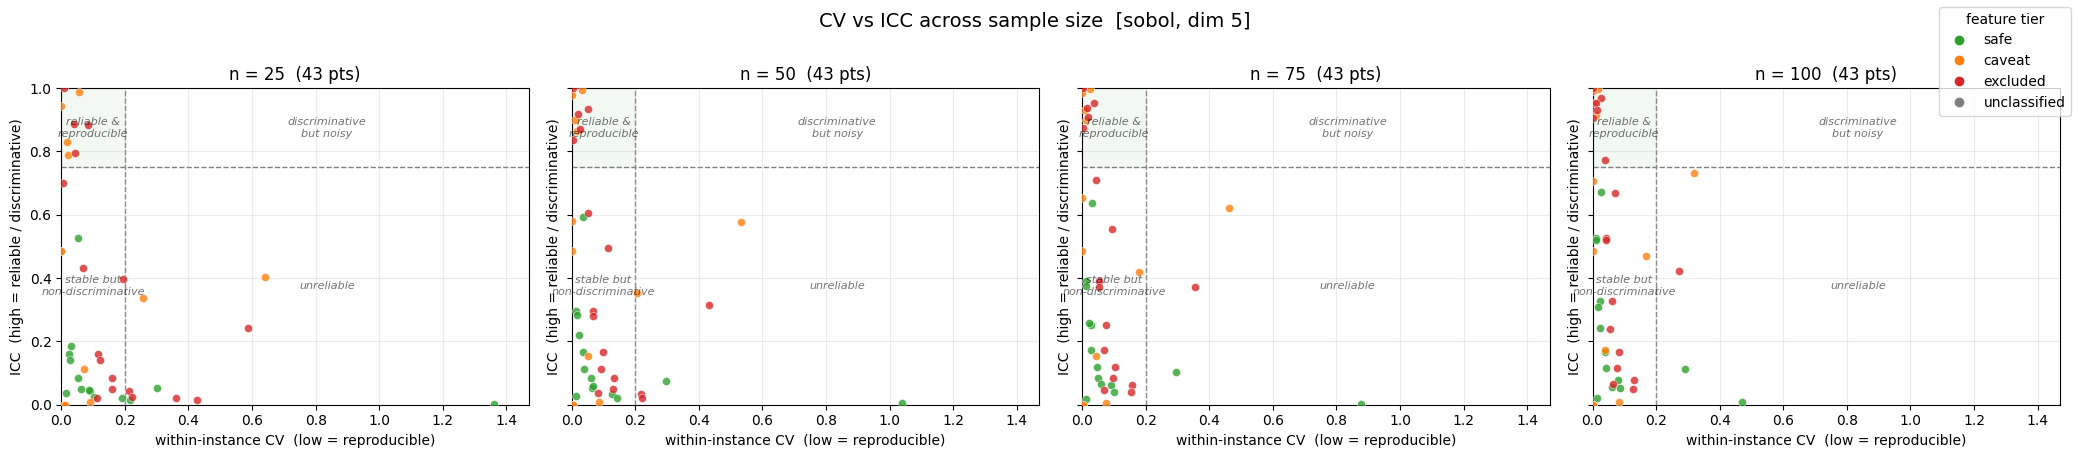

In [43]:
S.scatter_cv_vs_icc_over_size(src, icc_src, dimension=5, strategy="sobol")
plt.show()


[lhs, n=25, dim 5]  (CV<0.2, ICC>=0.75)
  [reliable & reproducible]  5 feature(s)
      ela_meta.lin_simple.intercept      CV=0.020  ICC=1.000  (excluded)
      ela_meta.lin_simple.coef.max       CV=0.124  ICC=0.960  (caveat)
      pca.expl_var_PC1.cov_init          CV=0.000  ICC=0.873  (caveat)
      ela_meta.lin_w_interact.adj_r2     CV=0.076  ICC=0.775  (excluded)
      ela_meta.lin_simple.adj_r2         CV=0.140  ICC=0.761  (excluded)
  [discriminative but noisy]  0 feature(s)
  [stable but non-discriminative]  24 feature(s)
      ic.eps_s                           CV=0.025  ICC=0.735  (caveat)
      ela_meta.quad_simple.adj_r2        CV=0.072  ICC=0.712  (excluded)
      ela_meta.quad_w_interact.adj_r2    CV=0.007  ICC=0.623  (excluded)
      pca.expl_var.cov_init              CV=0.000  ICC=0.485  (caveat)
      ic.eps_ratio                       CV=0.053  ICC=0.419  (safe)
      nbc.nb_fitness.cor                 CV=0.083  ICC=0.345  (excluded)
      pca.expl_var.cor_init       

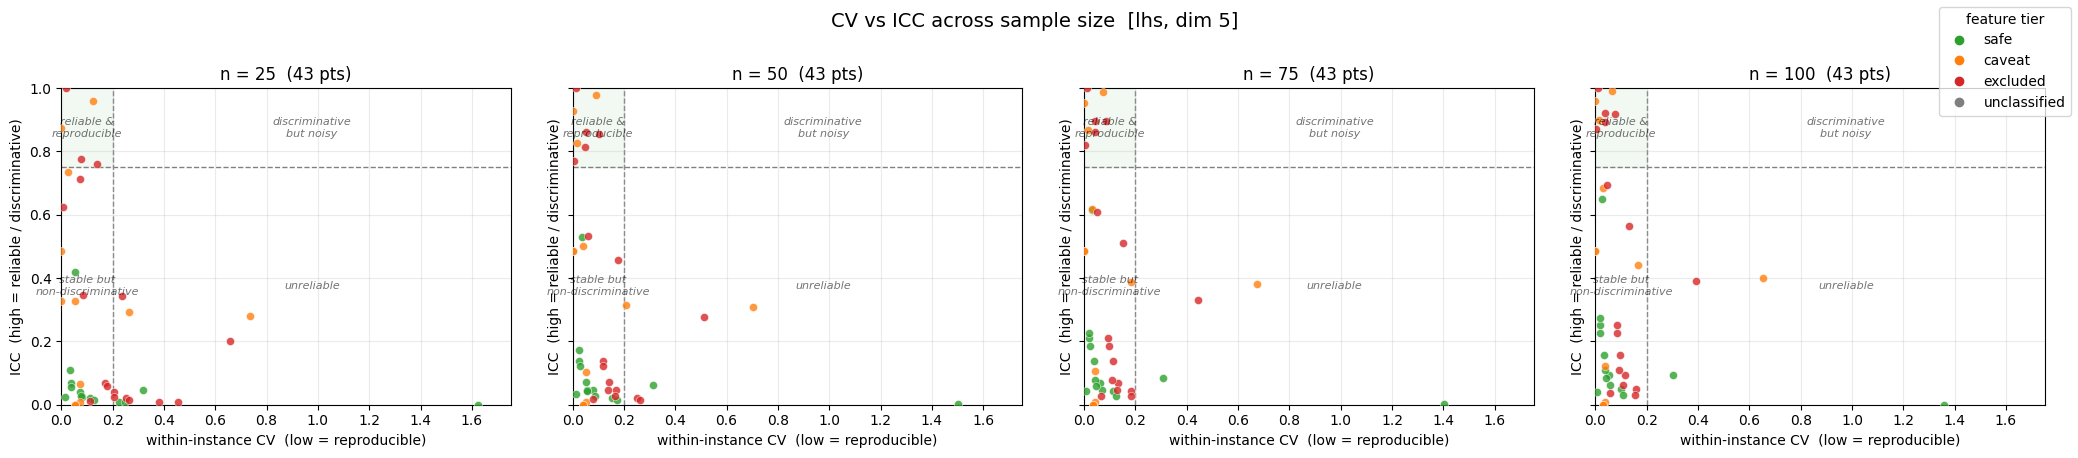

In [44]:
S.scatter_cv_vs_icc_over_size(src, icc_src, dimension=5, strategy="lhs")
plt.show()


[lhs_random_cd, n=25, dim 5]  (CV<0.2, ICC>=0.75)
  [reliable & reproducible]  8 feature(s)
      ela_meta.lin_simple.intercept      CV=0.006  ICC=1.000  (excluded)
      ela_meta.lin_simple.coef.max       CV=0.046  ICC=0.991  (caveat)
      pca.expl_var_PC1.cov_init          CV=0.000  ICC=0.951  (caveat)
      ela_meta.lin_simple.adj_r2         CV=0.076  ICC=0.896  (excluded)
      ela_meta.lin_w_interact.adj_r2     CV=0.038  ICC=0.891  (excluded)
      pca.expl_var_PC1.cor_init          CV=0.014  ICC=0.851  (caveat)
      ela_meta.quad_simple.adj_r2        CV=0.046  ICC=0.805  (excluded)
      ic.eps_s                           CV=0.022  ICC=0.796  (caveat)
  [discriminative but noisy]  0 feature(s)
  [stable but non-discriminative]  25 feature(s)
      ela_meta.quad_w_interact.adj_r2    CV=0.006  ICC=0.709  (excluded)
      ic.eps_ratio                       CV=0.051  ICC=0.493  (safe)
      pca.expl_var.cor_init              CV=0.000  ICC=0.485  (caveat)
      pca.expl_var.cov_ini

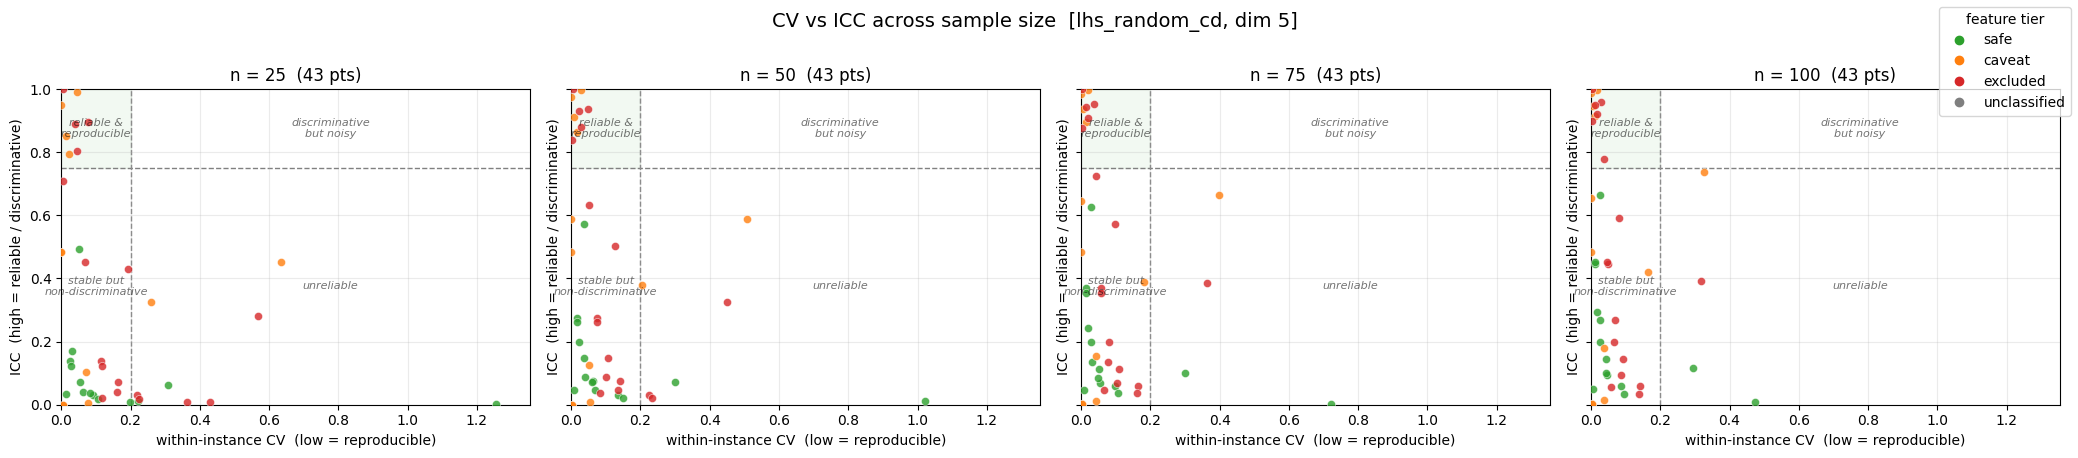

In [45]:
S.scatter_cv_vs_icc_over_size(src, icc_src, dimension=5, strategy="lhs_random_cd")
plt.show()


[ilhs, n=25, dim 5]  (CV<0.2, ICC>=0.75)
  [reliable & reproducible]  7 feature(s)
      ela_meta.lin_simple.intercept      CV=0.017  ICC=1.000  (excluded)
      ela_meta.lin_simple.coef.max       CV=0.102  ICC=0.972  (caveat)
      pca.expl_var_PC1.cov_init          CV=0.000  ICC=0.894  (caveat)
      ela_meta.lin_simple.adj_r2         CV=0.125  ICC=0.808  (excluded)
      ela_meta.lin_w_interact.adj_r2     CV=0.065  ICC=0.808  (excluded)
      ela_meta.quad_simple.adj_r2        CV=0.065  ICC=0.757  (excluded)
      ic.eps_s                           CV=0.023  ICC=0.751  (caveat)
  [discriminative but noisy]  0 feature(s)
  [stable but non-discriminative]  23 feature(s)
      ela_meta.quad_w_interact.adj_r2    CV=0.007  ICC=0.667  (excluded)
      ic.eps_ratio                       CV=0.051  ICC=0.507  (safe)
      pca.expl_var.cor_init              CV=0.000  ICC=0.485  (caveat)
      pca.expl_var.cov_init              CV=0.000  ICC=0.485  (caveat)
      pca.expl_var_PC1.cor_init    

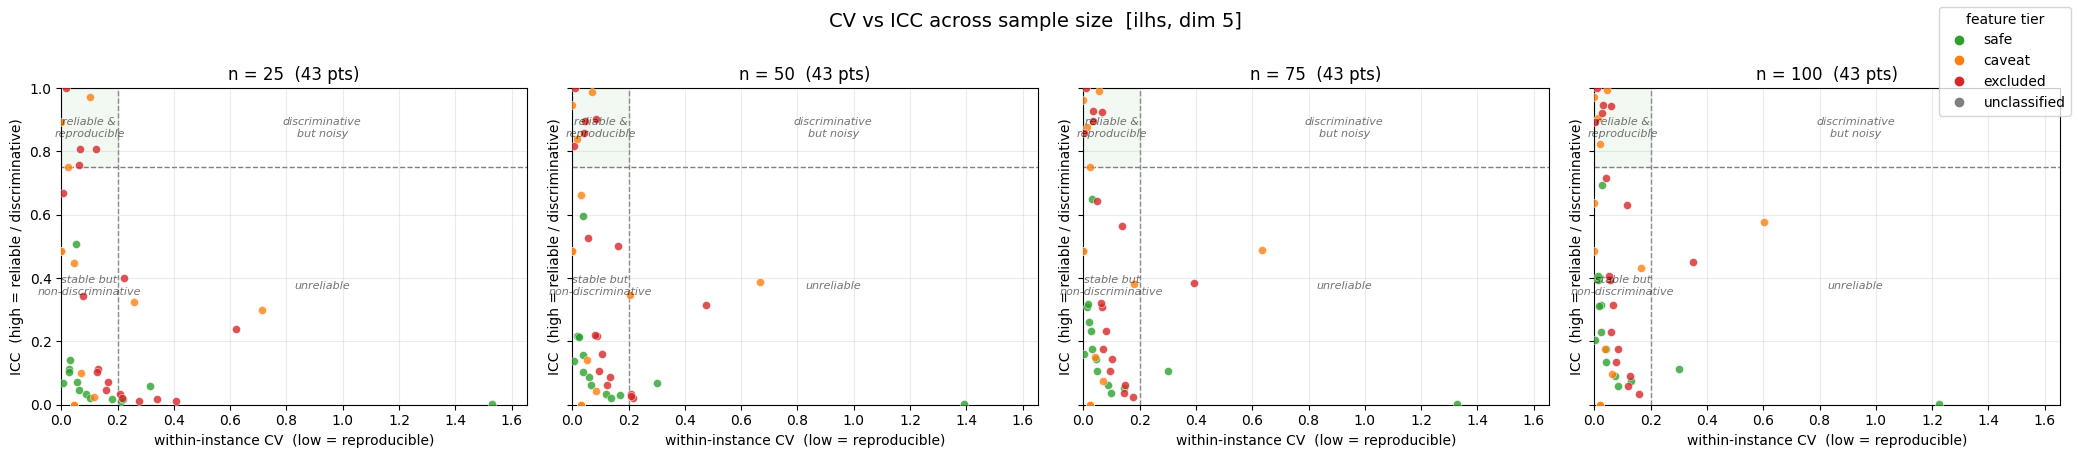

In [46]:
S.scatter_cv_vs_icc_over_size(src, icc_src, dimension=5, strategy="ilhs")
plt.show()

In [47]:
import rank_stability as R

In [48]:
res = R.rank_stability(src, icc_src, tier="safe", by="overall_cv", cv_thresh=0.20, icc_thresh=0.75, cap=None)

Ranked by overall_cv (lower=better) | tier=safe | features=11 shared across dims | cap=None
Thresholds: CV<0.2, ICC>=0.75 | per-feature agg=median (median is clip-robust)

=== dimension 2 — size(=budget xdim) x strategy grid of overall_cv ===
strategy  cma_random  ilhs   lhs  lhs_random_cd  sobol  uniform
size                                                           
25             0.312 0.201 0.229          0.160  0.195    0.264
50             0.452 0.108 0.146          0.093  0.120    0.167
75             0.630 0.080 0.123          0.070  0.086    0.131
100            0.840 0.065 0.111          0.058  0.067    0.111
  strategy ranking (best overall_cv across budgets):
    1. lhs_random_cd    best=0.058  @maxbudget=0.058
    2. ilhs             best=0.065  @maxbudget=0.065
    3. sobol            best=0.067  @maxbudget=0.067
    4. lhs              best=0.111  @maxbudget=0.111
    5. uniform          best=0.111  @maxbudget=0.111
    6. cma_random       best=0.312  @maxbudget=0.840

=

In [49]:
res['by_config']

,dimension,strategy,size,n_feat,overall_cv,overall_icc,keep_count,keep_frac,icc_zero_frac,rank
0,2,lhs_random_cd,100,11,0.058256,0.277097,1,0.090909,0.000000,1
1,2,ilhs,100,11,0.065005,0.256707,0,0.000000,0.000000,2
2,2,sobol,100,11,0.066859,0.268280,0,0.000000,0.000000,3
3,2,lhs_random_cd,75,11,0.070226,0.266650,0,0.000000,0.000000,4
4,2,ilhs,75,11,0.079648,0.235970,0,0.000000,0.000000,5
...,...,...,...,...,...,...,...,...,...,...
67,10,ilhs,25,11,0.040625,0.042292,0,0.000000,0.000000,20
68,10,cma_random,25,11,0.169534,0.012450,0,0.000000,0.090909,21
69,10,cma_random,50,11,0.276038,0.011651,0,0.000000,0.090909,22
70,10,cma_random,75,11,0.375839,0.008187,0,0.000000,0.090909,23


In [50]:
res.keys()

dict_keys(['by_config', 'by_strategy', 'min_budget', 'shared_features', 'n_shared', 'ranked_by'])

In [51]:
res['min_budget']

,dimension,strategy,min_size
0,2,cma_random,NaN
1,2,ilhs,50.0
2,2,lhs,50.0
3,2,lhs_random_cd,25.0
4,2,sobol,25.0
5,2,uniform,50.0
6,5,cma_random,NaN
7,5,ilhs,25.0
8,5,lhs,25.0
9,5,lhs_random_cd,25.0


In [55]:
from icc_by_function_group import *
res = run_group_analysis(icc_src)

collected 72,397 ICC cells | 45 features | 24 functions | dims [2, 5, 10]

=== per-function ICC ceiling (p90 across features, n=100) ===
  dim 2: ceiling ranges 0.008 .. 1.000  (spread 0.992)
      separable (f1-f5)                  median ceiling 0.998
      low/mod. conditioning (f6-f9)      median ceiling 0.996
      high cond. unimodal (f10-f14)      median ceiling 0.996
      multimodal w/ structure (f15-f19)  median ceiling 0.959
      multimodal weak structure (f20-f24) median ceiling 0.039
  dim 5: ceiling ranges 0.006 .. 1.000  (spread 0.993)
      separable (f1-f5)                  median ceiling 0.995
      high cond. unimodal (f10-f14)      median ceiling 0.987
      low/mod. conditioning (f6-f9)      median ceiling 0.984
      multimodal w/ structure (f15-f19)  median ceiling 0.950
      multimodal weak structure (f20-f24) median ceiling 0.008
  dim 10: ceiling ranges 0.011 .. 0.997  (spread 0.986)
      separable (f1-f5)                  median ceiling 0.992
      high co

In [56]:
res.keys()

dict_keys(['long', 'by_group', 'ceilings', 'rank_feature', 'rank_strategy'])

In [58]:
res["rank_strategy"]

,dimension,size,strategy,mean_nrank,median_icc,n_cells,rank
3,2,25,lhs_random_cd,0.836755,0.226451,901,1
1,2,25,ilhs,0.702051,0.197515,902,2
4,2,25,sobol,0.695154,0.161098,901,3
2,2,25,lhs,0.531987,0.117796,904,4
5,2,25,uniform,0.408647,0.081711,904,5
...,...,...,...,...,...,...,...
69,10,100,lhs_random_cd,0.762182,0.283318,1074,2
68,10,100,lhs,0.608783,0.210854,1074,3
71,10,100,uniform,0.567194,0.202840,1074,4
67,10,100,ilhs,0.459808,0.163431,1074,5


In [59]:
from icc_degeneracy_diagnostic import scan_icc_degeneracy, suspect_cells, inspect_many

scan = scan_icc_degeneracy(icc_src)

scanned 74,880 ICC cells | 45 features | dims [2, 5, 10]
  ICC == 1.000 (MSW == 0, suspect)                 114  (0.15%)
  ICC in [0.999, 1) (near-degenerate)            1,647  (2.20%)
  ICC == 0.000 (clipped floor)                  10,048  (13.42%)
  NaN (degenerate design)                        2,483  (3.32%)

  features most often ICC == 1.000:
    ela_meta.lin_simple.intercept        5.4% (93/1728 cells)
    pca.expl_var.cor_init                1.2% (20/1728 cells)
    pca.expl_var.cov_init                0.1% (1/1728 cells)

  features most often on the clipped floor (ICC == 0):
    disp.diff_mean_02                   13.0% (150/1152 cells)
    ela_meta.lin_simple.adj_r2           8.3% (143/1728 cells)
    ela_meta.lin_w_interact.adj_r2       8.1% (140/1728 cells)
    ela_meta.quad_simple.adj_r2          7.9% (136/1728 cells)
    pca.expl_var.cor_init                7.6% (131/1728 cells)
    ela_meta.quad_w_interact.adj_r2      7.3% (126/1728 cells)
    pca.expl_var.cor_x        

In [60]:
scan["by_function"].query("dimension == 5").head(10)        # which functions
scan["cells"].query("is_one").feature.value_counts()        # which features
suspect_cells(scan, "is_one", top=10)

,dimension,strategy,size,func,fgroup,feature_group,feature,icc
0,2,cma_random,25,5,separable (f1-f5),meta,ela_meta.lin_simple.intercept,1.0
1,2,cma_random,50,5,separable (f1-f5),meta,ela_meta.lin_simple.intercept,1.0
2,2,cma_random,75,5,separable (f1-f5),meta,ela_meta.lin_simple.intercept,1.0
3,2,cma_random,100,5,separable (f1-f5),meta,ela_meta.lin_simple.intercept,1.0
4,2,ilhs,25,5,separable (f1-f5),meta,ela_meta.lin_simple.intercept,1.0
5,2,ilhs,50,2,separable (f1-f5),pca,pca.expl_var.cor_init,1.0
6,2,ilhs,50,5,separable (f1-f5),meta,ela_meta.lin_simple.intercept,1.0
7,2,ilhs,75,2,separable (f1-f5),pca,pca.expl_var.cor_init,1.0
8,2,ilhs,75,5,separable (f1-f5),meta,ela_meta.lin_simple.intercept,1.0
9,2,ilhs,100,1,separable (f1-f5),meta,ela_meta.lin_simple.intercept,1.0


In [61]:
ELA_DIRS = {    2: Path("/Users/leekaijen/t7ssd/featELA/dim2featELA/"),
    5: Path("/Users/leekaijen/t7ssd/featELA/dim5featELA/"),
    10: Path("/Users/leekaijen/t7ssd/featELA/dim10featELA/"),}
many = inspect_many(ELA_DIRS, suspect_cells(scan, "is_zero", top=8))

In [62]:
print(many)

                               feature feature_group         config  func  \
0  ela_meta.lin_simple.coef.max_by_min          meta  cma_random_25     1   
1                   pca.expl_var.cor_x           pca  cma_random_25     1   
2               pca.expl_var_PC1.cor_x           pca  cma_random_25     1   
3                    disp.diff_mean_05          disp  cma_random_25     2   
4                    disp.diff_mean_10          disp  cma_random_25     2   
5                    disp.diff_mean_25          disp  cma_random_25     2   
6                  disp.diff_median_05          disp  cma_random_25     2   
7                  disp.diff_median_10          disp  cma_random_25     2   

   dimension  n_instances  n_runs          MSB          MSW  sigma2_between  \
0          2          100      30  4697.020072  4854.219313       -5.239975   
1          2          100      30     0.003229     0.003460       -0.000008   
2          2          100      30     0.011437     0.011645       -0.

# ICC Degeneracy Inspection — Findings

## Stage 1: scan of 74,880 cells

| Flag | Count | Share |
|---|---|---|
| ICC = 1.000 (MSW = 0) | 114 | 0.15% |
| ICC ∈ [0.999, 1) | 1,647 | 2.20% |
| **ICC = 0.000 (clipped floor)** | **10,048** | **13.42%** |
| NaN (degenerate design) | 2,483 | 3.32% |

**The exact-1.0 concern is closed.** At 0.15% of cells it cannot inflate the per-function ceilings, which are p90s over ~270 values each. The pattern is nonetheless explanatory: 82% (93/114) are `ela_meta.lin_simple.intercept`, concentrated on **f5 (Linear Slope)** — fitting a linear model to a linear function is an exact fit, so the intercept is determined regardless of sampling. Deterministic by construction, not a bug.

## Stage 2: variance components confirm the mechanism

Across all inspected floor cells, **MSB ≈ MSW** — the exact ANOVA signature of σ²_between = 0 (when there's no between-group signal, both mean squares estimate σ²_within). Every `sigma2_between` was a small negative number: sampling noise around zero.

**The floor is absence of signal, not excess noise.** Clearest case: `coef.max_by_min` had σ²_within = 4854 with values spanning 1–2059 — enormous run-to-run variability — yet instances still couldn't be distinguished. The two causes of low ICC are separable here, and it's signal-absence.

Stated with a bound rather than as exact zero: at n=100, k=30, σ²_b/σ²_w ≲ 0.005.

## Conclusions

**1. Instance-ICC measures transformation-sensitivity, not landscape quality.** The floor is dominated by features invariant to BBOB's instance transformations (translation, rotation, f-scaling): all four `adj_r2` variants (7–8%), `disp.diff_*` (13%), `pca.expl_var*` (3–8%). The ICC = 1.0 cases are the mirror image — `intercept` tracks the f-opt offset, a pure nuisance parameter. So: **high instance-ICC ⟺ transformation-sensitive; low ⟺ transformation-invariant.**

**2. This reframes the ICC axis.** For algorithm selection you generally *want* invariance across instances of the same problem. Low instance-ICC may therefore be a desirable property, not a defect — which inverts the naive "high ICC = good feature" reading and is a genuine contribution.

**3. Tier decisions are now empirically backed.** `coef.max_by_min` spanning 1–2059 confirms the heavy-tail caveat; `disp.diff_*` spanning −5.5 to +2.7 confirms the sign-change that made them CV-invalid.

**4. New caveat — `pca.expl_var.cor_x` is discrete at low dimension.** Only 2 distinct values (0.5, 1.0) with 64/100 constant rows in dim 2. It's *(PCs needed for 90% variance)/d*, so dim 2 admits only {1/2, 2/2} — a coarse categorical, not continuous. ICC is unstable and CV questionable. Check whether dim 5/10 behave better.

## Implications for the thesis

- **Report the 13.4% floor as a finding, not a data-quality issue** — it's evidence about feature design, and it's the strongest support yet for the reframing argument.
- **Never average clipped zeros as measurements** — they're left-censored; use median and report `zero_frac`.
- **The ceiling result stands** and isn't an artifact: report ICC by function group, never pooled.

## Caveat on this batch

All eight stage-2 cells were `cma_random_25` (worst sampler, smallest budget) because `suspect_cells` takes `.head()` of a dimension-ordered frame — and **none were `adj_r2`**, the feature the invariance hypothesis is actually about. So the mechanism is confirmed for *these* features but the invariance story isn't yet tested. A stratified batch sampling `adj_r2` across several samplers would distinguish "invariant by construction" from "cma_random destroys the signal." That's the next run.

In [63]:
from icc_by_function_group import (run_group_analysis, plot_icc_by_function_group,
                                   heatmap_icc_by_function_group)

res = run_group_analysis(icc_src)

collected 72,397 ICC cells | 45 features | 24 functions | dims [2, 5, 10]

=== per-function ICC ceiling (p90 across features, n=100) ===
  dim 2: ceiling ranges 0.008 .. 1.000  (spread 0.992)
      separable (f1-f5)                  median ceiling 0.998
      low/mod. conditioning (f6-f9)      median ceiling 0.996
      high cond. unimodal (f10-f14)      median ceiling 0.996
      multimodal w/ structure (f15-f19)  median ceiling 0.959
      multimodal weak structure (f20-f24) median ceiling 0.039
  dim 5: ceiling ranges 0.006 .. 1.000  (spread 0.993)
      separable (f1-f5)                  median ceiling 0.995
      high cond. unimodal (f10-f14)      median ceiling 0.987
      low/mod. conditioning (f6-f9)      median ceiling 0.984
      multimodal w/ structure (f15-f19)  median ceiling 0.950
      multimodal weak structure (f20-f24) median ceiling 0.008
  dim 10: ceiling ranges 0.011 .. 0.997  (spread 0.986)
      separable (f1-f5)                  median ceiling 0.992
      high co

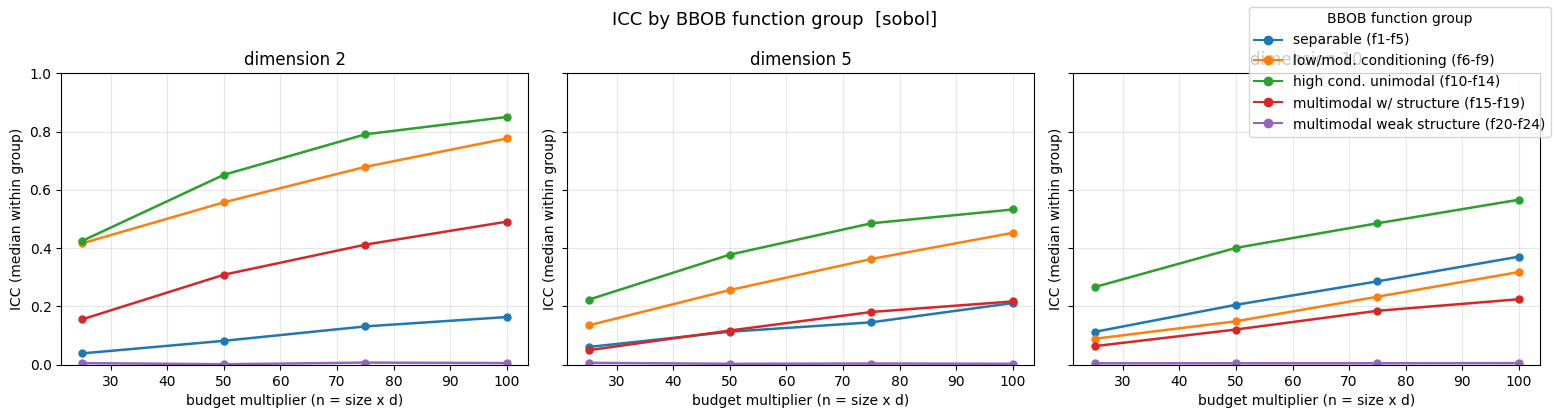

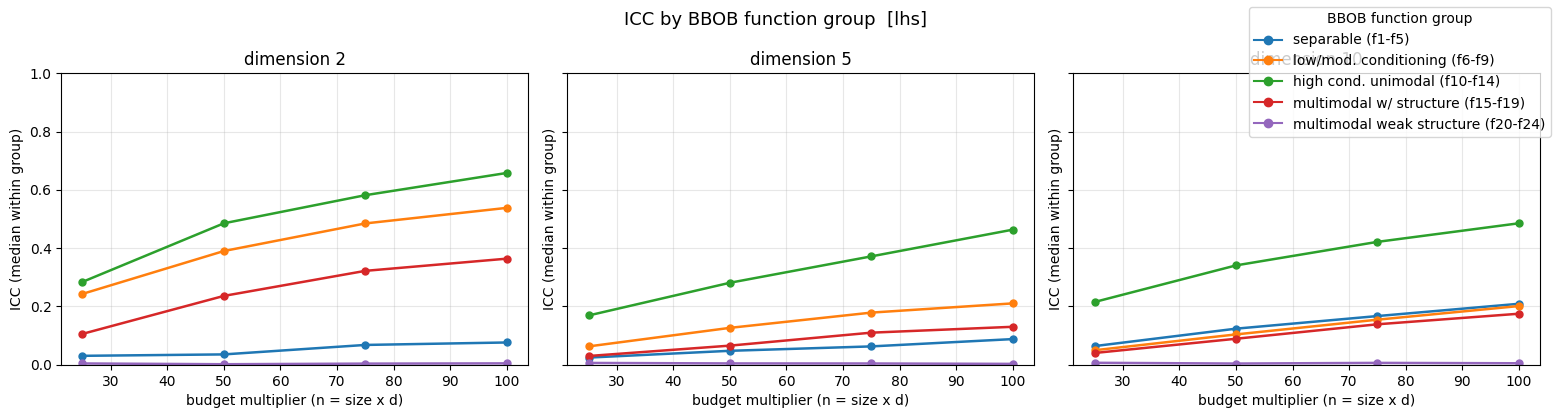

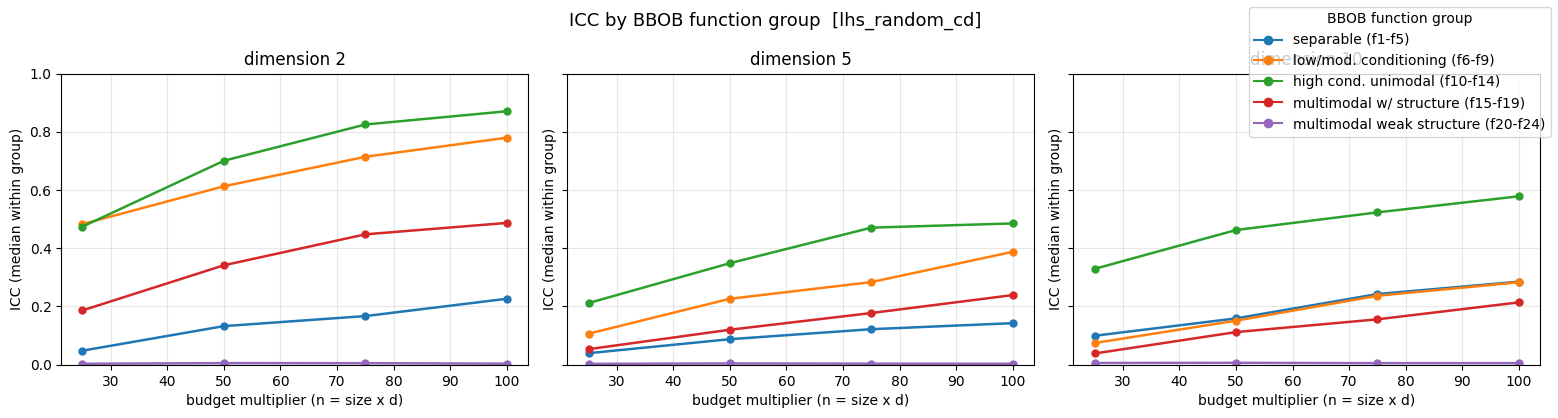

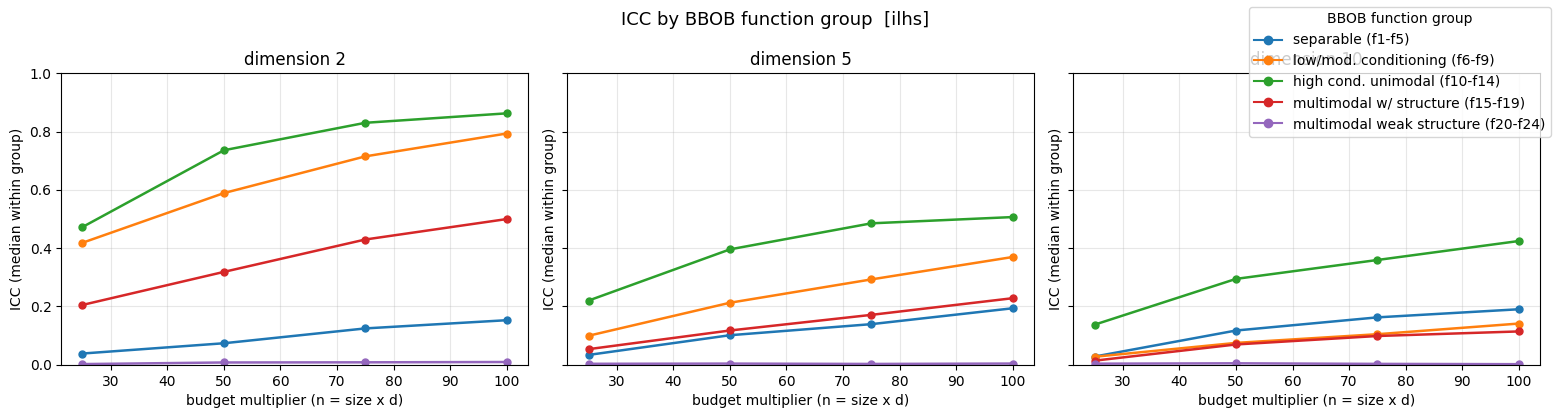

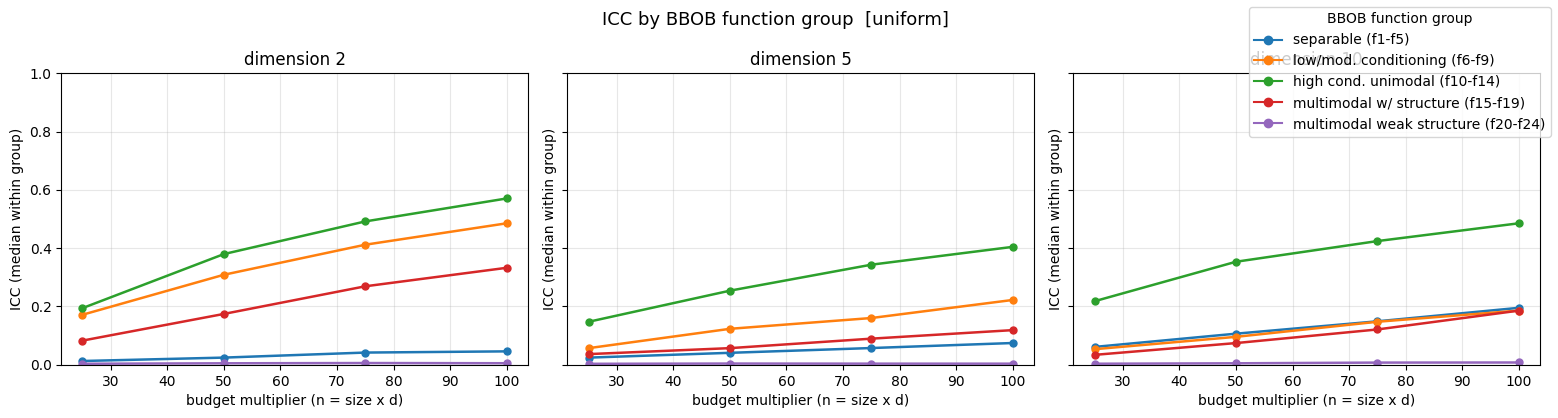

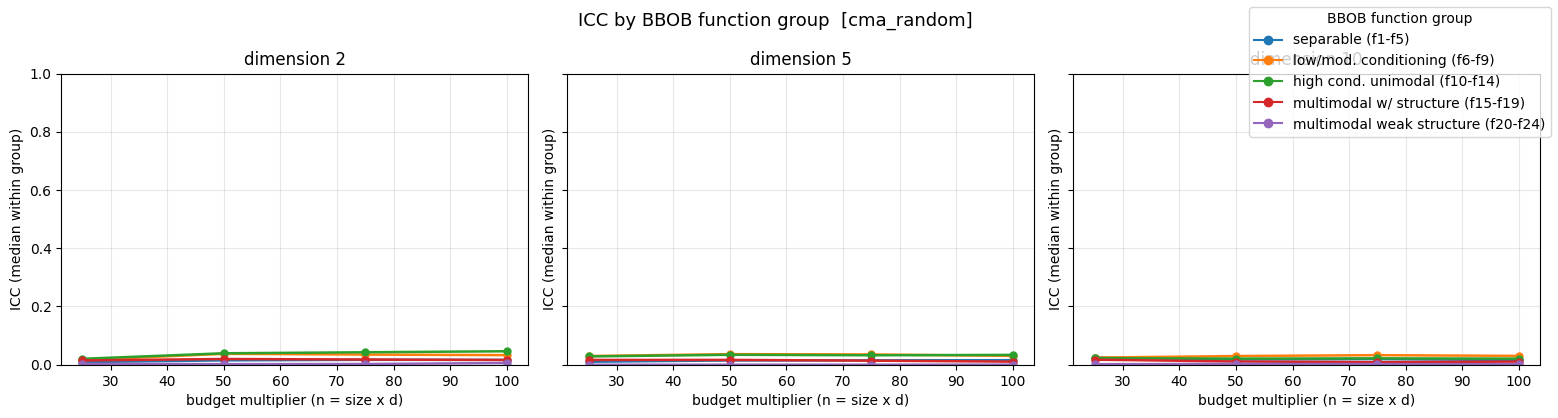

In [64]:
strategies = ["sobol", "lhs", "lhs_random_cd", "ilhs", "uniform", "cma_random"]
for st in strategies:
    fig, _ = plot_icc_by_function_group(res["by_group"], strategy=st)

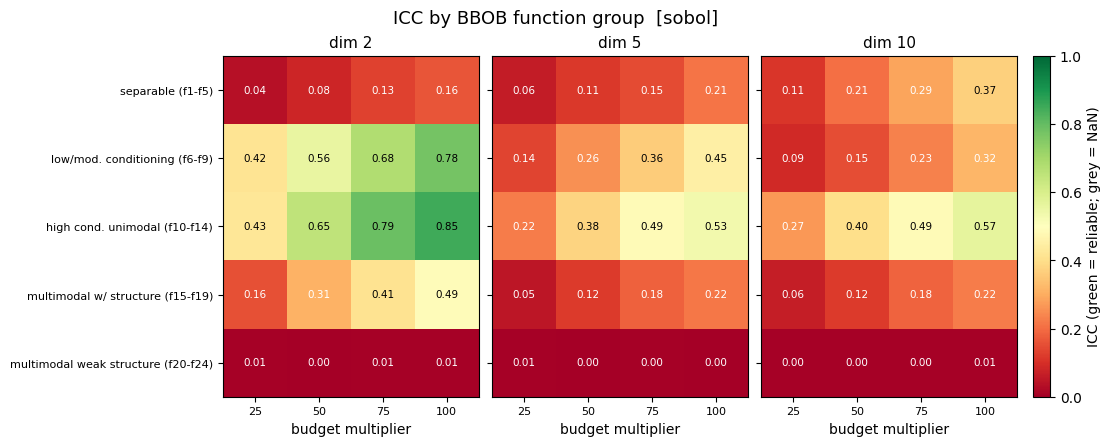

In [65]:
fig, _ = heatmap_icc_by_function_group(res["by_group"], strategy="sobol")

In [66]:
res["rank_strategy"].query("dimension == 5")

,dimension,size,strategy,mean_nrank,median_icc,n_cells,rank
28,5,25,sobol,0.761122,0.078422,1025,1
27,5,25,lhs_random_cd,0.737122,0.076386,1025,2
25,5,25,ilhs,0.684357,0.065987,1026,3
26,5,25,lhs,0.524415,0.044617,1026,4
29,5,25,uniform,0.435742,0.038644,1031,5
24,5,25,cma_random,0.386732,0.011228,1074,6
34,5,50,sobol,0.768102,0.147272,1022,1
33,5,50,lhs_random_cd,0.734508,0.139732,1022,2
31,5,50,ilhs,0.710775,0.142857,1024,3
32,5,50,lhs,0.511068,0.083230,1024,4


collected 72,397 ICC cells | 45 features | 24 functions | dims [2, 5, 10]

=== per-function ICC ceiling (p90 across features, n=100) ===
  dim 2: ceiling ranges 0.008 .. 1.000  (spread 0.992)
      separable (f1-f5)                  median ceiling 0.998
      low/mod. conditioning (f6-f9)      median ceiling 0.996
      high cond. unimodal (f10-f14)      median ceiling 0.996
      multimodal w/ structure (f15-f19)  median ceiling 0.959
      multimodal weak structure (f20-f24) median ceiling 0.039
  dim 5: ceiling ranges 0.006 .. 1.000  (spread 0.993)
      separable (f1-f5)                  median ceiling 0.995
      high cond. unimodal (f10-f14)      median ceiling 0.987
      low/mod. conditioning (f6-f9)      median ceiling 0.984
      multimodal w/ structure (f15-f19)  median ceiling 0.950
      multimodal weak structure (f20-f24) median ceiling 0.008
  dim 10: ceiling ranges 0.011 .. 0.997  (spread 0.986)
      separable (f1-f5)                  median ceiling 0.992
      high co

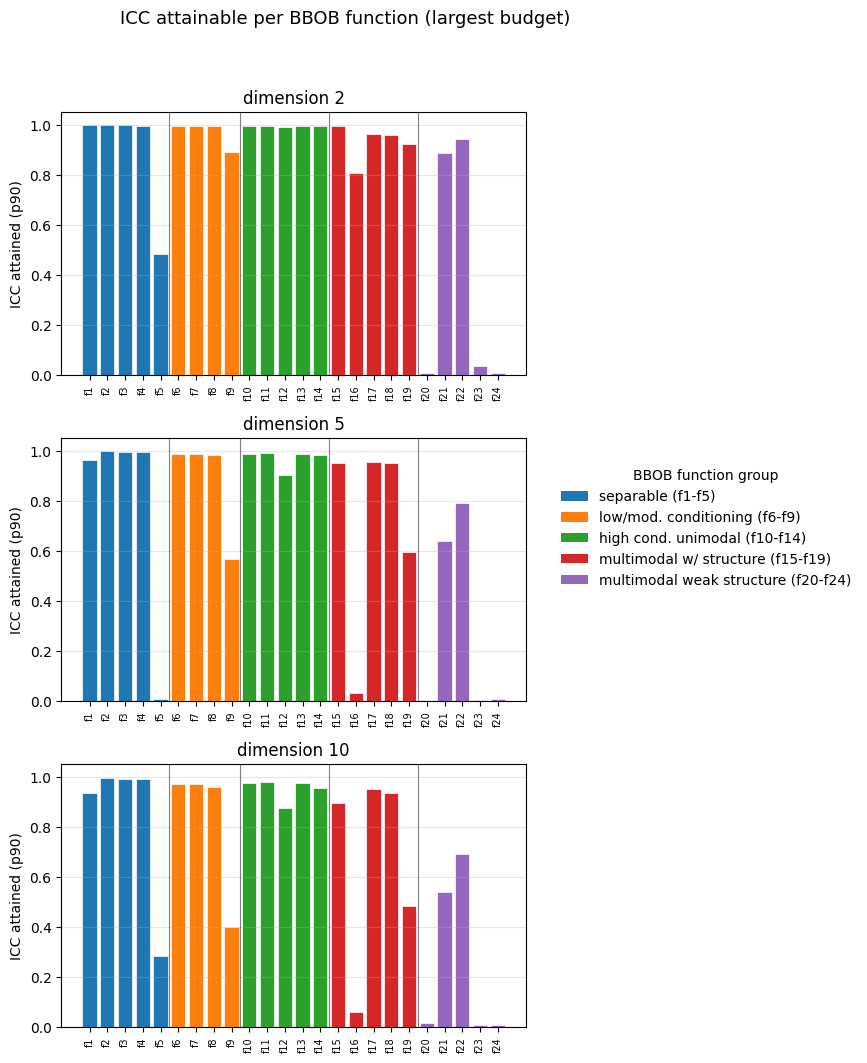

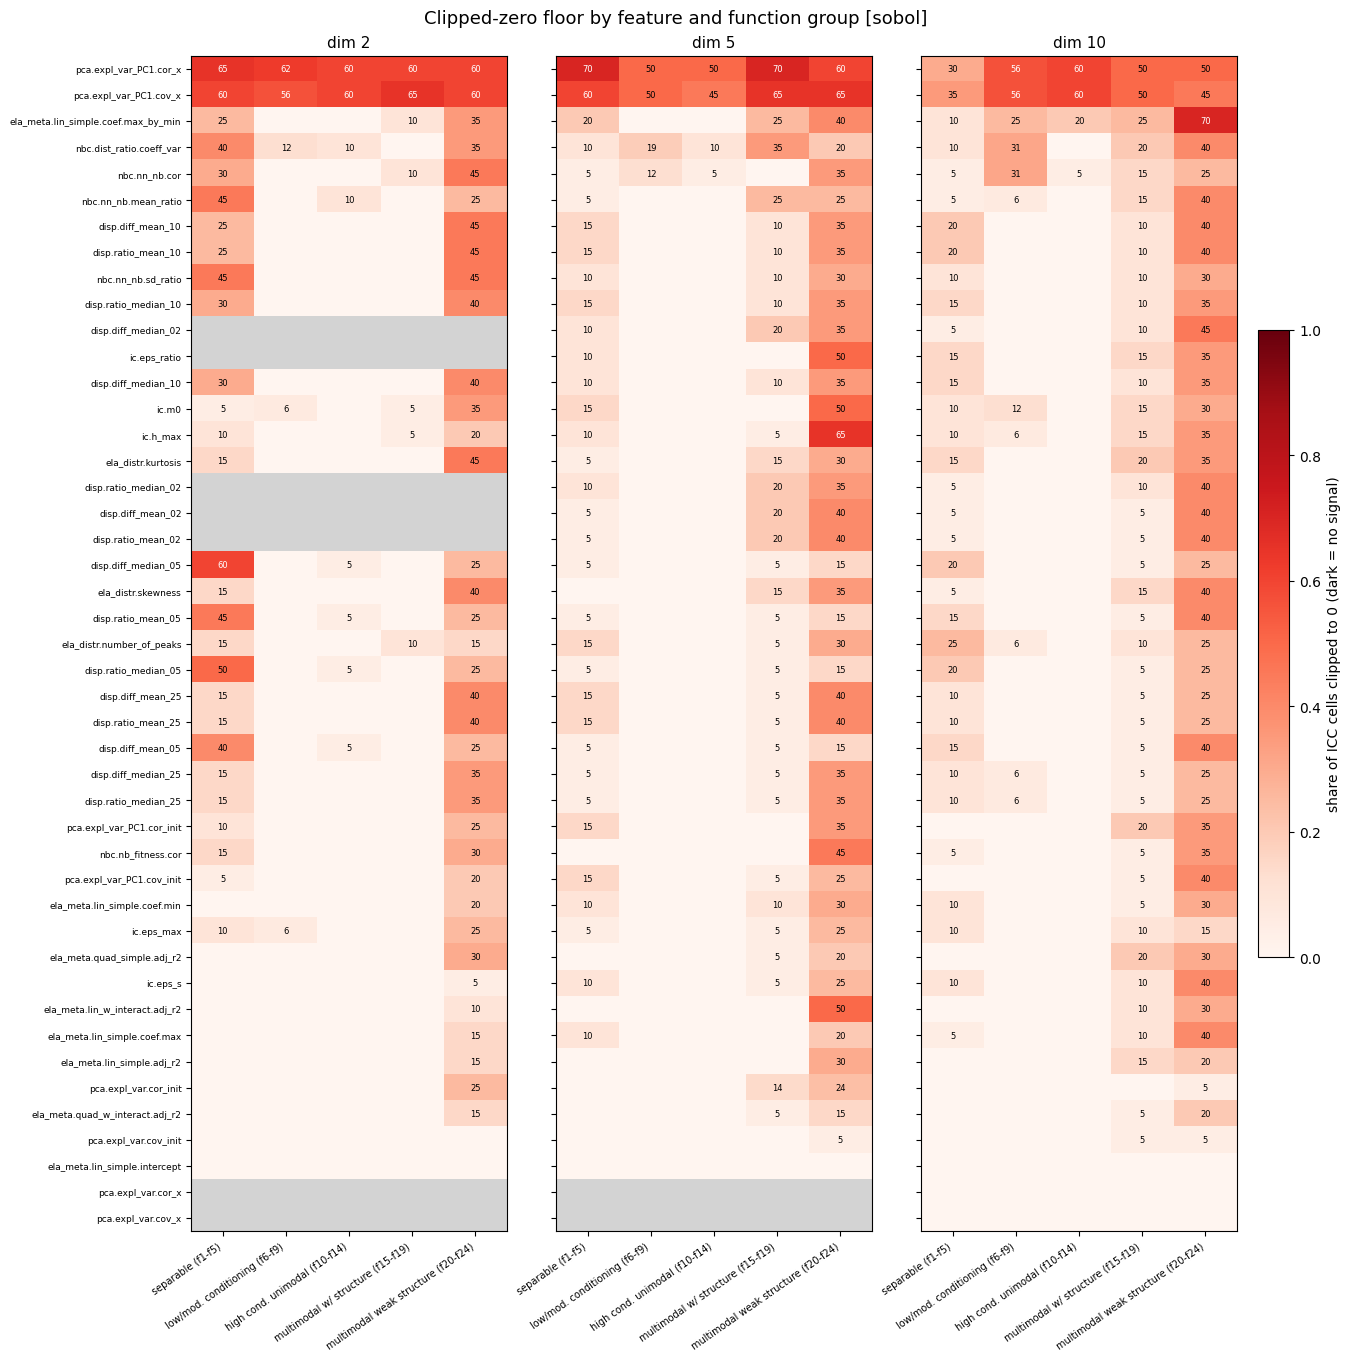

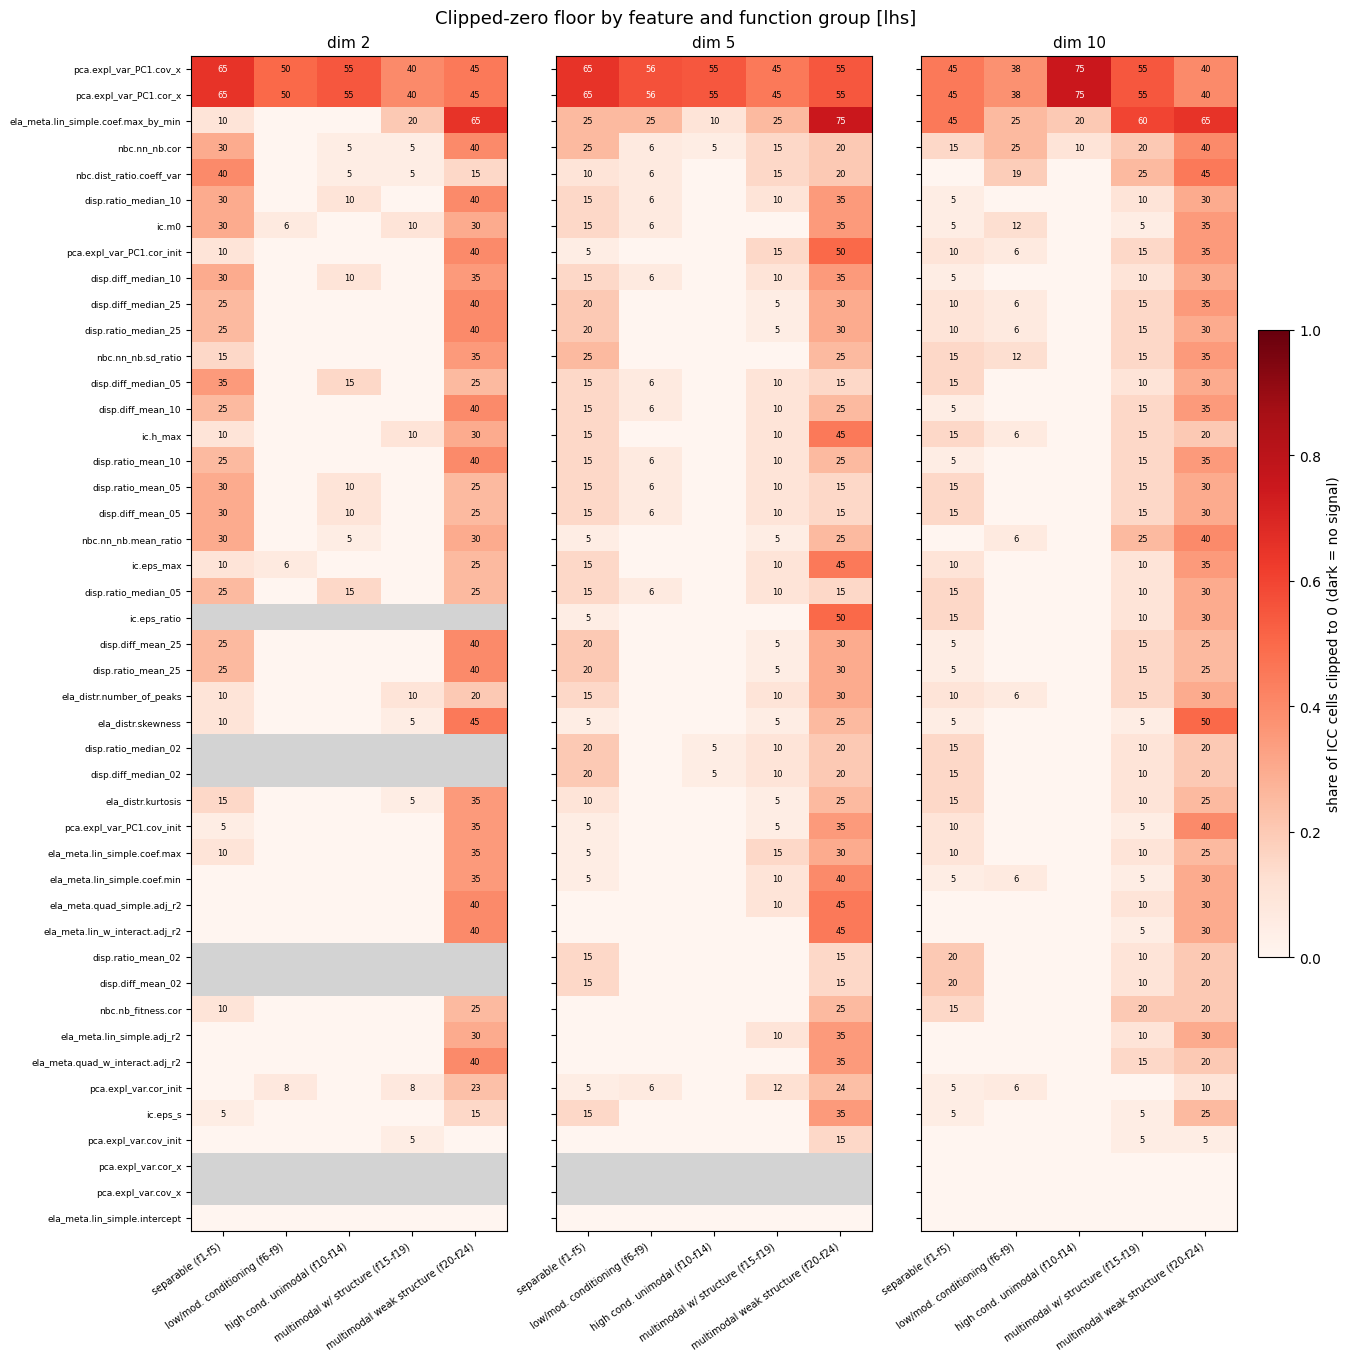

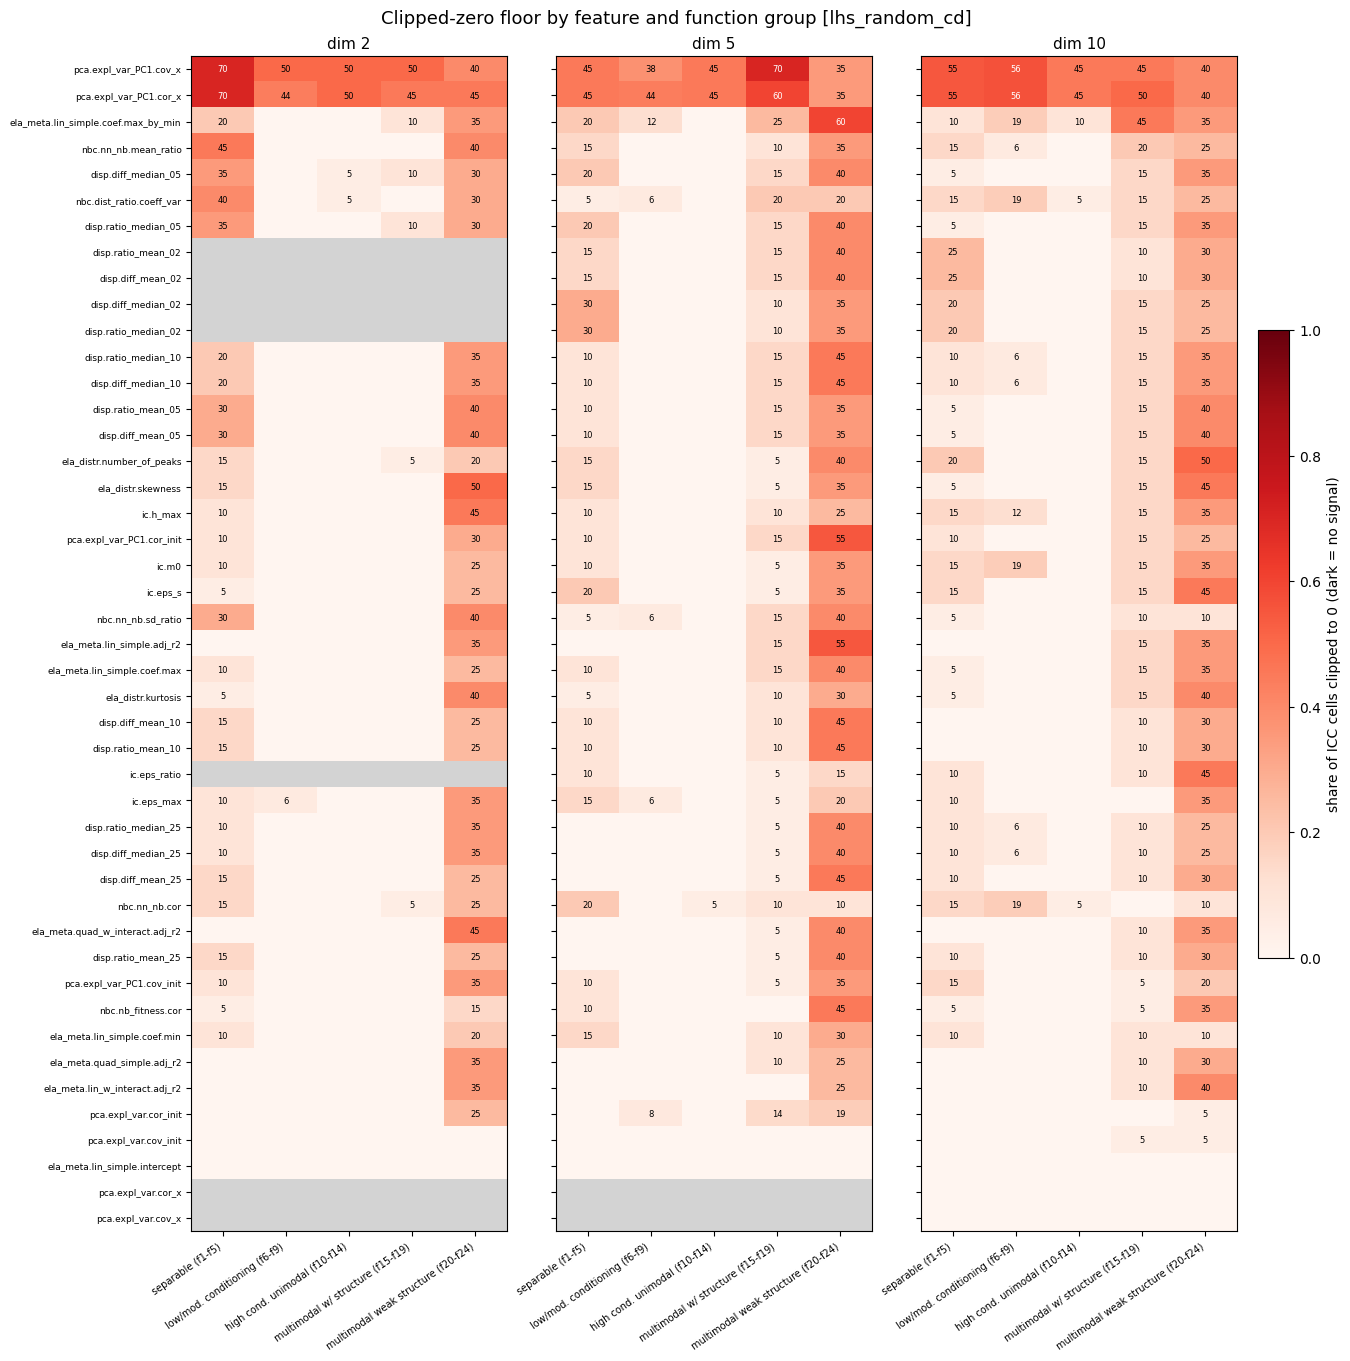

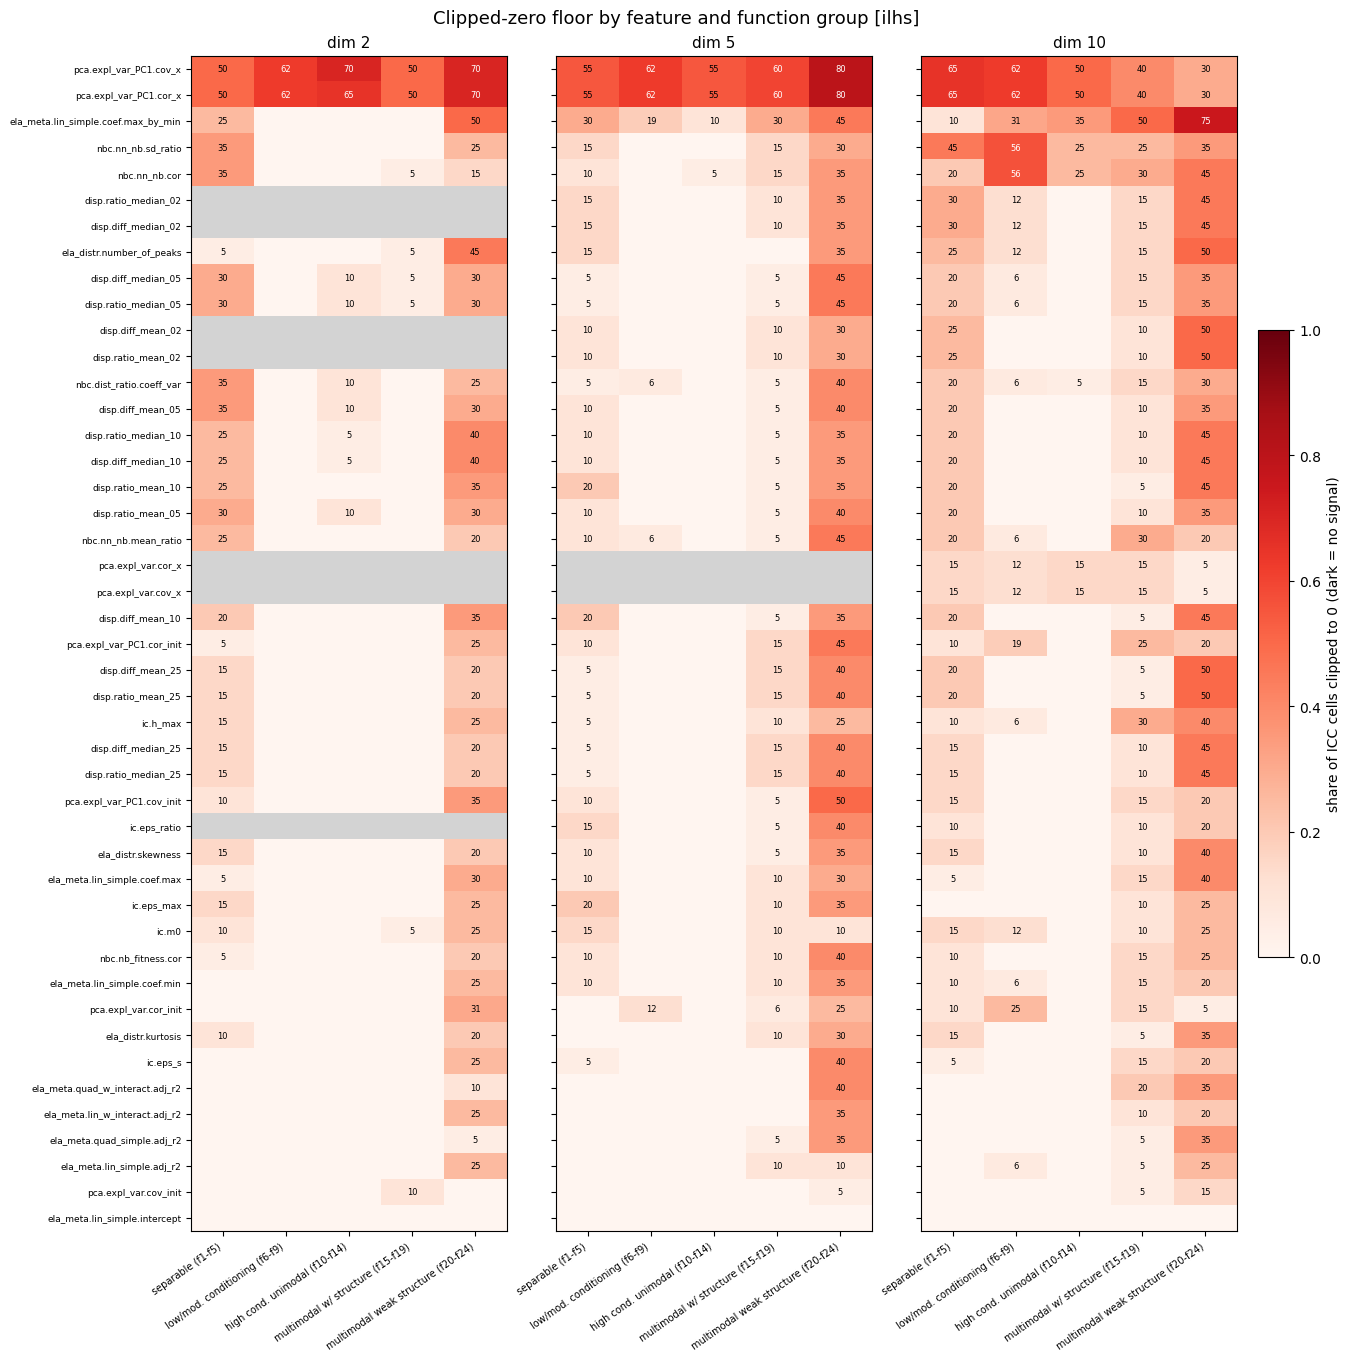

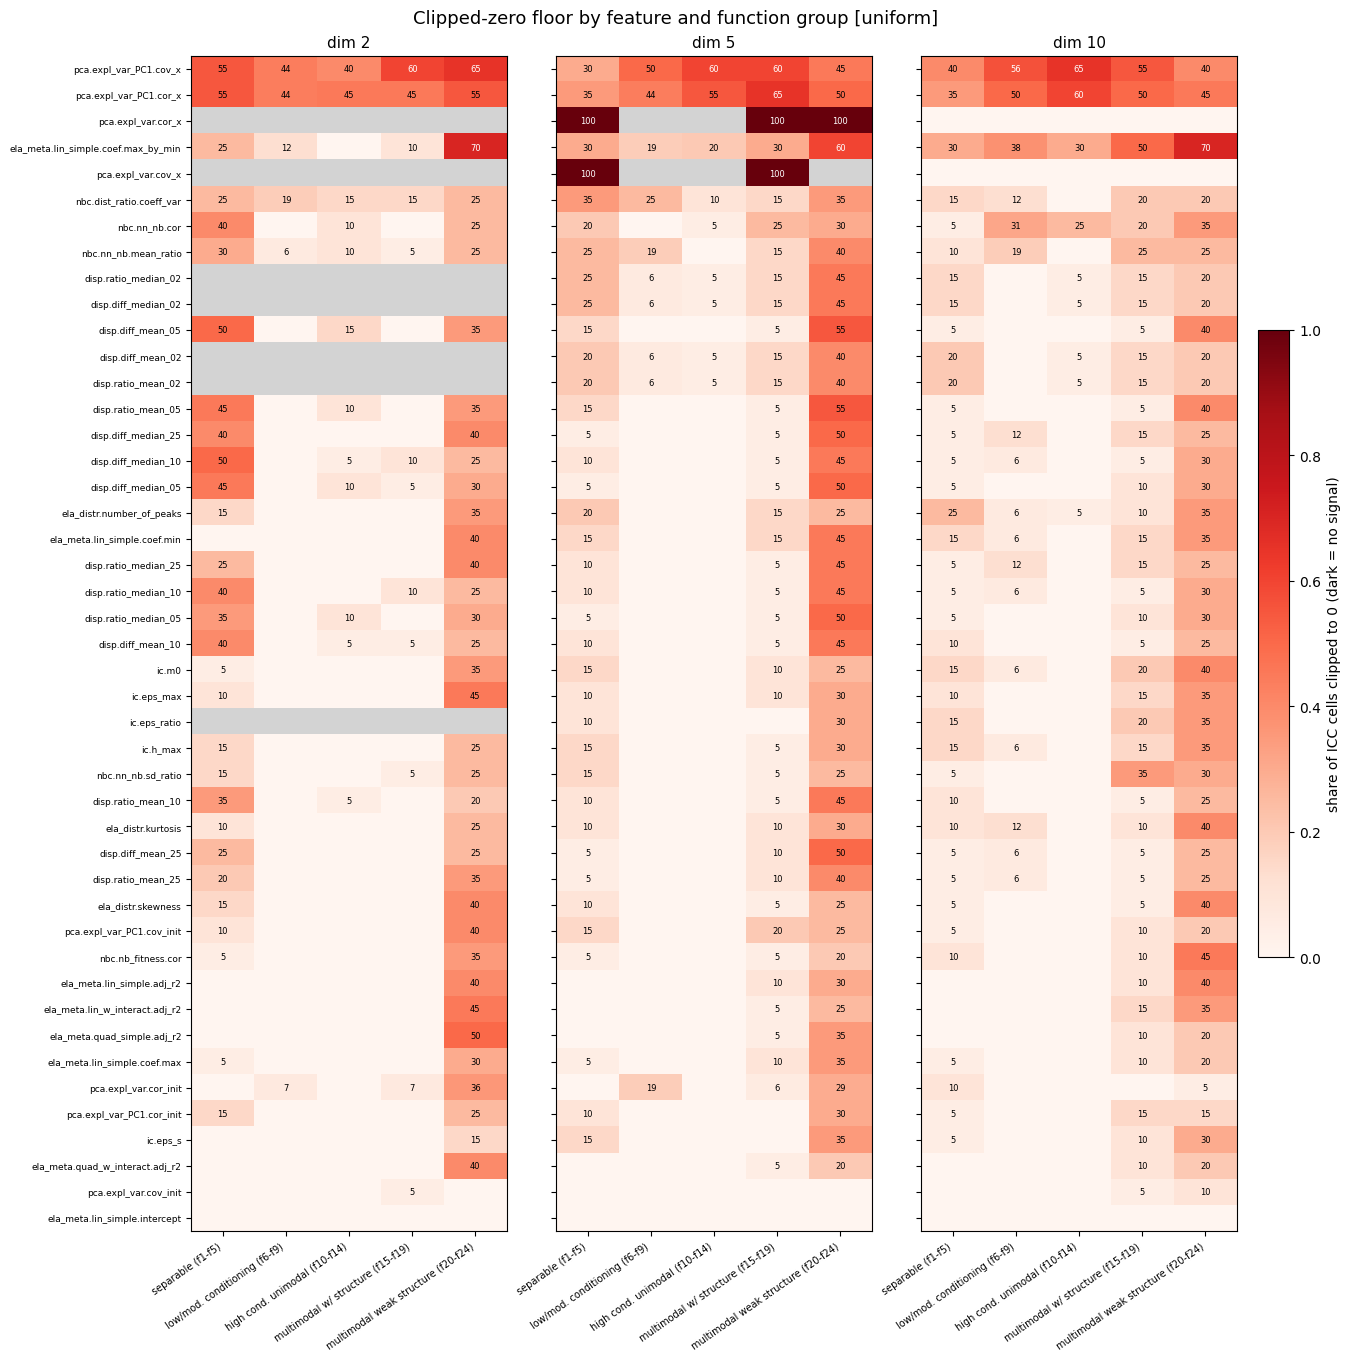

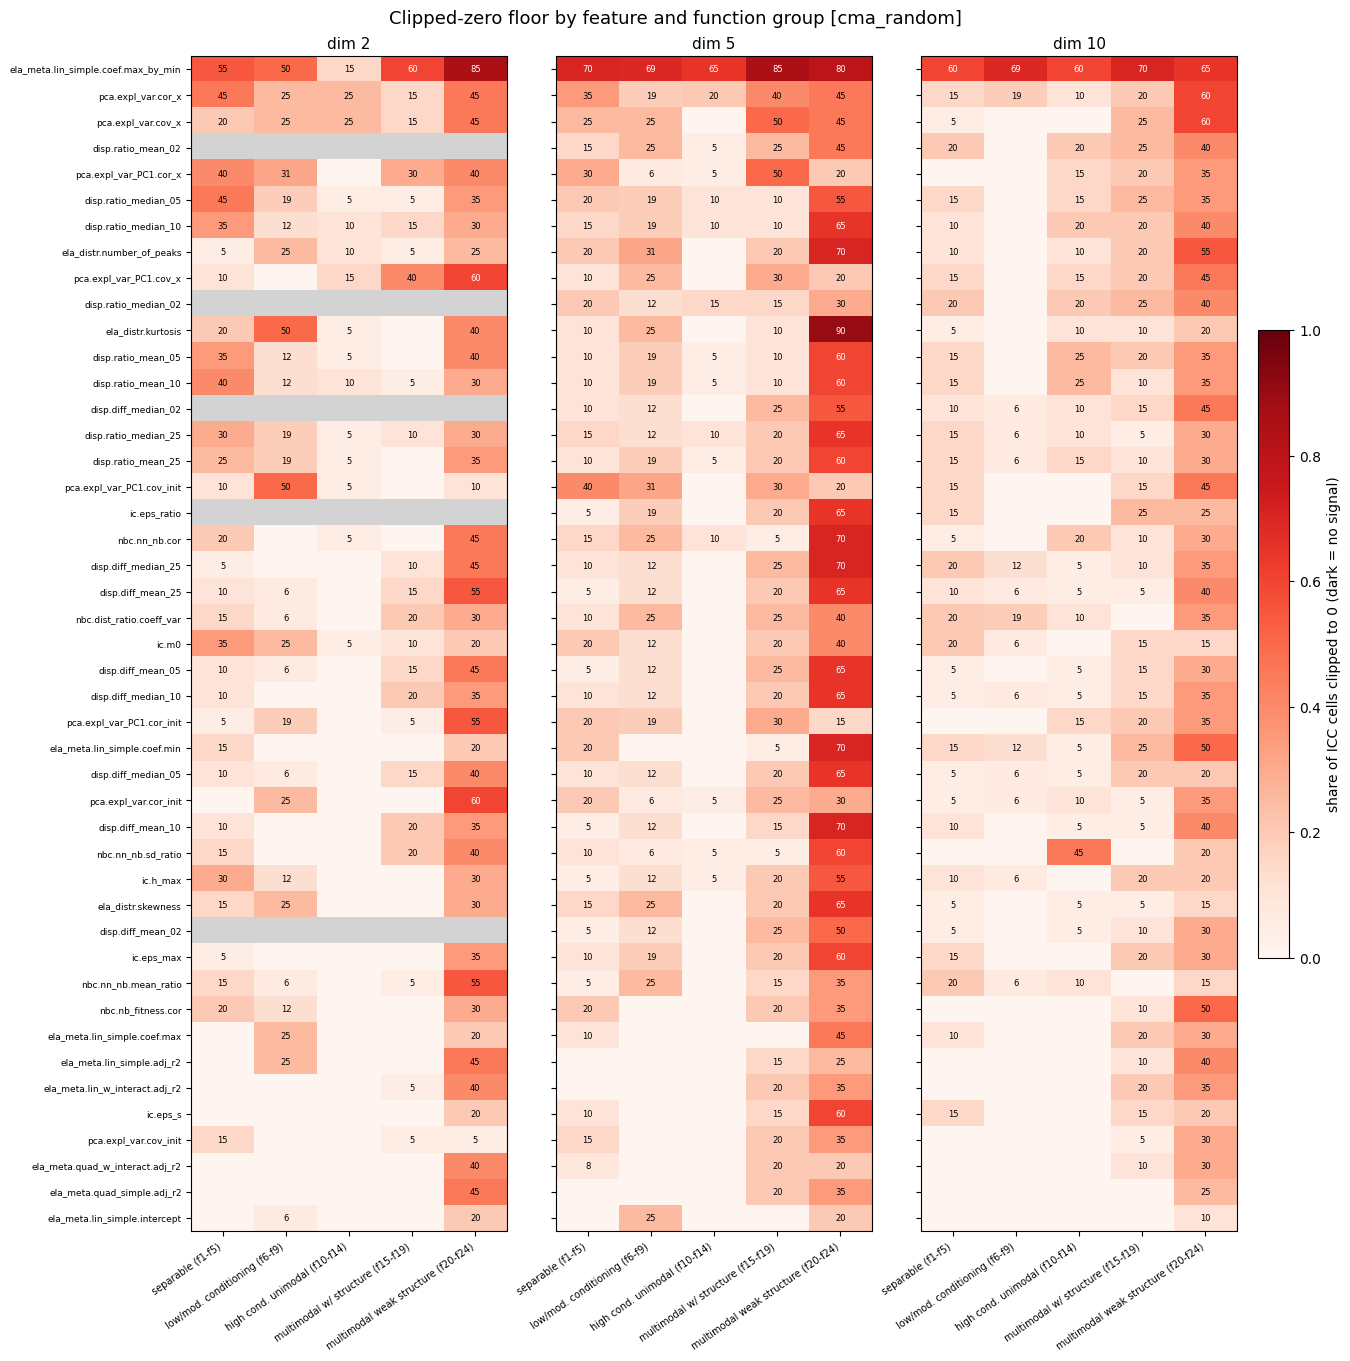

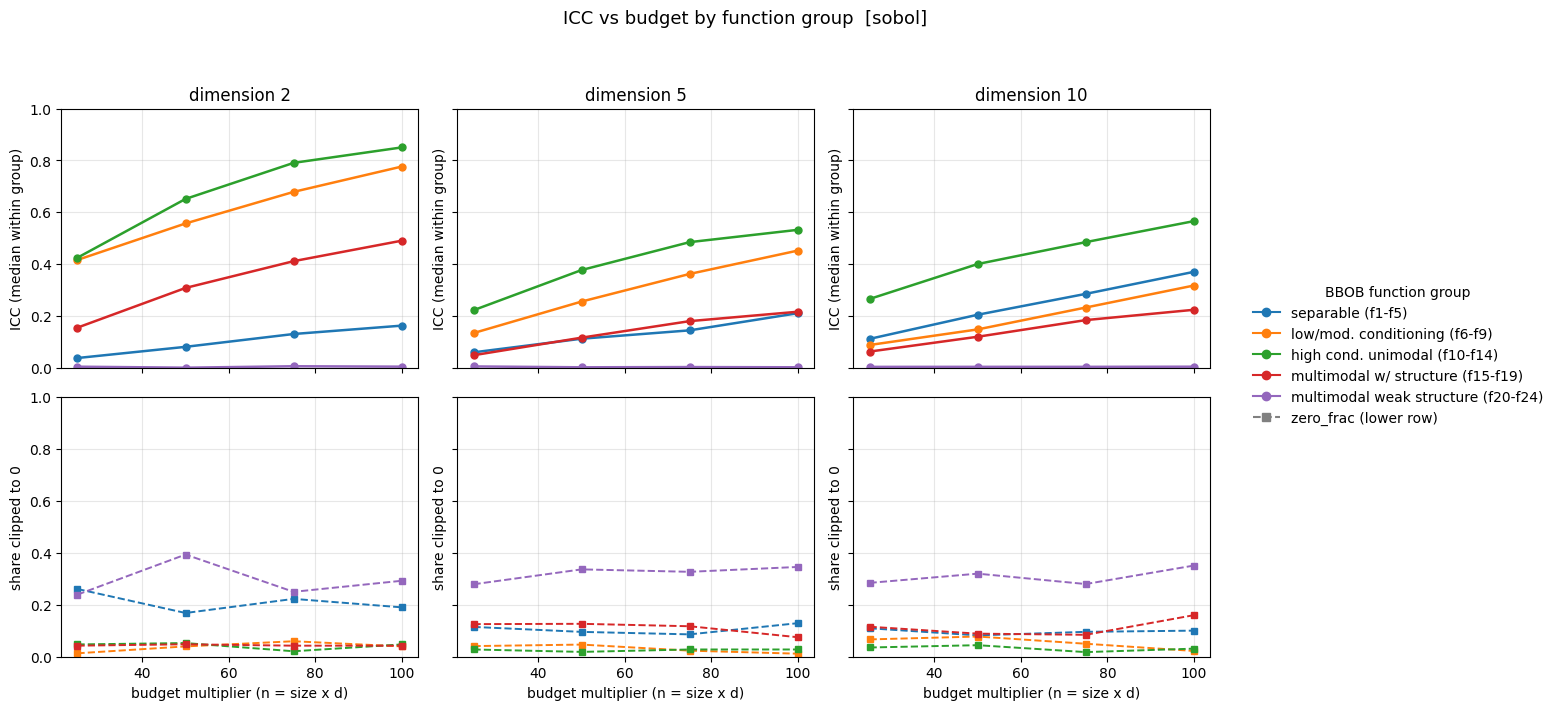

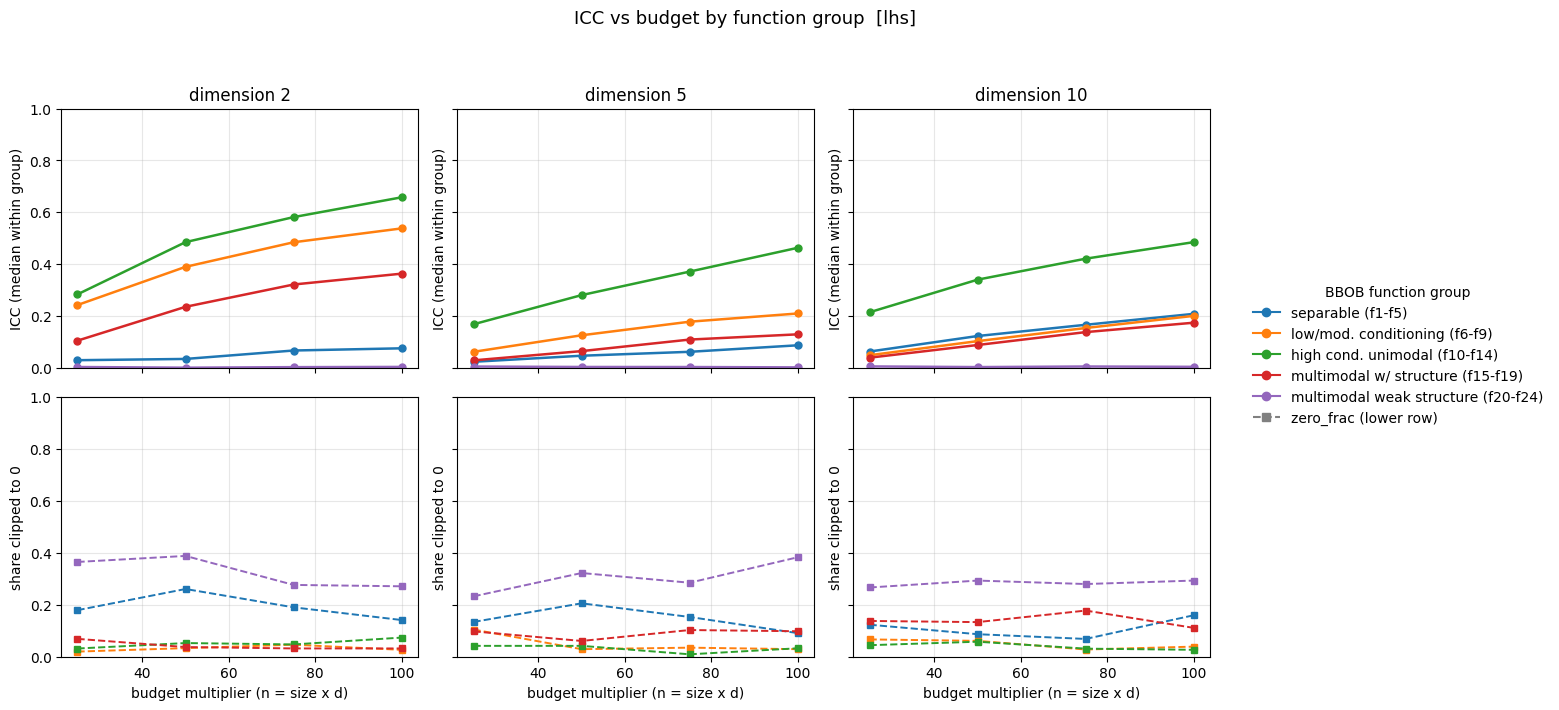

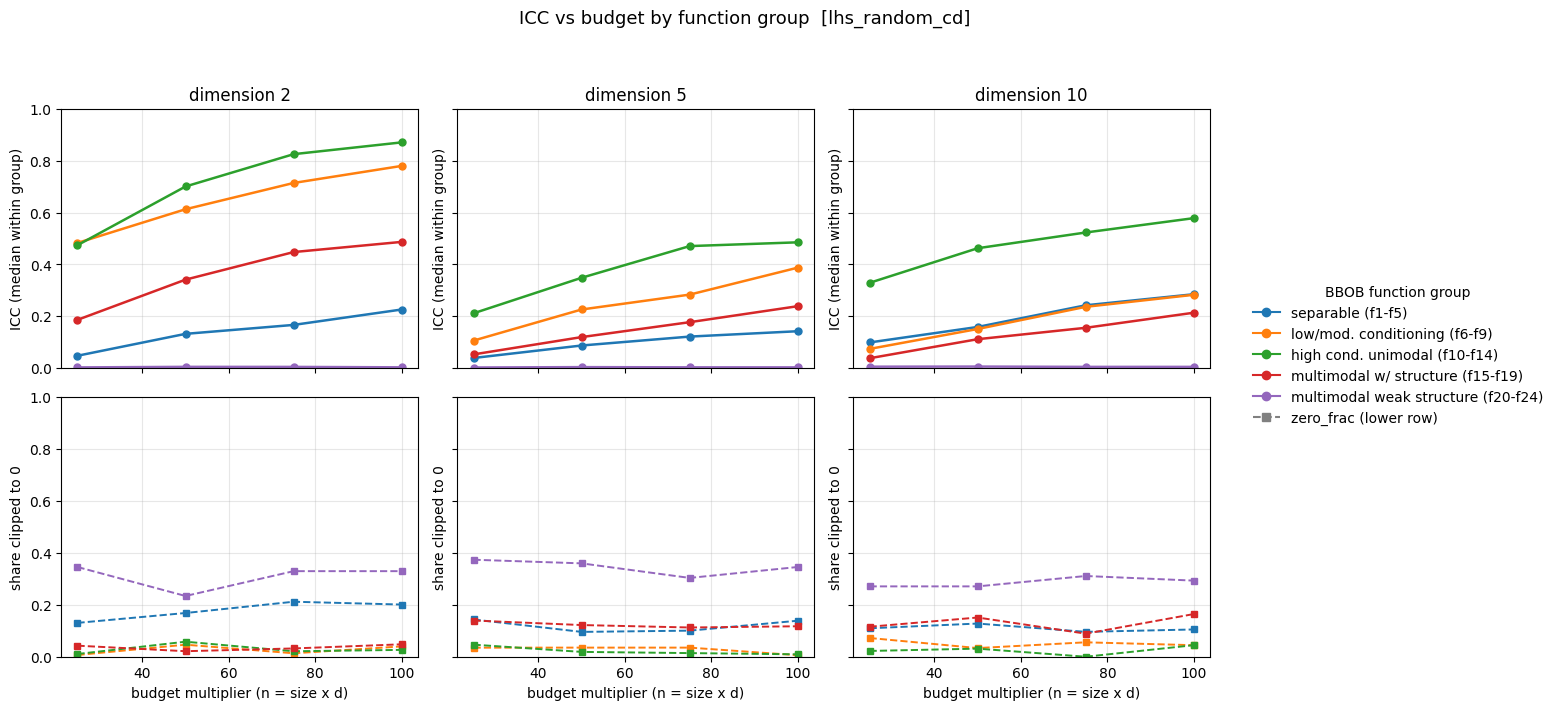

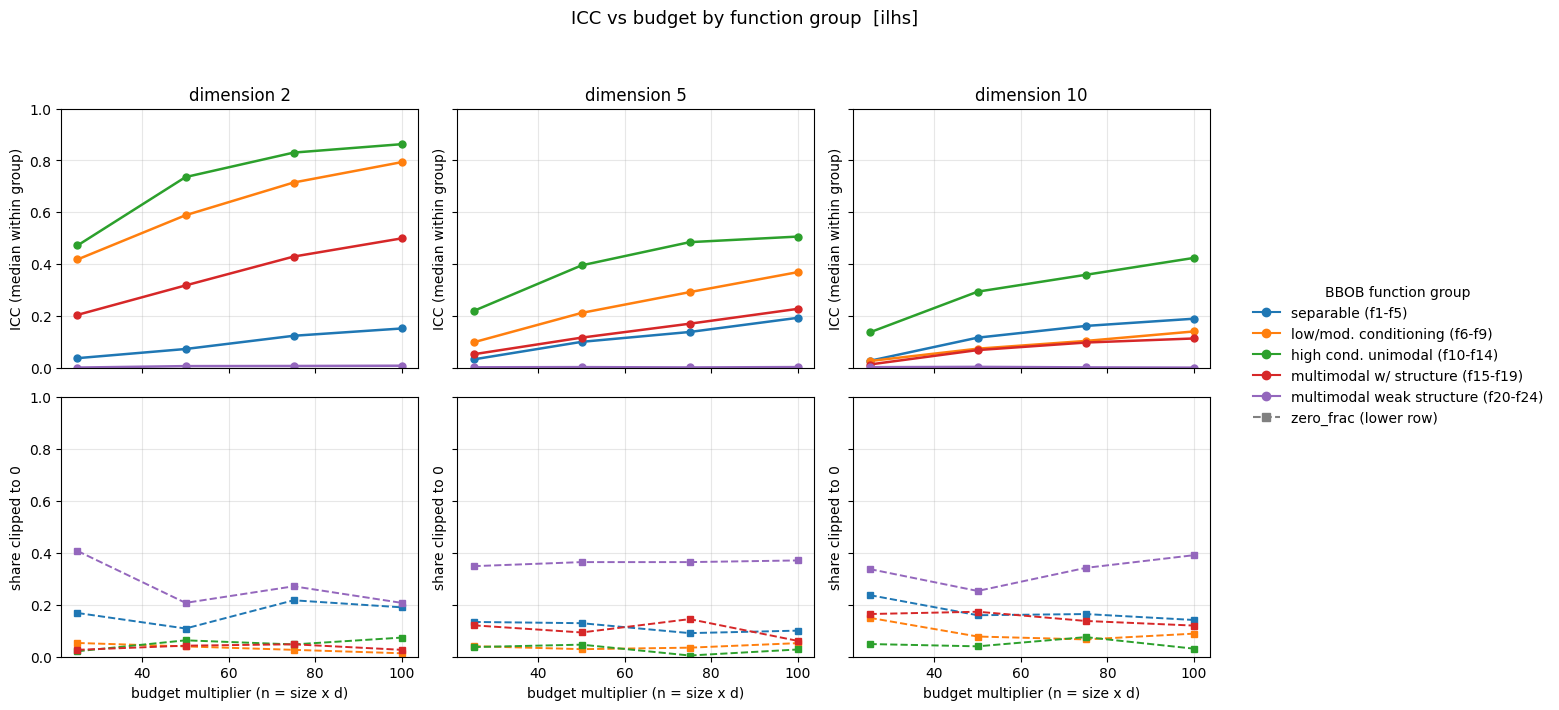

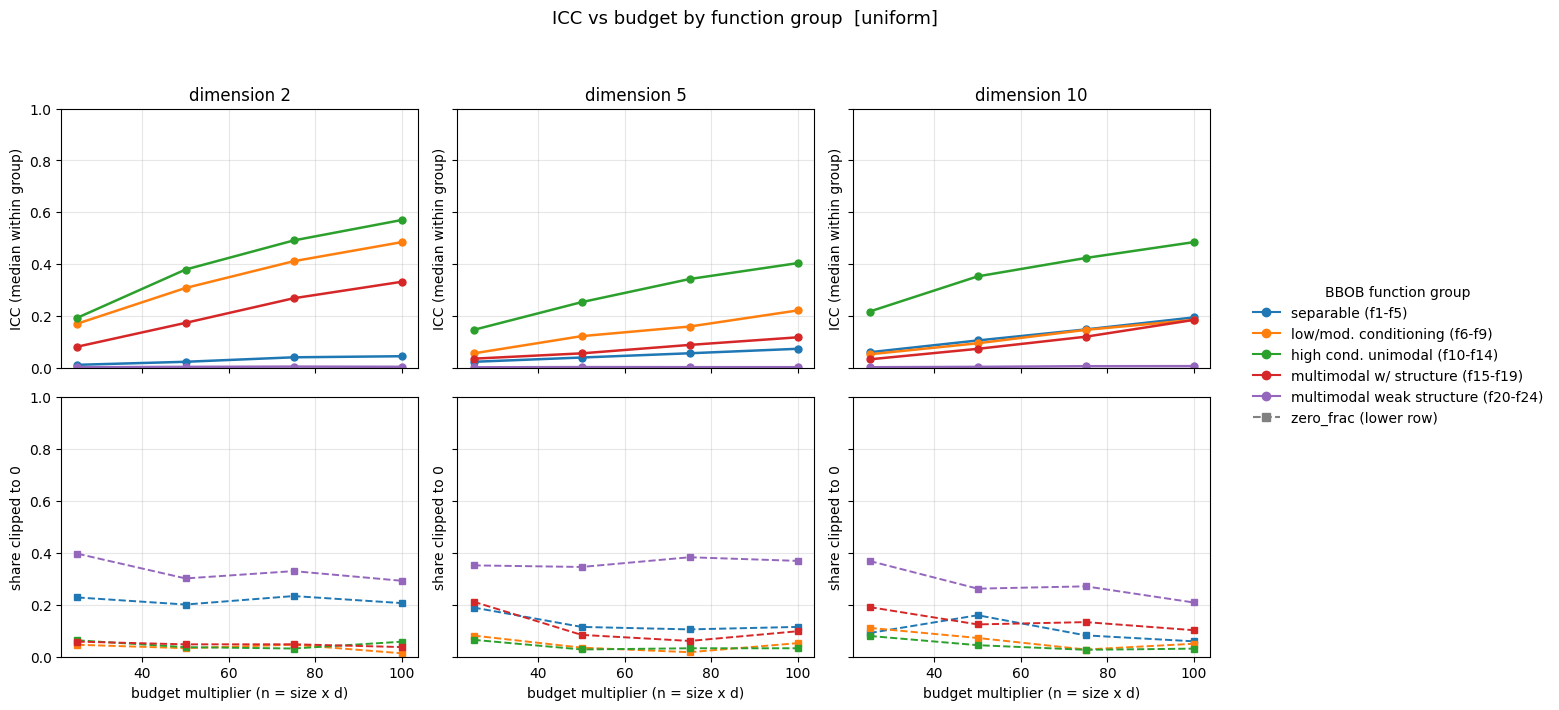

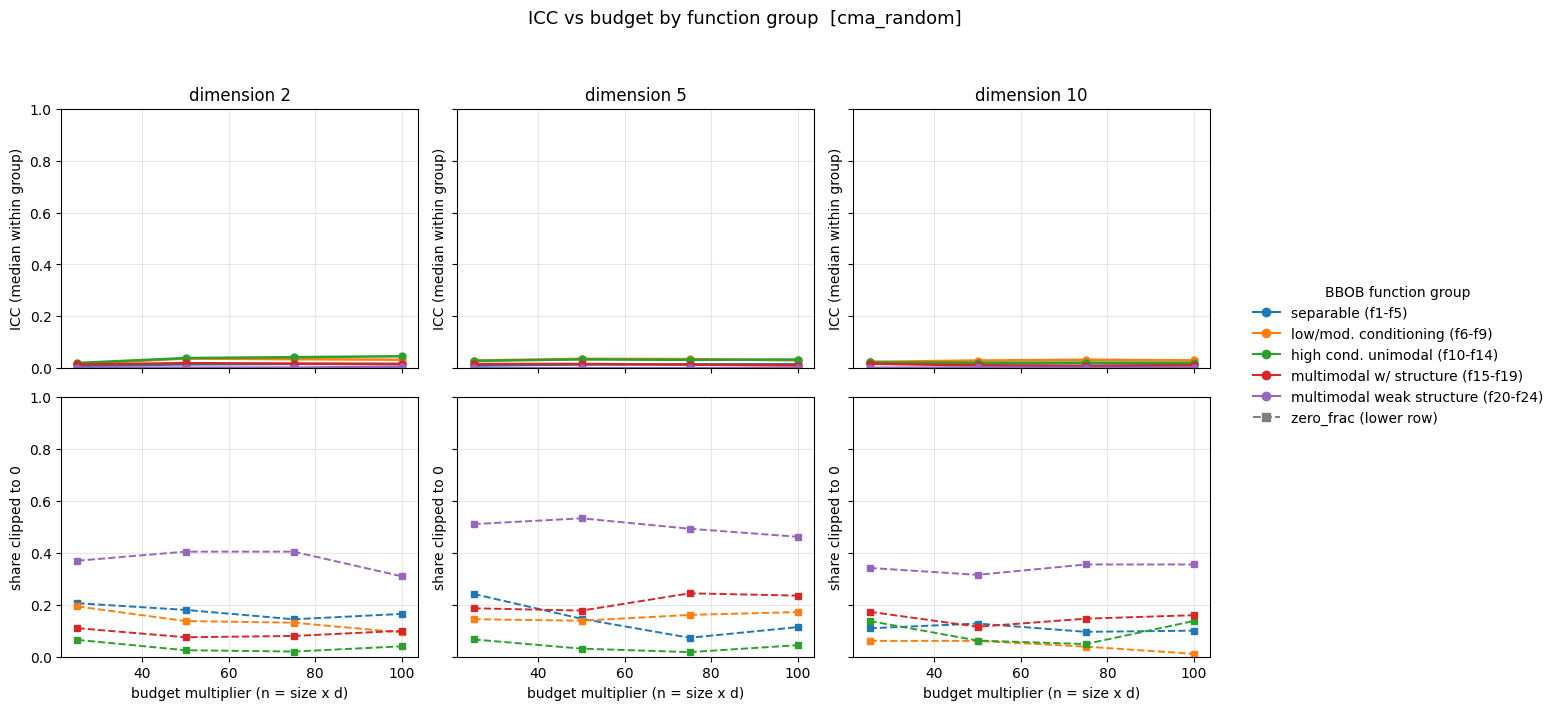

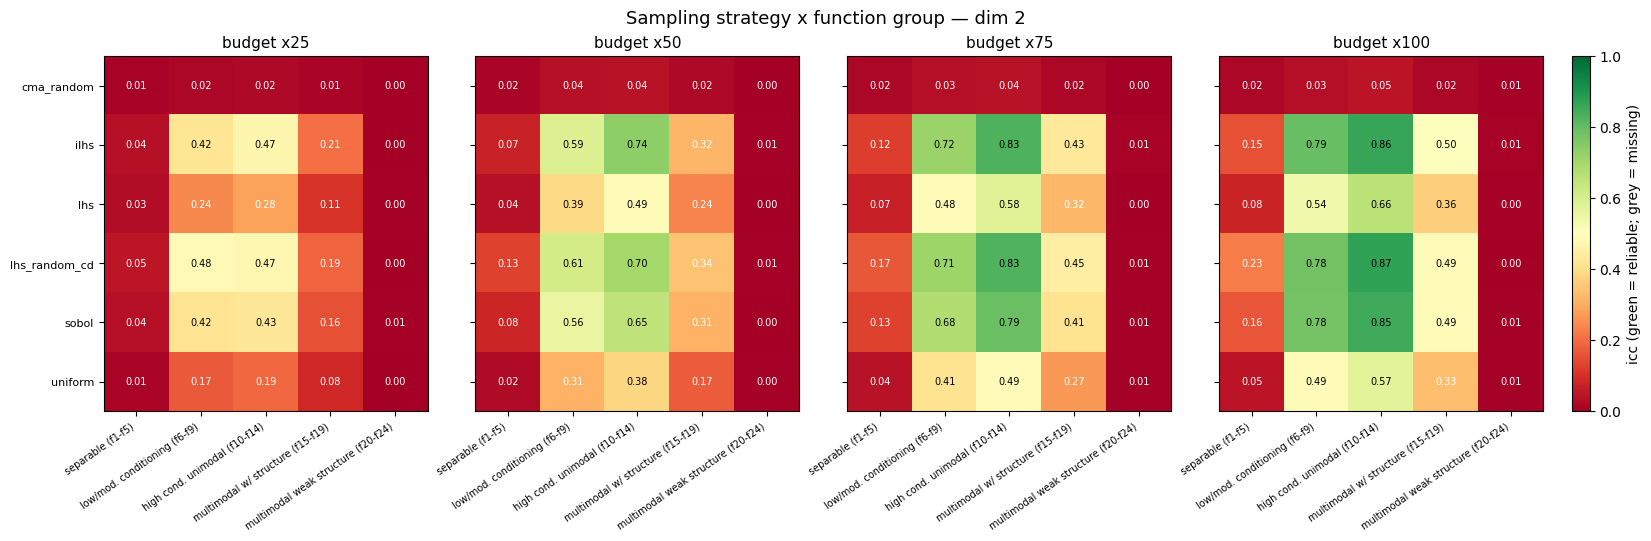

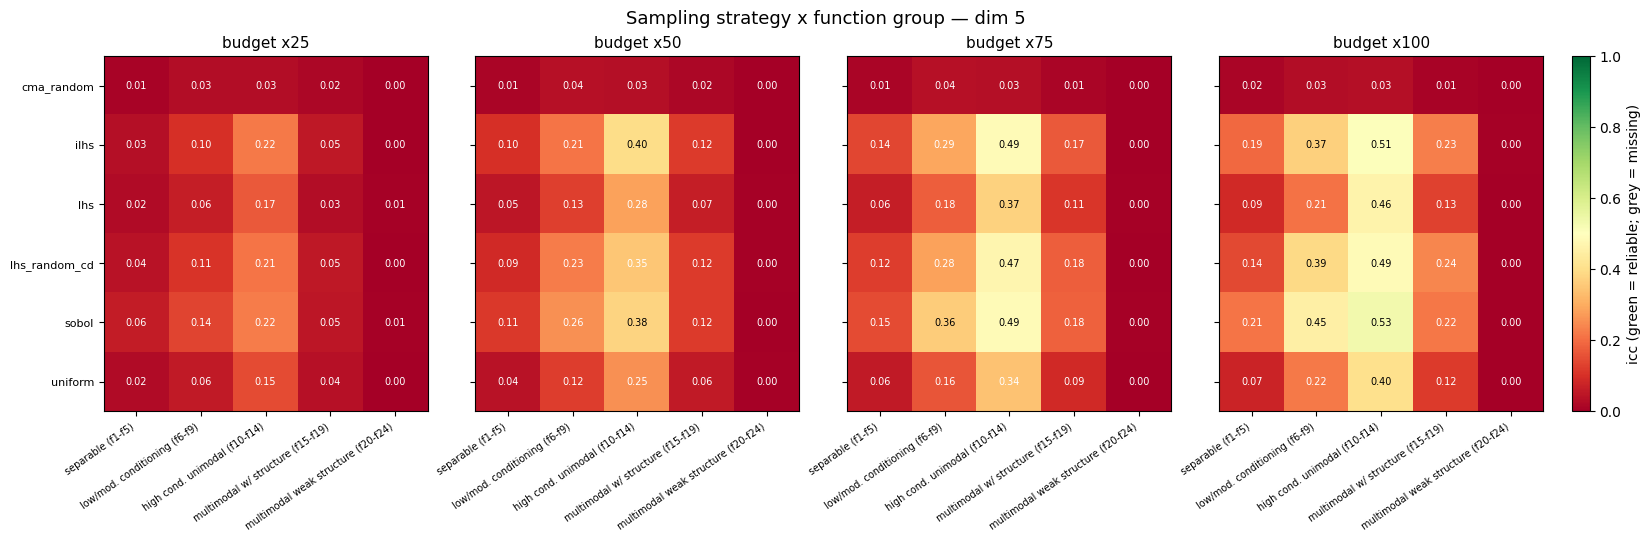

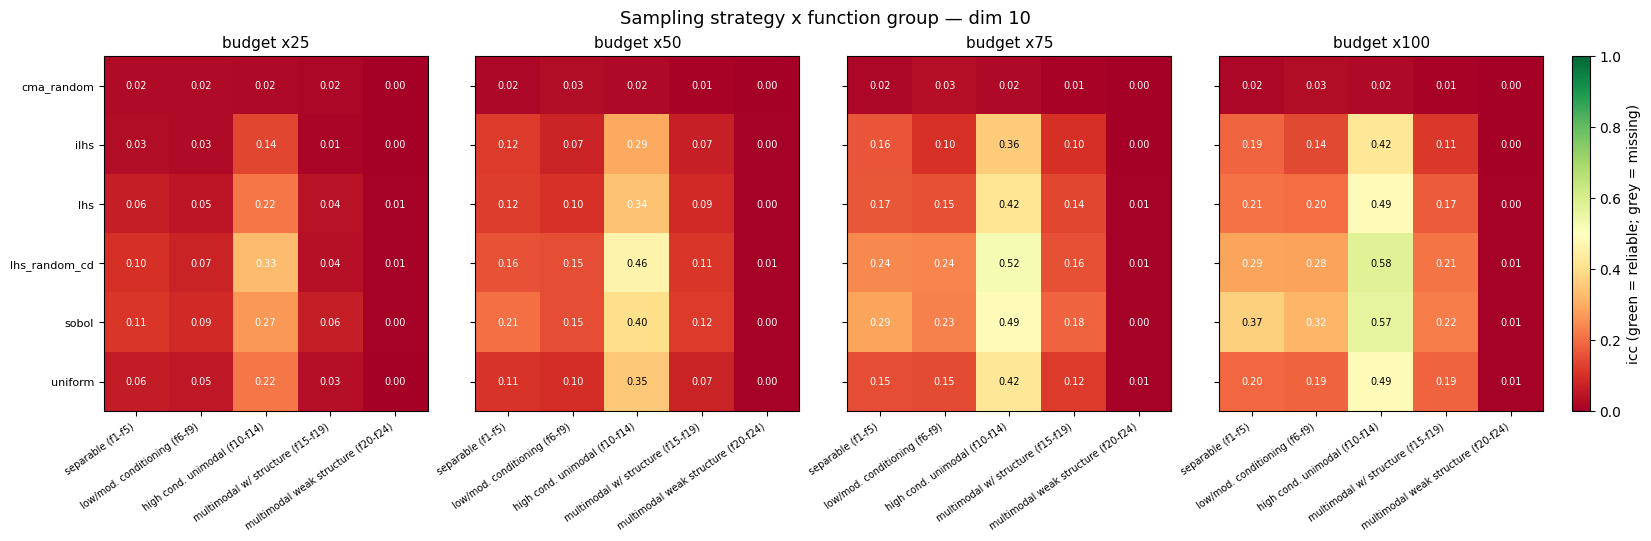

In [4]:
from icc_by_function_group import run_group_analysis
from icc_plots import (plot_function_attainment, plot_floor_map,
                       plot_icc_vs_budget, heatmap_strategy_by_group, plot_strategy_comparison)

res = run_group_analysis(icc_src)

fig, _ = plot_function_attainment(res["ceilings"])                # 1
strategies = ["sobol", "lhs", "lhs_random_cd", "ilhs", "uniform", "cma_random"]
for st in strategies:
    fig, _ = plot_floor_map(res["long"], strategy=st)            # 2
for st in strategies:
    fig, _ = plot_icc_vs_budget(res["by_group"], strategy=st)    # 3
for dim in [2, 5, 10]:
    fig, _ = heatmap_strategy_by_group(res["by_group"], dimension=dim)  # 4

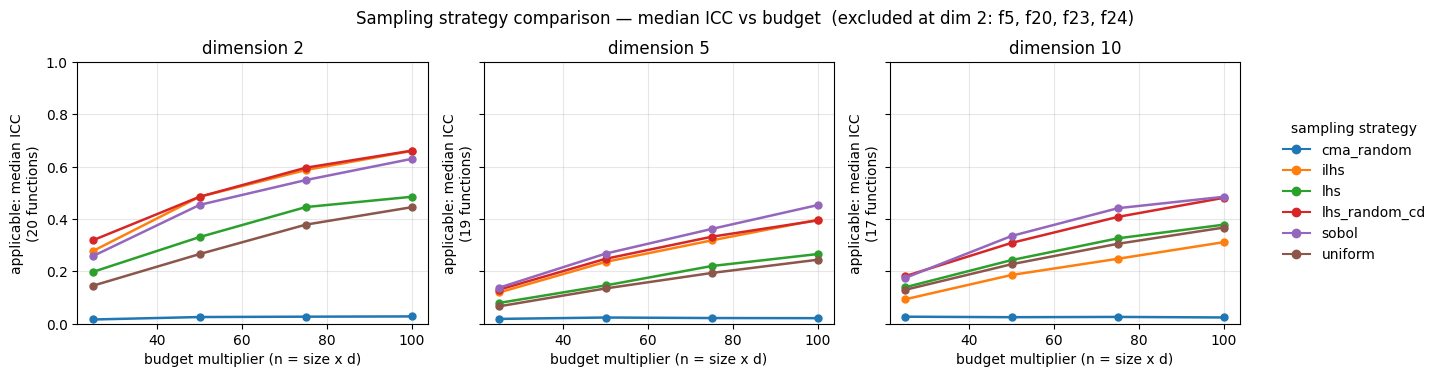

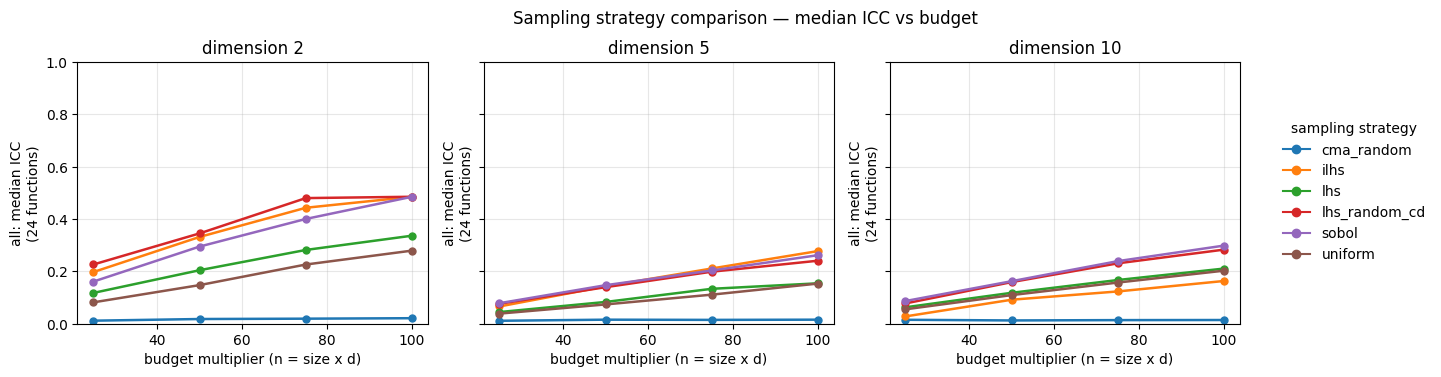

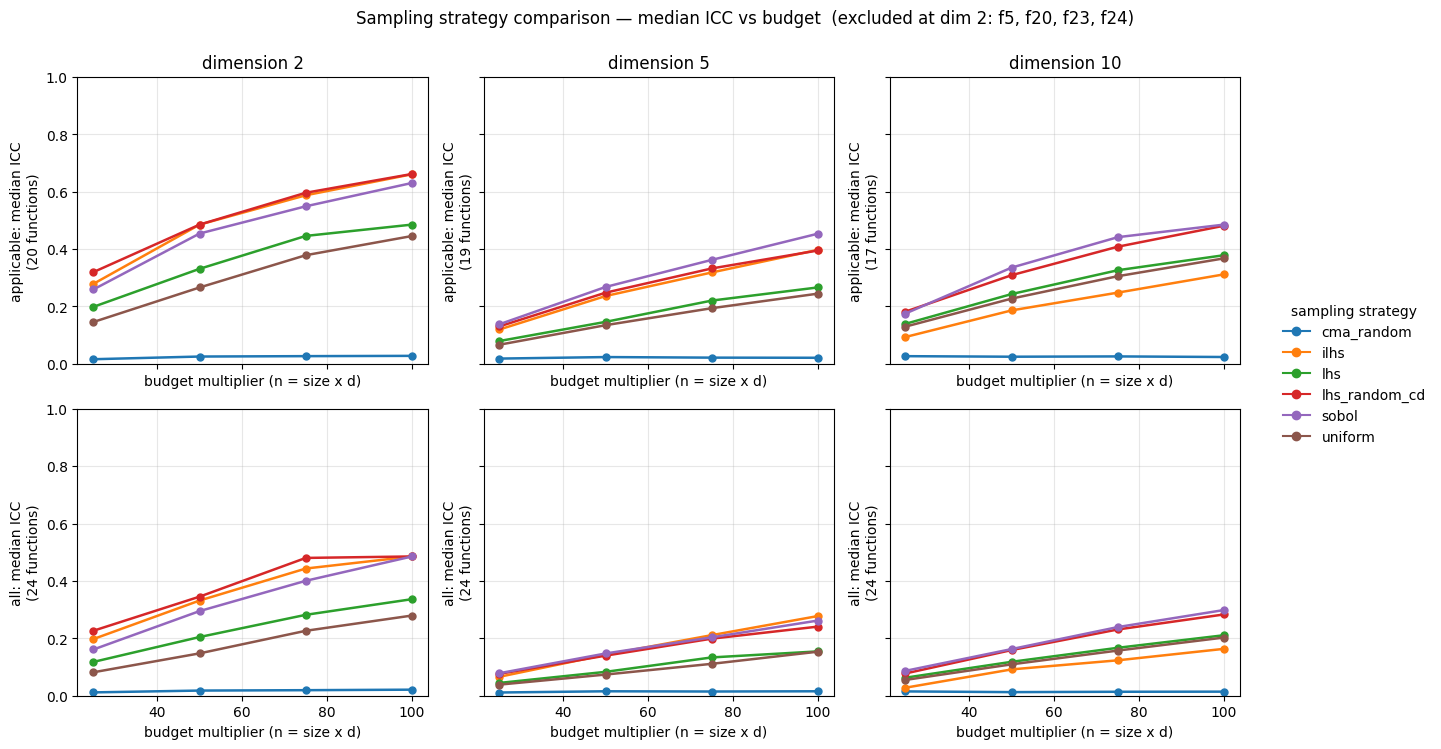

In [69]:
# only where there's signal to detect (the meaningful comparison)
fig, _ = plot_strategy_comparison(res["long"], res["ceilings"], scope="applicable")

# every function pooled — reproduces your original overall_icc number
fig, _ = plot_strategy_comparison(res["long"], scope="all")

# both stacked, same axes — shows how much the floored functions drag it down
fig, _ = plot_strategy_comparison(res["long"], res["ceilings"], scope="both")